# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [305]:
import scanpy as sc
import decoupler as dc
import pertpy as pt
sc.set_figure_params(figsize=(3, 3), frameon=False)
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import warnings
warnings.filterwarnings("ignore")

def make_pseudobulk(adata, celltype, ct_col="celltype_merged",
                    sample_cols=("mouse_id","genotype","age"),
                    layer="counts"):
    ad = adata[adata.obs[ct_col] == celltype].copy()
    if layer in ad.layers:
        X = ad.layers[layer]
    else:
        X = ad.X
    if sparse.issparse(X):
        X = X.tocsr()

    # define samples as unique combinations of sample_cols
    meta = ad.obs.loc[:, sample_cols].astype(str)
    meta["sample_id"] = meta.apply(lambda r: "_".join(r.values), axis=1)

    # aggregate counts by sample_id
    sample_ids = meta["sample_id"].values
    uniq = pd.Index(np.unique(sample_ids), name="sample_id")
    # map each cell to column index
    col_index = pd.Series(pd.Categorical(sample_ids, categories=uniq)).cat.codes.values

    # build counts: genes x samples
    n_genes = ad.n_vars
    n_samp  = len(uniq)
    M = np.zeros((n_genes, n_samp), dtype=np.int64)
    # fast aggregate with group-by via numpy
    for s in range(n_samp):
        idx = np.where(col_index == s)[0]
        if len(idx)==0: 
            continue
        Xi = X[idx]
        M[:, s] = Xi.sum(axis=0).A.ravel() if sparse.issparse(Xi) else Xi.sum(axis=0)

    # sample metadata frame
    smd = uniq.to_frame(index=False)
    # split back columns
    parts = smd["sample_id"].str.split("_", expand=True)
    for i, c in enumerate(sample_cols):
        smd[c] = parts[i].values
    smd["condition"] = smd["condition"].astype("category")
    # age: keep both categorical and numeric versions handy
    smd["age"] = smd["age"].astype(str)
    smd["age_num"] = pd.to_numeric(smd["age"], errors="coerce")

    # gene names
    genes = ad.var_names.to_list()

    return pd.DataFrame(M, index=genes, columns=smd["sample_id"]), smd.set_index("sample_id")

# =======================
# mtDSB x Age DE analysis (pydeseq2, LRT-free)
# - Per-age simple effects: model vs control
# - Interaction proxy: delta-LFC between ages with z-test
# Requirements: pydeseq2, anndata, numpy, pandas
# Assumes: pb[ct] = (counts_df [genes x samples], meta_df indexed by sample_id with columns "condition","age")
# =======================

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# ---------- helpers ----------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common) == 0:
            raise ValueError("No overlapping sample IDs between counts_df.columns and meta_df.index")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)  # samples x genes
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _prep_condition(mdf, condition_col="condition", ref_condition="control"):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    uniq = list(pd.unique(mdf[condition_col]))
    if ref_condition not in uniq:
        m = [u for u in uniq if u.lower() == ref_condition.lower()]
        if not m:
            raise ValueError(f"Reference '{ref_condition}' not present. Found: {uniq}")
        ref_condition = m[0]
    mdf[condition_col] = pd.Categorical(
        mdf[condition_col],
        categories=[ref_condition] + [u for u in uniq if u != ref_condition],
        ordered=True
    )
    return mdf, ref_condition

def _detect_case(mdf, condition_col="condition", ref_condition="control"):
    cats = list(mdf[condition_col].cat.categories)
    case_levels = [c for c in cats if c != ref_condition]
    if len(case_levels) == 0:
        raise ValueError("No case level found (only control present).")
    return case_levels[0]

def _compute_gene_stats(counts_df, meta_df):
    """
    Compute gene-level stats to judge expression 'meaningfulness'.
    Returns DataFrame indexed by gene with:
      - mean_cpm_all, detect_rate_all
      - mean_cpm_cond_<cond> (per-condition)
      - mean_cpm_age_<age>   (per-age)
    """
    # CPM
    lib = counts_df.sum(axis=0).replace(0, np.nan)
    cpm = counts_df.divide(lib, axis=1) * 1e6

    gs = pd.DataFrame(index=counts_df.index)
    gs["mean_cpm_all"] = cpm.mean(axis=1)
    gs["detect_rate_all"] = (cpm > 0).mean(axis=1)

    if "condition" in meta_df.columns:
        for cond, cols in meta_df.groupby("condition").groups.items():
            cols = list(cols)
            if cols:
                gs[f"mean_cpm_cond_{cond}"] = cpm[cols].mean(axis=1)

    if "age" in meta_df.columns:
        for age, cols in meta_df.groupby("age").groups.items():
            cols = list(cols)
            if cols:
                gs[f"mean_cpm_age_{age}"] = cpm[cols].mean(axis=1)

    return gs

# ---------- DE pieces ----------
def simple_effect_at_age(counts_df, meta_df, age_value,
                         condition_col="condition", ref_condition="control",
                         n_cpus=8):
    counts_df, meta_df = _align(counts_df, meta_df)
    mask = meta_df["age"].astype(str).str.strip() == str(age_value)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples at age={age_value}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()

    mdf, ref_condition = _prep_condition(mdf, condition_col=condition_col, ref_condition=ref_condition)
    case_label = _detect_case(mdf, condition_col=condition_col, ref_condition=ref_condition)

    ad = _to_anndata(cdf, mdf)
    dds = DeseqDataSet(
        adata=ad,
        design_factors=[condition_col],
        refit_cooks=True,
        inference=DefaultInference(n_cpus=n_cpus),
    )
    dds.deseq2()

    st = DeseqStats(dds, contrast=[condition_col, case_label, ref_condition], inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    res = st.results_df.copy()
    res = res.rename(columns={
        "log2FoldChange": f"log2FC_{case_label}_vs_{ref_condition}",
        "lfcSE":          f"lfcSE_{case_label}_vs_{ref_condition}",
        "pvalue":         f"pvalue_{case_label}_vs_{ref_condition}",
        "padj":           f"padj_{case_label}_vs_{ref_condition}",
    })
    res.attrs = {"contrast": f"{case_label} vs {ref_condition} @ age {age_value}",
                 "age": str(age_value),
                 "case": case_label,
                 "ref": ref_condition}
    return res

def combine_delta_lfc(res_a, res_b):
    lfc_col_a = [c for c in res_a.columns if c.startswith("log2FC_")][0]
    se_col_a  = [c for c in res_a.columns if c.startswith("lfcSE_")][0]
    lfc_col_b = [c for c in res_b.columns if c.startswith("log2FC_")][0]
    se_col_b  = [c for c in res_b.columns if c.startswith("lfcSE_")][0]

    df = pd.DataFrame(index=res_a.index.union(res_b.index))
    df[lfc_col_a] = res_a[lfc_col_a]
    df[se_col_a]  = res_a[se_col_a]
    df[lfc_col_b] = res_b[lfc_col_b]
    df[se_col_b]  = res_b[se_col_b]

    df = df.dropna(subset=[lfc_col_a, se_col_a, lfc_col_b, se_col_b]).copy()

    df["delta_log2FC"] = df[lfc_col_b] - df[lfc_col_a]
    df["se_delta"] = np.sqrt(np.square(df[se_col_a]) + np.square(df[se_col_b]))
    df["se_delta"] = df["se_delta"].replace(0, np.nan)
    df = df.dropna(subset=["se_delta"])
    from scipy.stats import norm
    df["z"] = df["delta_log2FC"] / df["se_delta"]
    df["p_delta"] = 2 * (1 - norm.cdf(np.abs(df["z"])))
    df["q_delta"] = multipletests(df["p_delta"], method="fdr_bh")[1]
    return df

# ---------- main runner with gene stats joined ----------
def run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False):
    """
    For each cell type:
      - per-age simple effects (model vs control)
      - pairwise delta-LFC interaction proxy
      - gene_stats computed once and JOINED onto every table
    """
    if save_csv and outdir:
        os.makedirs(outdir, exist_ok=True)

    results = {}
    for ct, (counts_df, meta_df) in pb.items():
        # ensure alignment & compute gene stats once
        counts_df, meta_df = _align(counts_df, meta_df)
        gene_stats = _compute_gene_stats(counts_df, meta_df)

        ages = list(pd.unique(meta_df["age"].astype(str).str.strip()))
        per_age = {}

        # simple effects (join stats)
        for a in ages:
            try:
                res = simple_effect_at_age(counts_df, meta_df, a,
                                           condition_col=condition_col,
                                           ref_condition="control",
                                           n_cpus=n_cpus)
                res = res.join(gene_stats, how="left")
                per_age[a] = res
                if save_csv and outdir:
                    res.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_simple_effect_age_{a}.csv"))
            except Exception as e:
                per_age[a] = None
                print(f"[{ct}] simple-effect failed at age={a}: {e}")

        # deltas (join stats)
        deltas = {}
        age_pairs = []
        for i in range(len(ages)):
            for j in range(i+1, len(ages)):
                a, b = ages[i], ages[j]
                if per_age.get(a) is None or per_age.get(b) is None:
                    continue
                dtab = combine_delta_lfc(per_age[a], per_age[b])
                dtab = dtab.join(gene_stats, how="left")
                dtab.attrs = {"age_A": a, "age_B": b,
                              "note": "delta_log2FC = LFC(age_B) - LFC(age_A)"}
                deltas[(a,b)] = dtab
                age_pairs.append((a,b))
                if save_csv and outdir:
                    dtab.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_deltaLFC_{a}_vs_{b}.csv"))

        results[ct] = {
            "simple_effects": per_age,
            "deltas": deltas,
            "ages": ages,
            "age_pairs": age_pairs,
            "gene_stats": gene_stats,     # <--- stored for convenience
        }

    return results



## Read data

In [298]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [299]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [300]:
glia_classes = [
    # --- Astrocytes ---
    "Telencephalon astrocytes",
    "Olfactory astrocytes",

    # --- Oligodendrocyte lineage ---
    "Mature oligodendrocytes",
    "Oligodendrocytes precursor cells",

    # --- Microglia ---
    "Microglia",
]

In [301]:
adata = adata[adata.obs.cell_class.isin(glia_classes)]

In [302]:
adata

View of AnnData object with n_obs × n_vars = 335167 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Perform pseudobulk

In [306]:
celltypes = adata.obs.cell_class.unique()
pb = {}   # dict: celltype -> (count_df, sample_metadata)
for ct in celltypes:
    pb[ct] = make_pseudobulk(adata, celltype=ct, ct_col = 'cell_class', sample_cols = ('sample_id', 'condition', 'age'))

## Perform DGE

In [307]:
results = run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False)

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.10 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  1182.305468        0.208897  0.145926  1.431532  0.152278   
9630013A20Rik  2105.138848        0.365869  0.269775  1.356202  0.175035   
A1cf              3.589109       -1.841412  1.147881 -1.604184  0.108673   
A2m             342.022173        1.038859  0.294281  3.530157  0.000415   
Aatf           1446.297850        0.127922  0.164387  0.778176  0.436465   
...                    ...             ...       ...       ...       ...   
Zswim9          235.080892       -0.150295  0.196322 -0.765556  0.443941   
Zup1            275.153589        0.054504  0.180005  0.302790  0.762050   
Zyx             691.700478        0.153414  0.237869  0.644950  0.518960   
Zzef1          1178.695495       -0.113610  0.130920 -0.867786  0.385511   
a                 2.834891       -1.652620  1.408721 -1.173135  0.240742   

                   pad

Fitting dispersions...
... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik   411.503575       -0.133353  0.188954 -0.705743  0.480348   
9630013A20Rik    51.188247        0.416654  0.396306  1.051343  0.293101   
A1cf              0.079560        0.572618  4.450717  0.128657  0.897629   
A2m            1541.485582        1.322683  0.642878  2.057438  0.039644   
Aatf            300.349754        0.092888  0.166805  0.556867  0.577618   
...                    ...             ...       ...       ...       ...   
Zswim9           98.905086       -0.022812  0.232677 -0.098043  0.921898   
Zup1            148.917616        0.073714  0.265802  0.277327  0.781529   
Zyx             188.738718        0.163536  0.255826  0.639245  0.522664   
Zzef1           365.409002       -0.136122  0.150355 -0.905335  0.365288   
a                 0.860713       -1.001060  2.034822 -0.491964  0.622745   

                   pad

... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  297.615705        0.146153  0.145171  1.006763  0.314049   
9630013A20Rik   24.582750        0.084309  0.429730  0.196190  0.844461   
A1cf             0.000000             NaN       NaN       NaN       NaN   
A2m            734.017821        0.678906  0.473108  1.434991  0.151290   
Aatf           269.309163        0.158944  0.167180  0.950736  0.341739   
...                   ...             ...       ...       ...       ...   
Zswim9          68.830959       -0.290135  0.241918 -1.199312  0.230407   
Zup1           109.258887        0.038648  0.218423  0.176942  0.859554   
Zyx            128.378709       -0.048261  0.212205 -0.227427  0.820092   
Zzef1          316.284782       -0.015262  0.180454 -0.084578  0.932597   
a                0.497704       -0.945239  2.866733 -0.329727  0.741606   

                   padj  
2610035D

... done in 0.23 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.



In [262]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lfc_across_ages_grid(
    results,
    ct,
    genes,
    q=0.05,
    ncols=4,
    figsize=(16, 9),
    sharey=True,
    fontsize_base=13
):
    """
    Plot log2FC across ages for multiple genes in subplots for a given cell type.
    Red dots = padj < q, grey = non-significant.
    Shared y-axis and increased text sizes for clarity.
    """
    ages = results[ct]["ages"]
    try:
        ages = sorted(ages, key=lambda x: float(x))
    except Exception:
        ages = sorted(ages)

    n_genes = len(genes)
    nrows = int(np.ceil(n_genes / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex=True,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.ravel(axes)

    for i, gene in enumerate(genes):
        ax = axes[i]
        lfc, padj = [], []

        for a in ages:
            res = results[ct]["simple_effects"].get(a)
            if res is not None and gene in res.index:
                lfc_col = next(c for c in res.columns if c.startswith("log2FC_"))
                padj_col = next(c for c in res.columns if c.startswith("padj_"))
                lfc.append(res.loc[gene, lfc_col])
                padj.append(res.loc[gene, padj_col])
            else:
                lfc.append(np.nan)
                padj.append(np.nan)

        sig_mask = np.array(padj) < q
        ax.plot(ages, lfc, lw=1.5, c="black", zorder=2)
        ax.scatter(
            ages, lfc,
            c=["red" if s else "grey" for s in sig_mask],
            s=60, zorder=3
        )
        ax.axhline(0, ls="--", c="0.4", lw=1.0, zorder=1)

        # larger fonts for readability
        ax.set_title(gene, fontsize=fontsize_base, pad=6)
        ax.tick_params(axis='x', labelrotation=45, labelsize=fontsize_base - 2)
        ax.tick_params(axis='y', labelsize=fontsize_base - 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # global labels — offset + larger text
    fig.suptitle(f"{ct}: log₂FC (mtDSB vs control) across ages",
                 fontsize=fontsize_base + 3, y=1.05, fontweight="bold")
    fig.text(0.5, -0.03, "Age (weeks)", ha="center", fontsize=fontsize_base + 1)
    fig.text(-0.04, 0.5, "log₂FC", va="center", rotation="vertical", fontsize=fontsize_base + 1)

    plt.subplots_adjust(bottom=0.12, left=0.10, right=0.98, top=0.93, wspace=0.25, hspace=0.35)
    plt.show()

In [263]:
results.keys()

dict_keys(['Mature oligodendrocytes', 'Telencephalon astrocytes', 'Microglia', 'Oligodendrocytes precursor cells', 'Olfactory astrocytes'])

2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

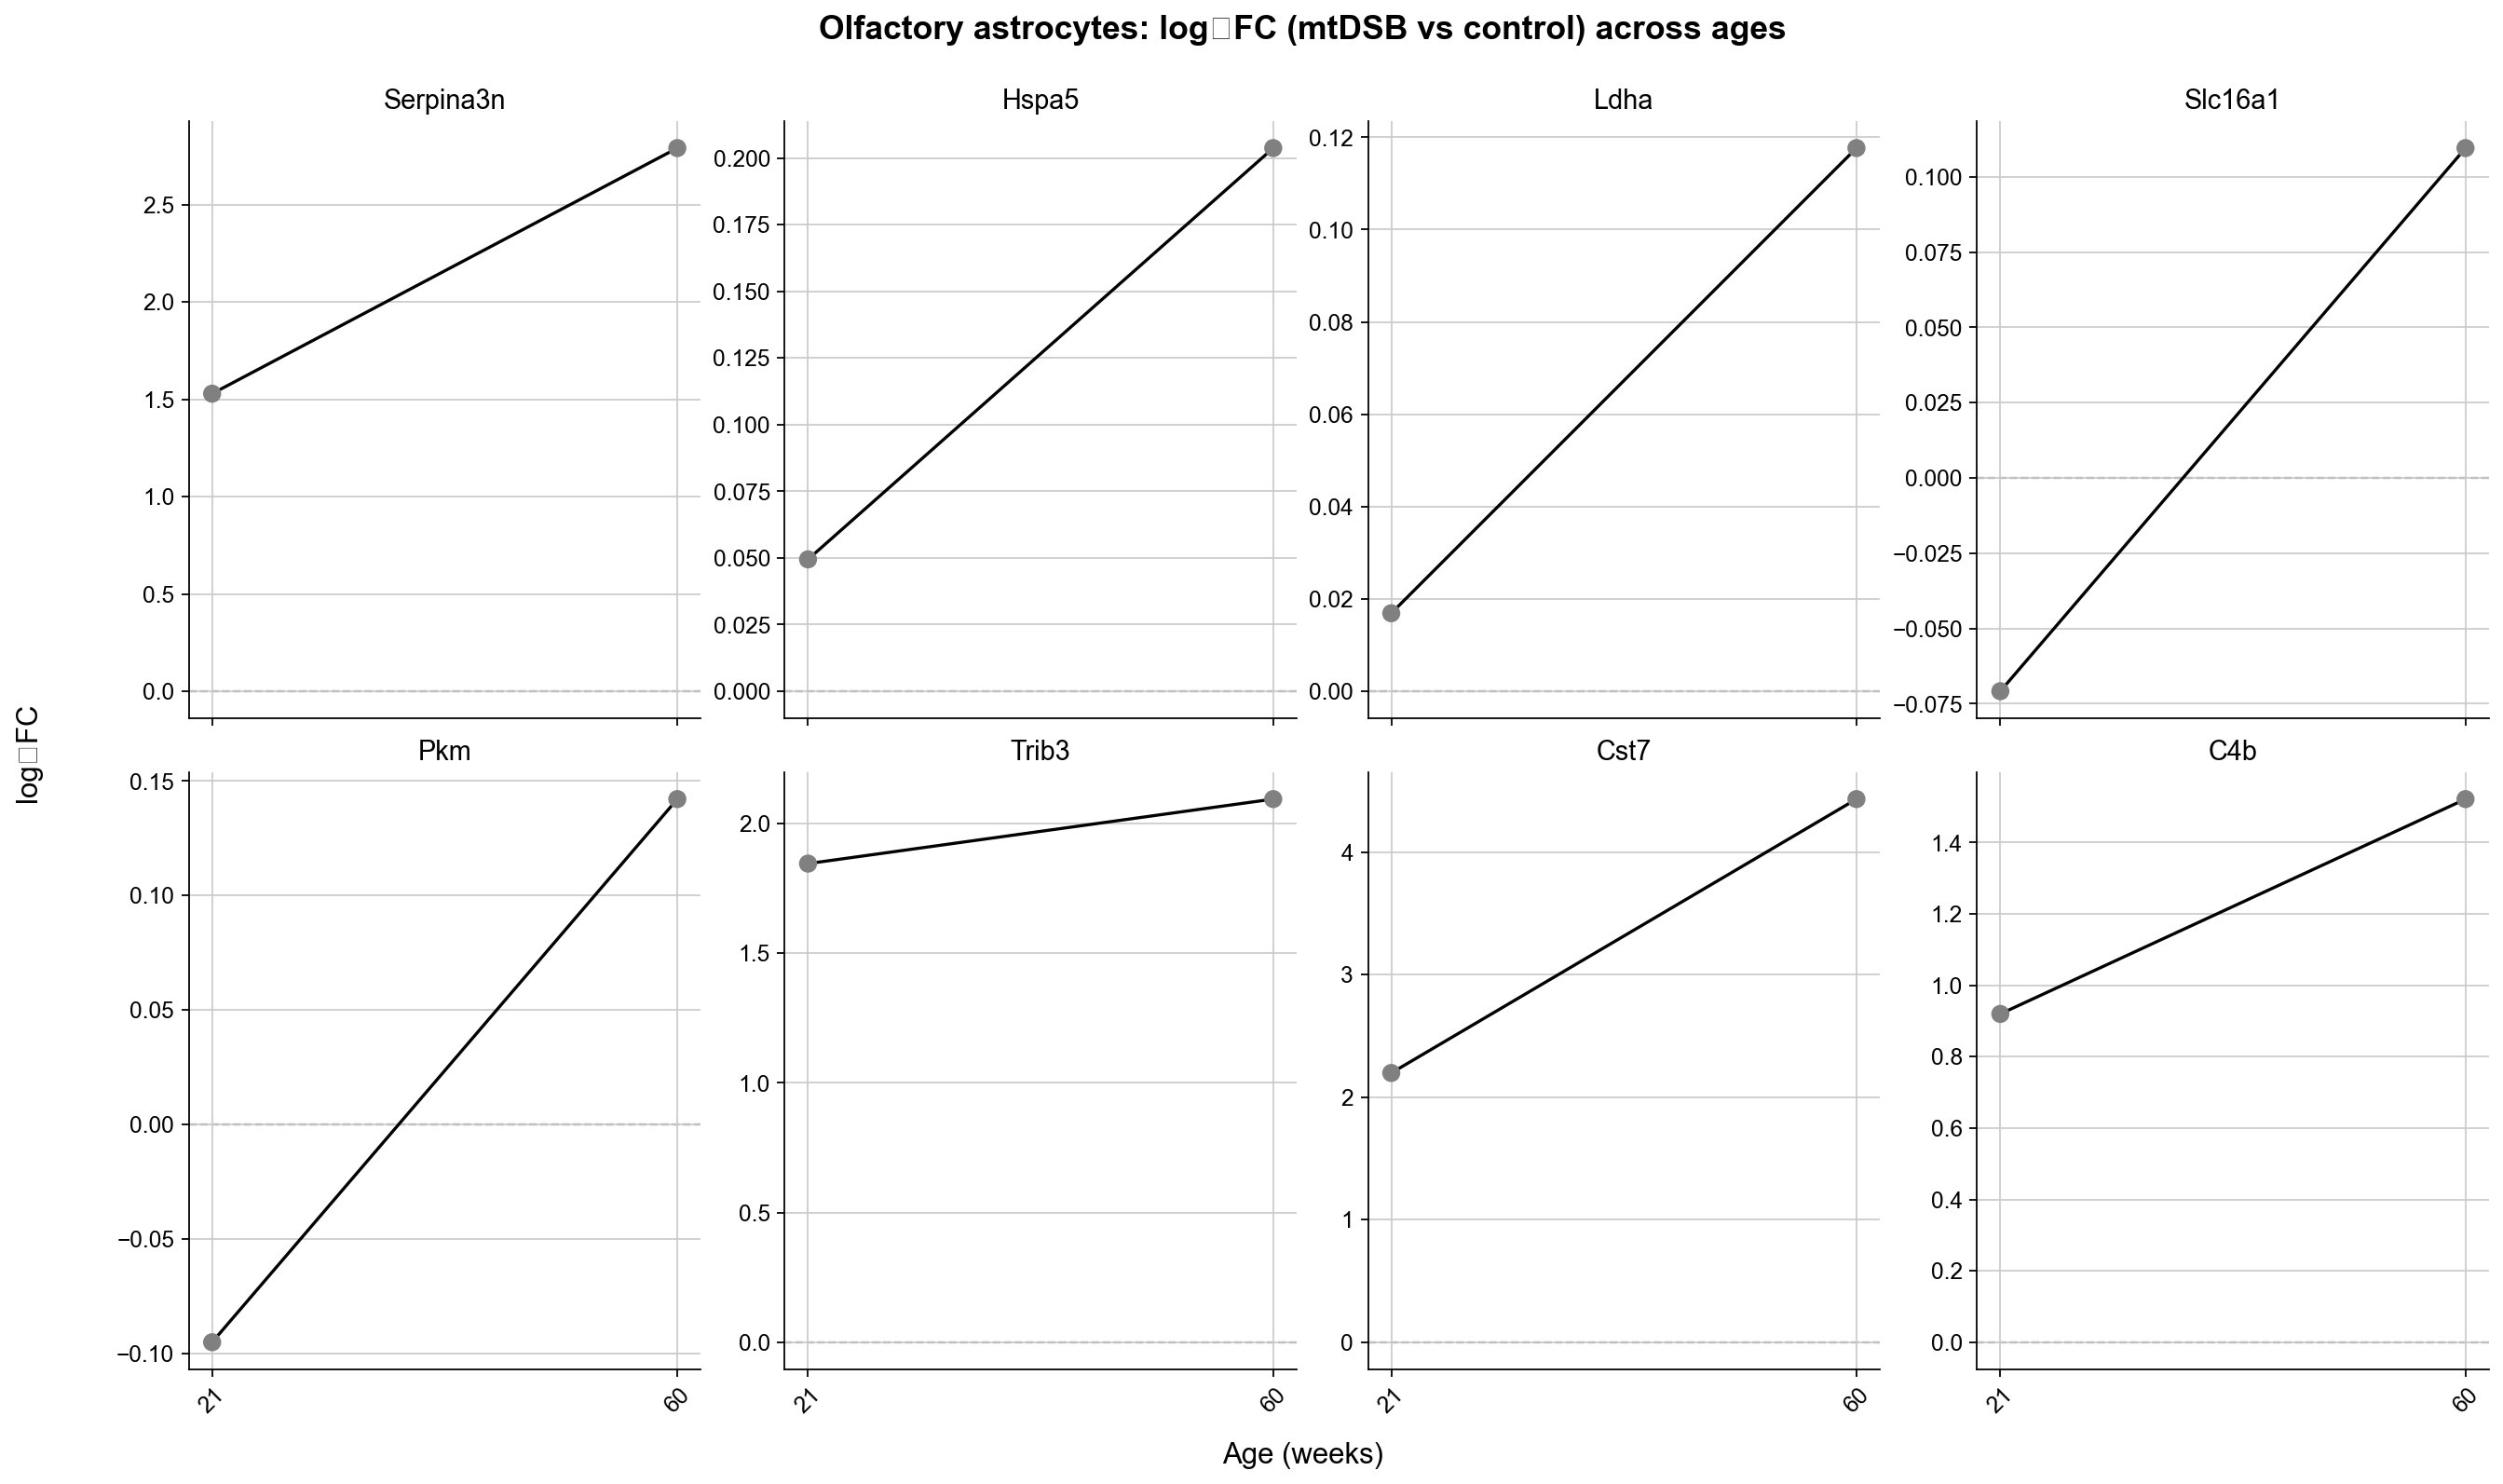

In [264]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Olfactory astrocytes", genes, sharey=False)

2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

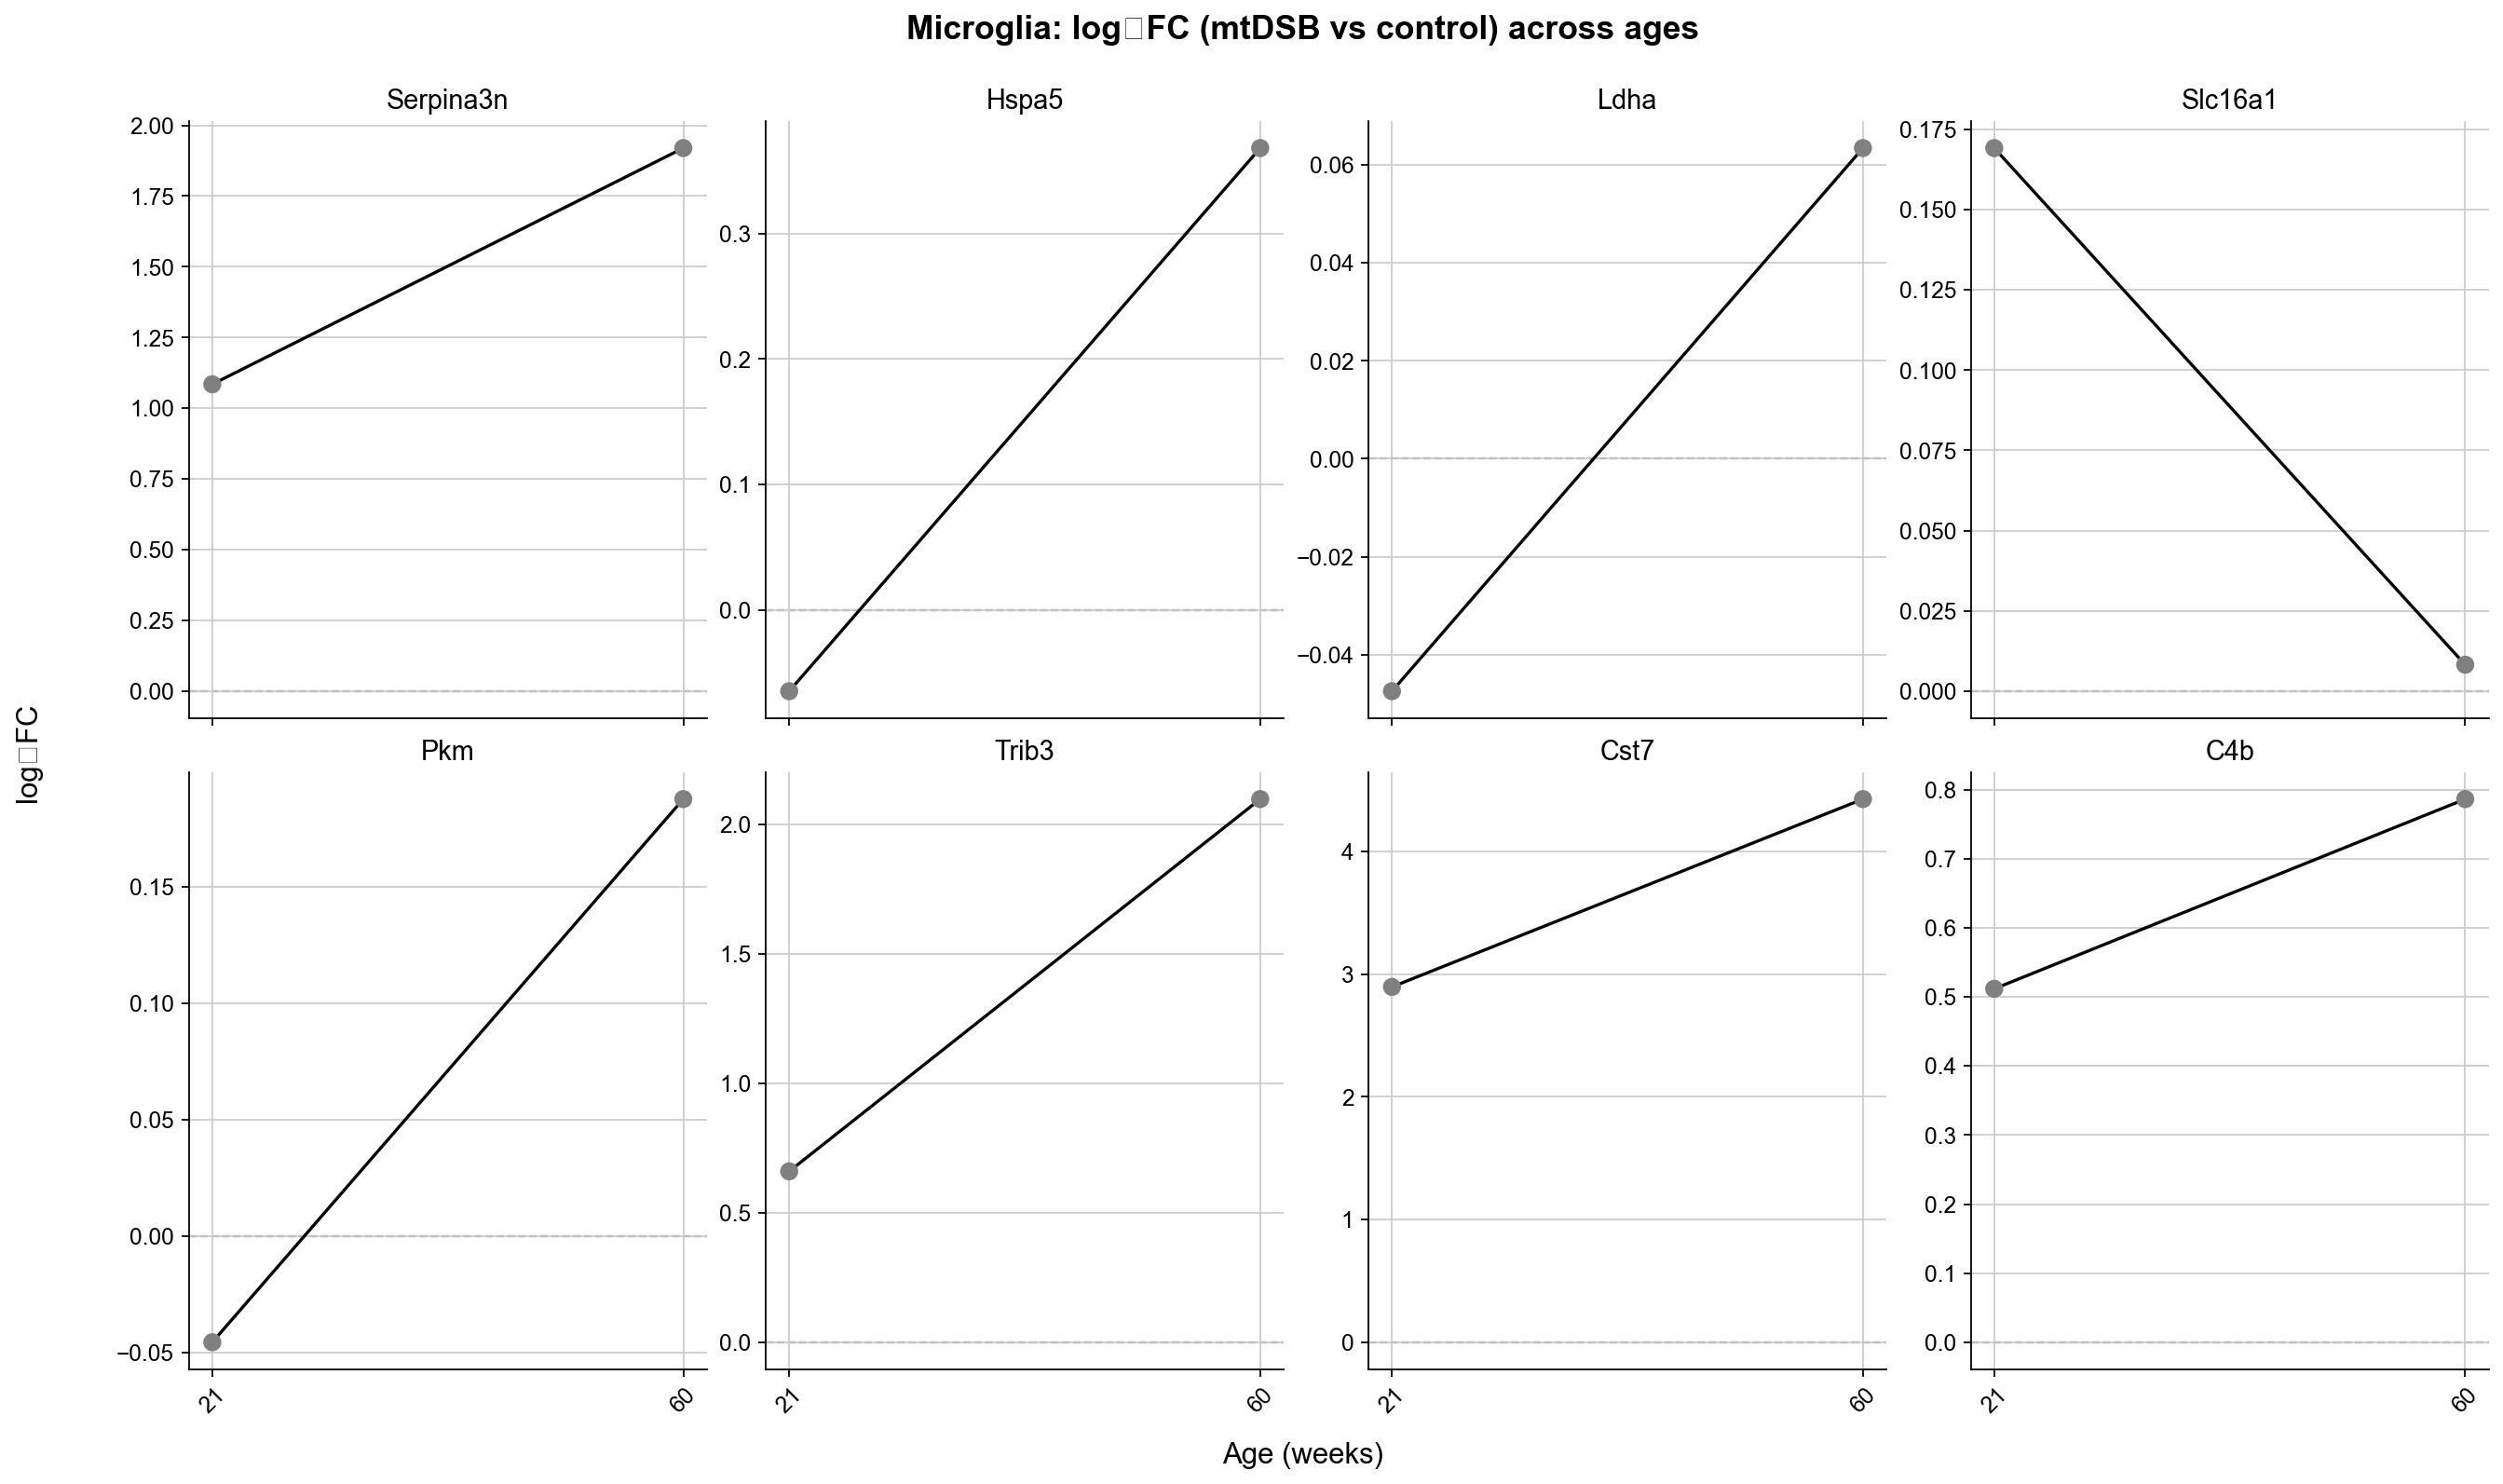

In [265]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Microglia", genes, sharey=False)

2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

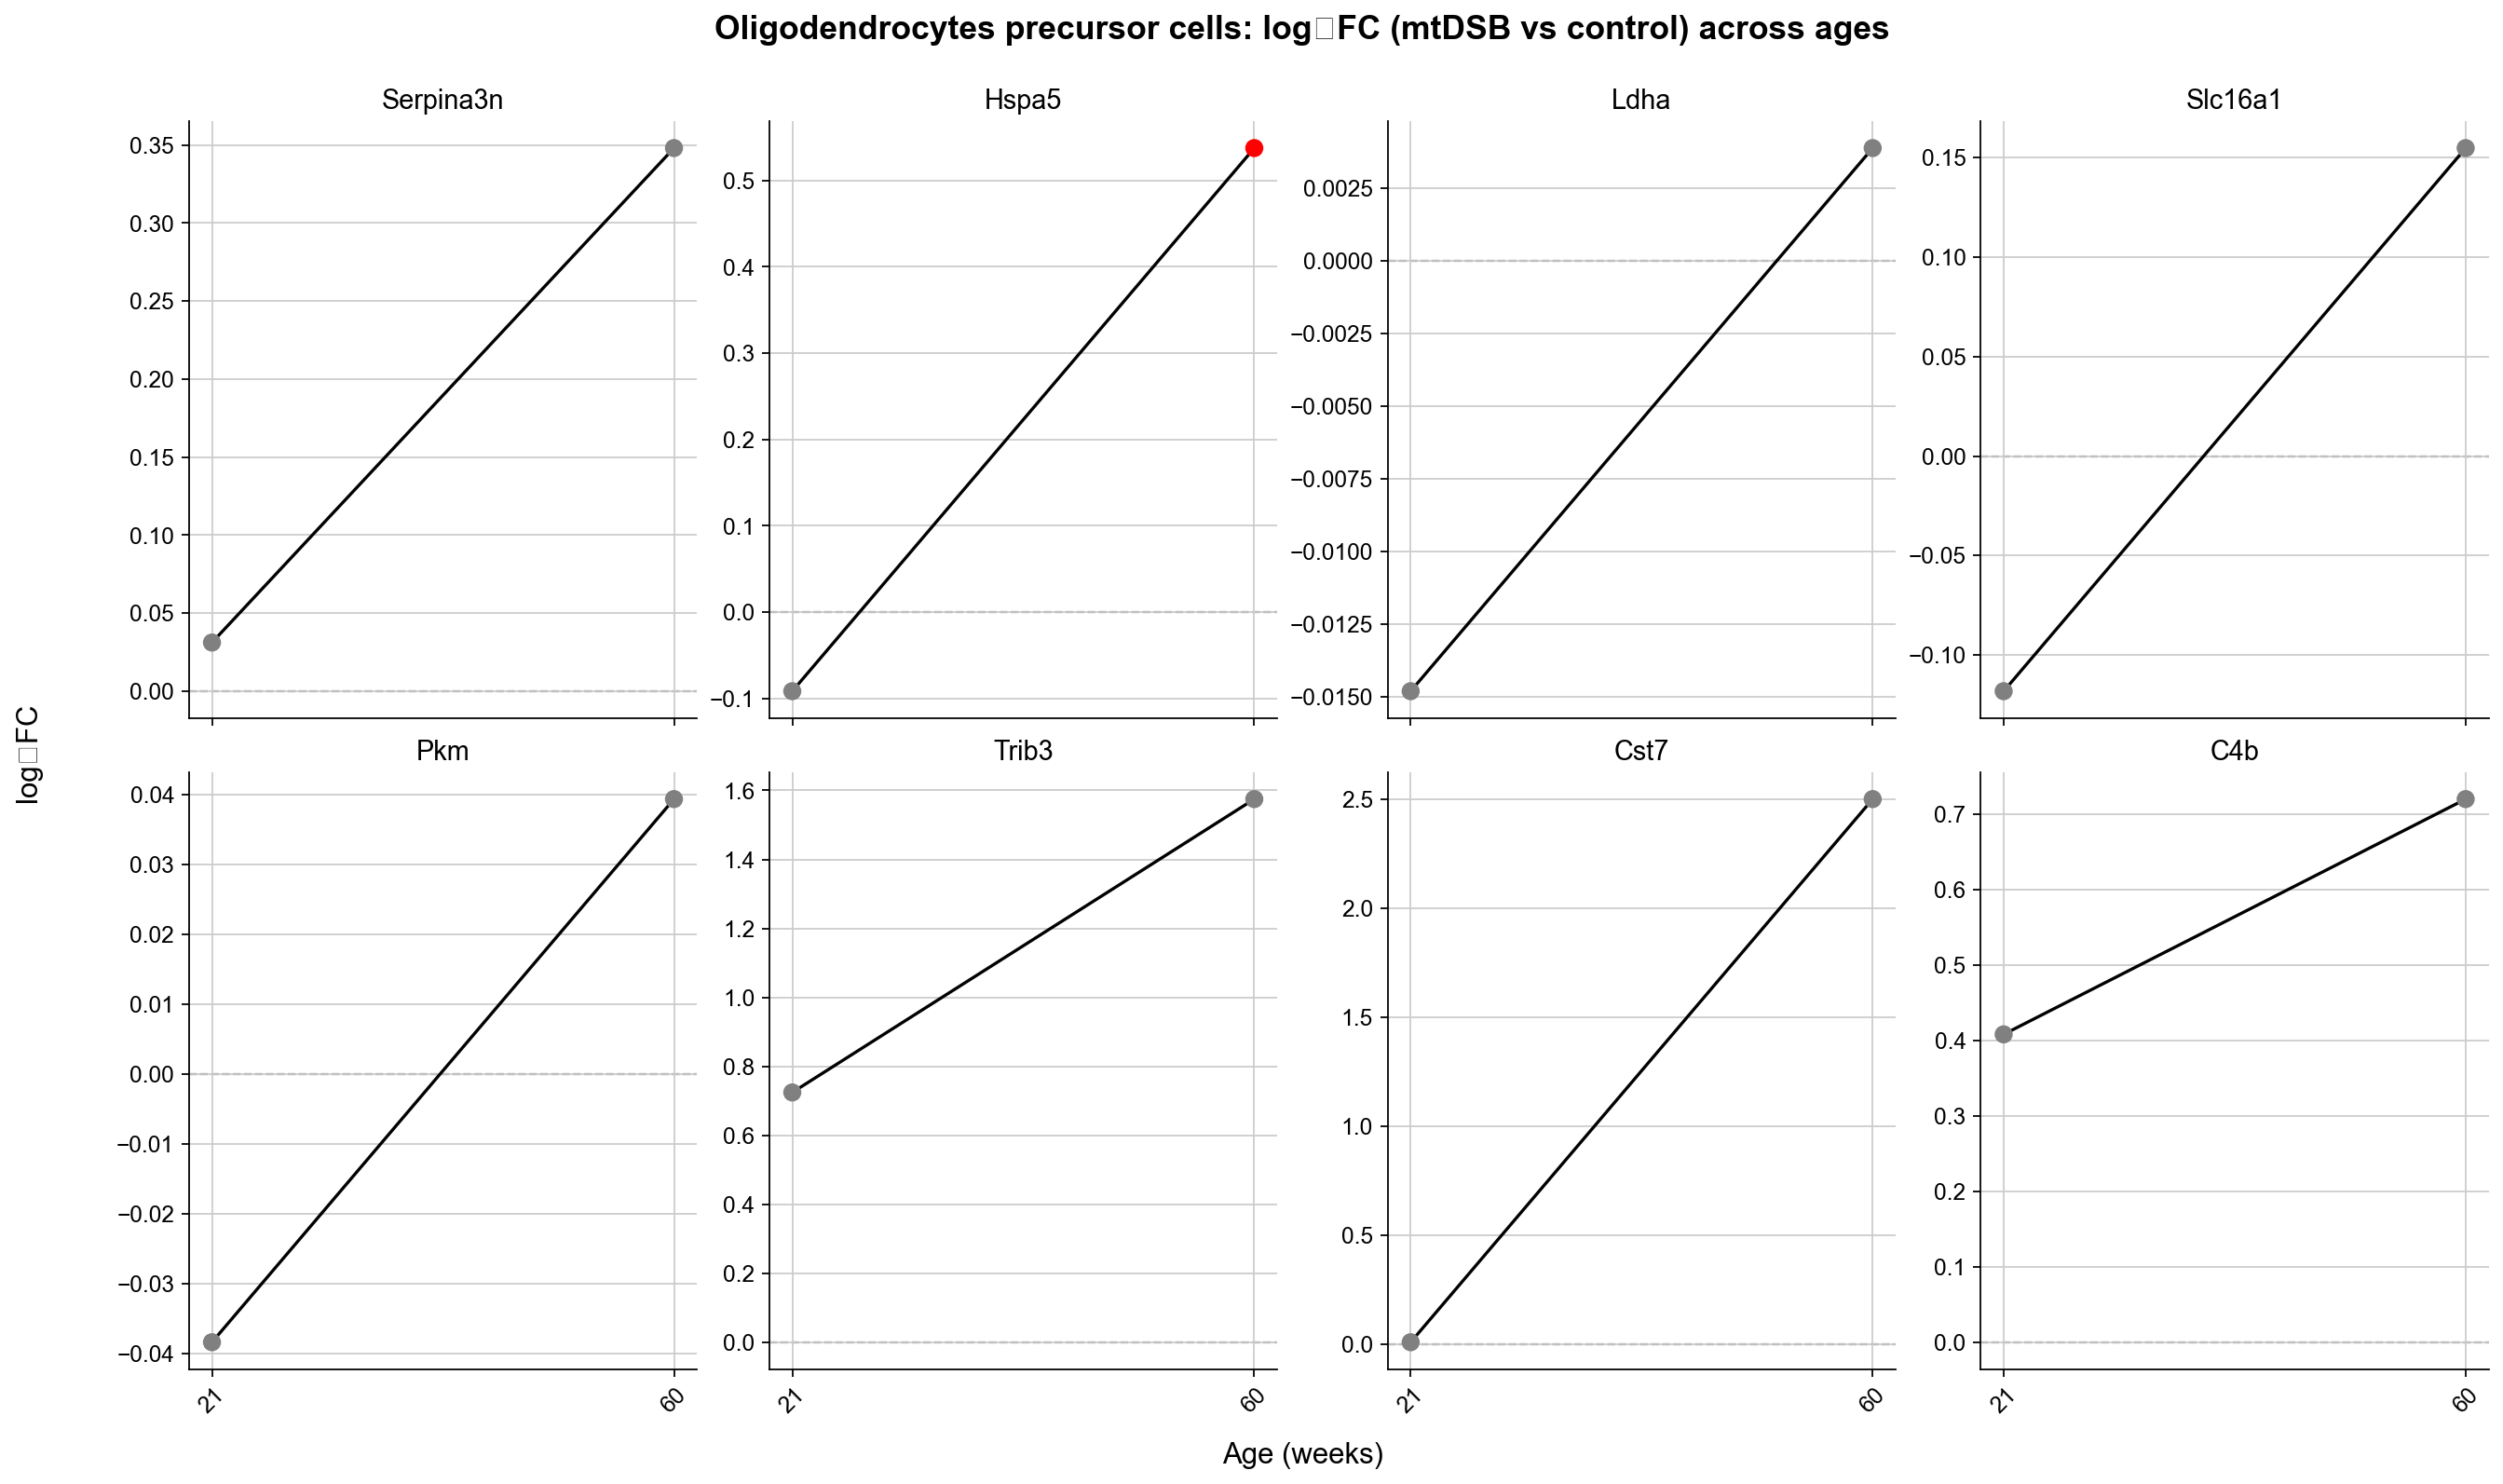

In [266]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "", genes, sharey=False)

2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

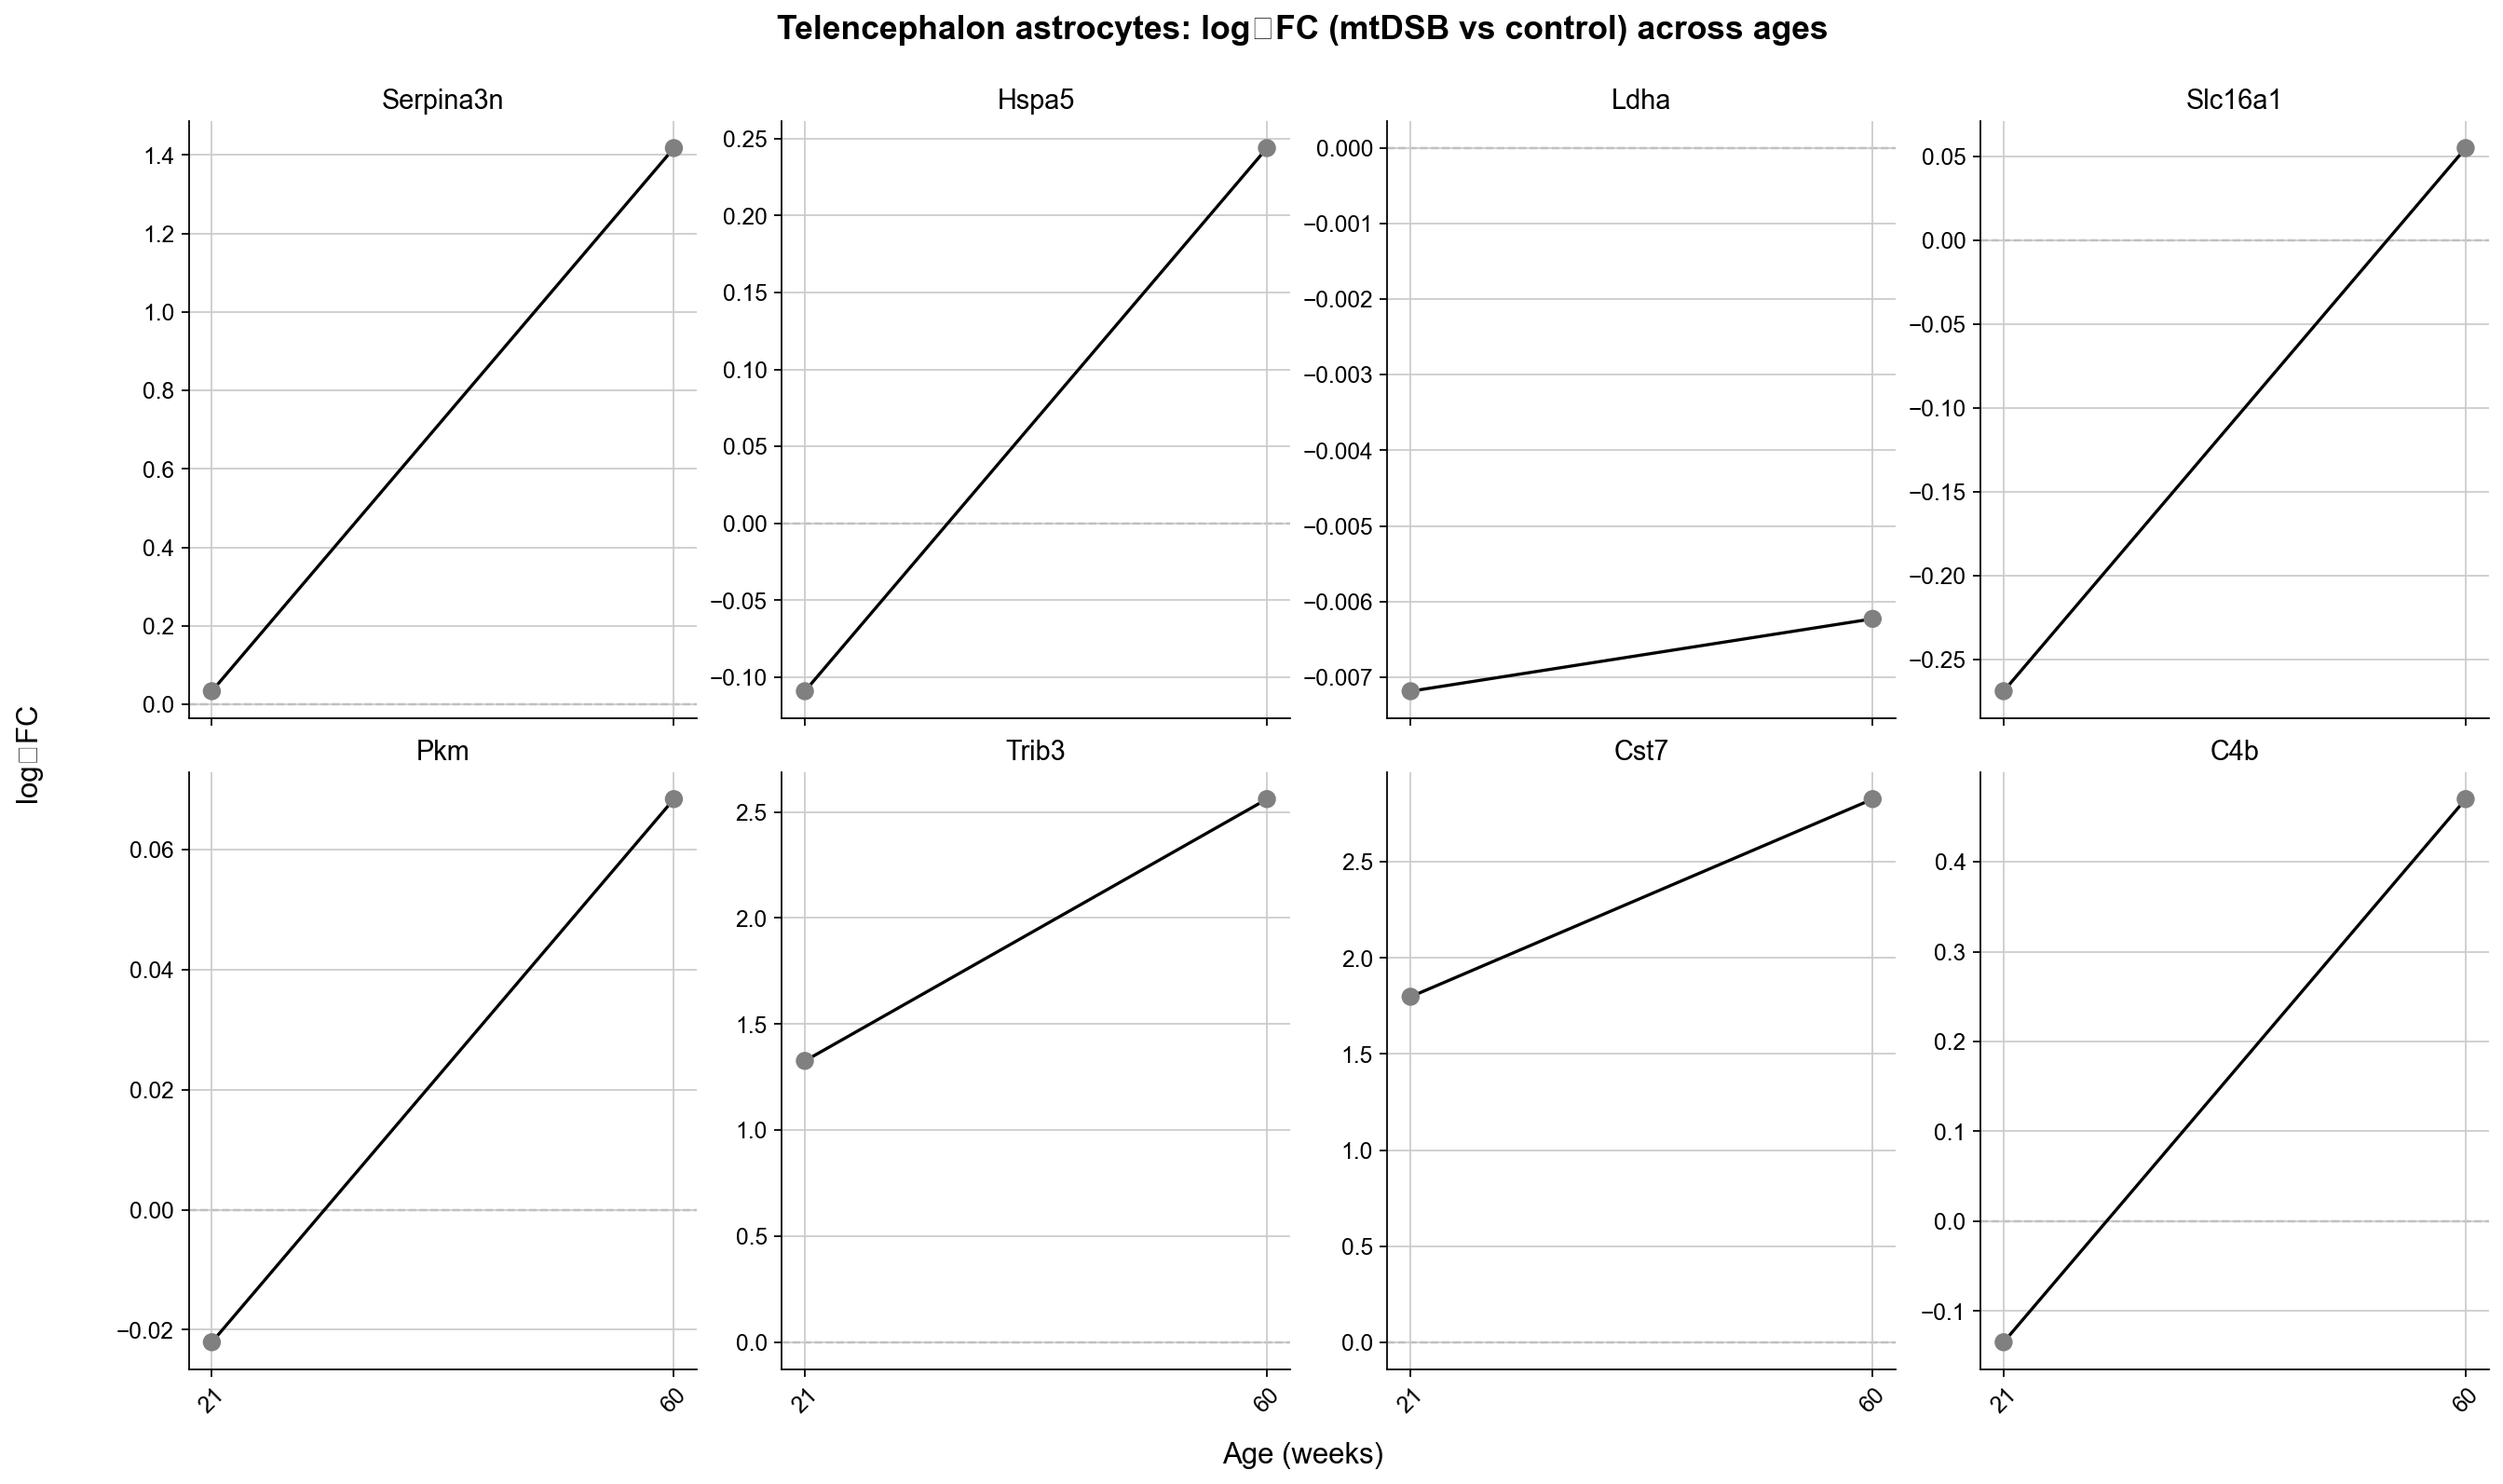

In [267]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Telencephalon astrocytes", genes, sharey=False)

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import math

def plot_expression_by_condition_grid(
    pb,
    ct,
    genes,
    norm=True,                 # CPM-normalize per sample
    q=None,                    # optional: highlight sig ages (not used here; keep for parity)
    ncols=4,                   # number of subplot columns
    sharey=True,               # share y-axis across genes for magnitude comparison
    figsize_per_panel=(4.0, 3.2),
    fontsize_base=13,
    suppress_warnings=True
):
    """
    Multi-panel plot of mean expression (pseudobulk) across ages for each condition.

    pb: dict-like, pb[ct] = (counts_df [genes x samples], meta_df [samples x meta])
    ct: cell class key present in pb
    genes: list of gene symbols to plot
    norm: if True, CPM-normalize per-sample library size before group averaging
    sharey: if True, use shared y-axis across all gene subplots
    """

    if suppress_warnings:
        warnings.filterwarnings("ignore")

    counts_df, meta_df = pb[ct]
    # keep only genes that exist
    genes_present = [g for g in genes if g in counts_df.index]
    missing = sorted(set(genes) - set(genes_present))
    if missing:
        print(f"Skipping missing genes ({len(missing)}): {', '.join(missing[:8])}" + ("..." if len(missing)>8 else ""))

    if len(genes_present) == 0:
        print("No requested genes found in counts_df.")
        return

    # Build long table for requested genes
    # sample-wise counts and metadata
    dat = counts_df.loc[genes_present].T  # samples x genes
    df = dat.stack().reset_index()
    df.columns = ["sample", "gene", "counts"]

    # attach meta
    meta = meta_df.copy()
    meta = meta.loc[df["sample"].unique()]  # ensure order/coverage
    # basic hygiene
    meta = meta.assign(
        age=meta["age"].astype(str).str.strip(),
        condition=meta["condition"].astype(str).str.strip()
    )
    df = df.merge(meta[["age", "condition"]], left_on="sample", right_index=True, how="left")

    # CPM normalize if requested
    if norm:
        lib_sizes = counts_df.sum(axis=0)  # per-sample library size
        df["cpm"] = df.apply(lambda r: (r["counts"] / lib_sizes.loc[r["sample"]]) * 1e6, axis=1)
        val_col = "cpm"
    else:
        val_col = "counts"

    # aggregate mean ± sem per condition × age × gene
    agg = (
        df.groupby(["gene", "condition", "age"], observed=True)[val_col]
          .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0.0)
          .reset_index()
    )

    # sort ages numerically if possible
    try:
        age_order = sorted(agg["age"].unique(), key=lambda x: float(x))
    except Exception:
        age_order = sorted(agg["age"].unique())

    # figure layout
    n = len(genes_present)
    nrows = math.ceil(n / ncols)
    fig_w = max(ncols * figsize_per_panel[0], 6.0)
    fig_h = max(nrows * figsize_per_panel[1], 3.5)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.ravel(axes)

    # If sharey=True, compute global y-limits from all panels for consistency
    ymins, ymaxs = [], []
    if sharey:
        for g in genes_present:
            sub = agg[agg["gene"] == g]
            if sub.empty:
                continue
            ymins.append((sub["mean"] - sub["sem"]).min())
            ymaxs.append((sub["mean"] + sub["sem"]).max())
        if ymins and ymaxs:
            y_min = 0 if norm else min(0, np.nanmin(ymins))
            y_max = np.nanmax(ymaxs) * 1.08
        else:
            y_min, y_max = None, None

    # per-plot drawing
    for i, g in enumerate(genes_present):
        ax = axes[i]
        sub = agg[agg["gene"] == g].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        # draw each condition line with error bars
        for cond, grp in sub.groupby("condition", observed=True):
            grp = grp.set_index("age").reindex(age_order).reset_index()
            ax.errorbar(
                grp["age"], grp["mean"], yerr=grp["sem"],
                marker="o", capsize=4, lw=2.0, markersize=6, label=str(cond)
            )

        ax.axhline(0, ls="--", color="0.7", lw=1)  # helpful baseline (works for CPM too)
        ax.set_title(g, fontsize=fontsize_base, pad=6)
        ax.tick_params(axis="x", labelrotation=45, labelsize=fontsize_base-2)
        ax.tick_params(axis="y", labelsize=fontsize_base-2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # set shared y limits if requested
        if sharey and (y_min is not None) and (y_max is not None):
            ax.set_ylim(y_min, y_max)

        # lightweight legend per first subplot only
        if i == 0:
            ax.legend(frameon=False, fontsize=fontsize_base-2, title="Condition", title_fontsize=fontsize_base-2)
        else:
            ax.legend().remove()

    # hide unused panels
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    # global labels offset away from plots
    units = "CPM" if norm else "counts"
    fig.suptitle(f"{ct}: mean {units} across ages by condition",
                 fontsize=fontsize_base+3, y=1.04, fontweight="bold")
    fig.text(0.5, -0.035, "Age (weeks)", ha="center", fontsize=fontsize_base+1)
    fig.text(-0.035, 0.5, f"Mean {units}", va="center", rotation="vertical", fontsize=fontsize_base+1)

    # extra margins so labels never overlap
    plt.subplots_adjust(bottom=0.14, left=0.11, right=0.99, top=0.93, wspace=0.25, hspace=0.35)
    plt.show()

2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

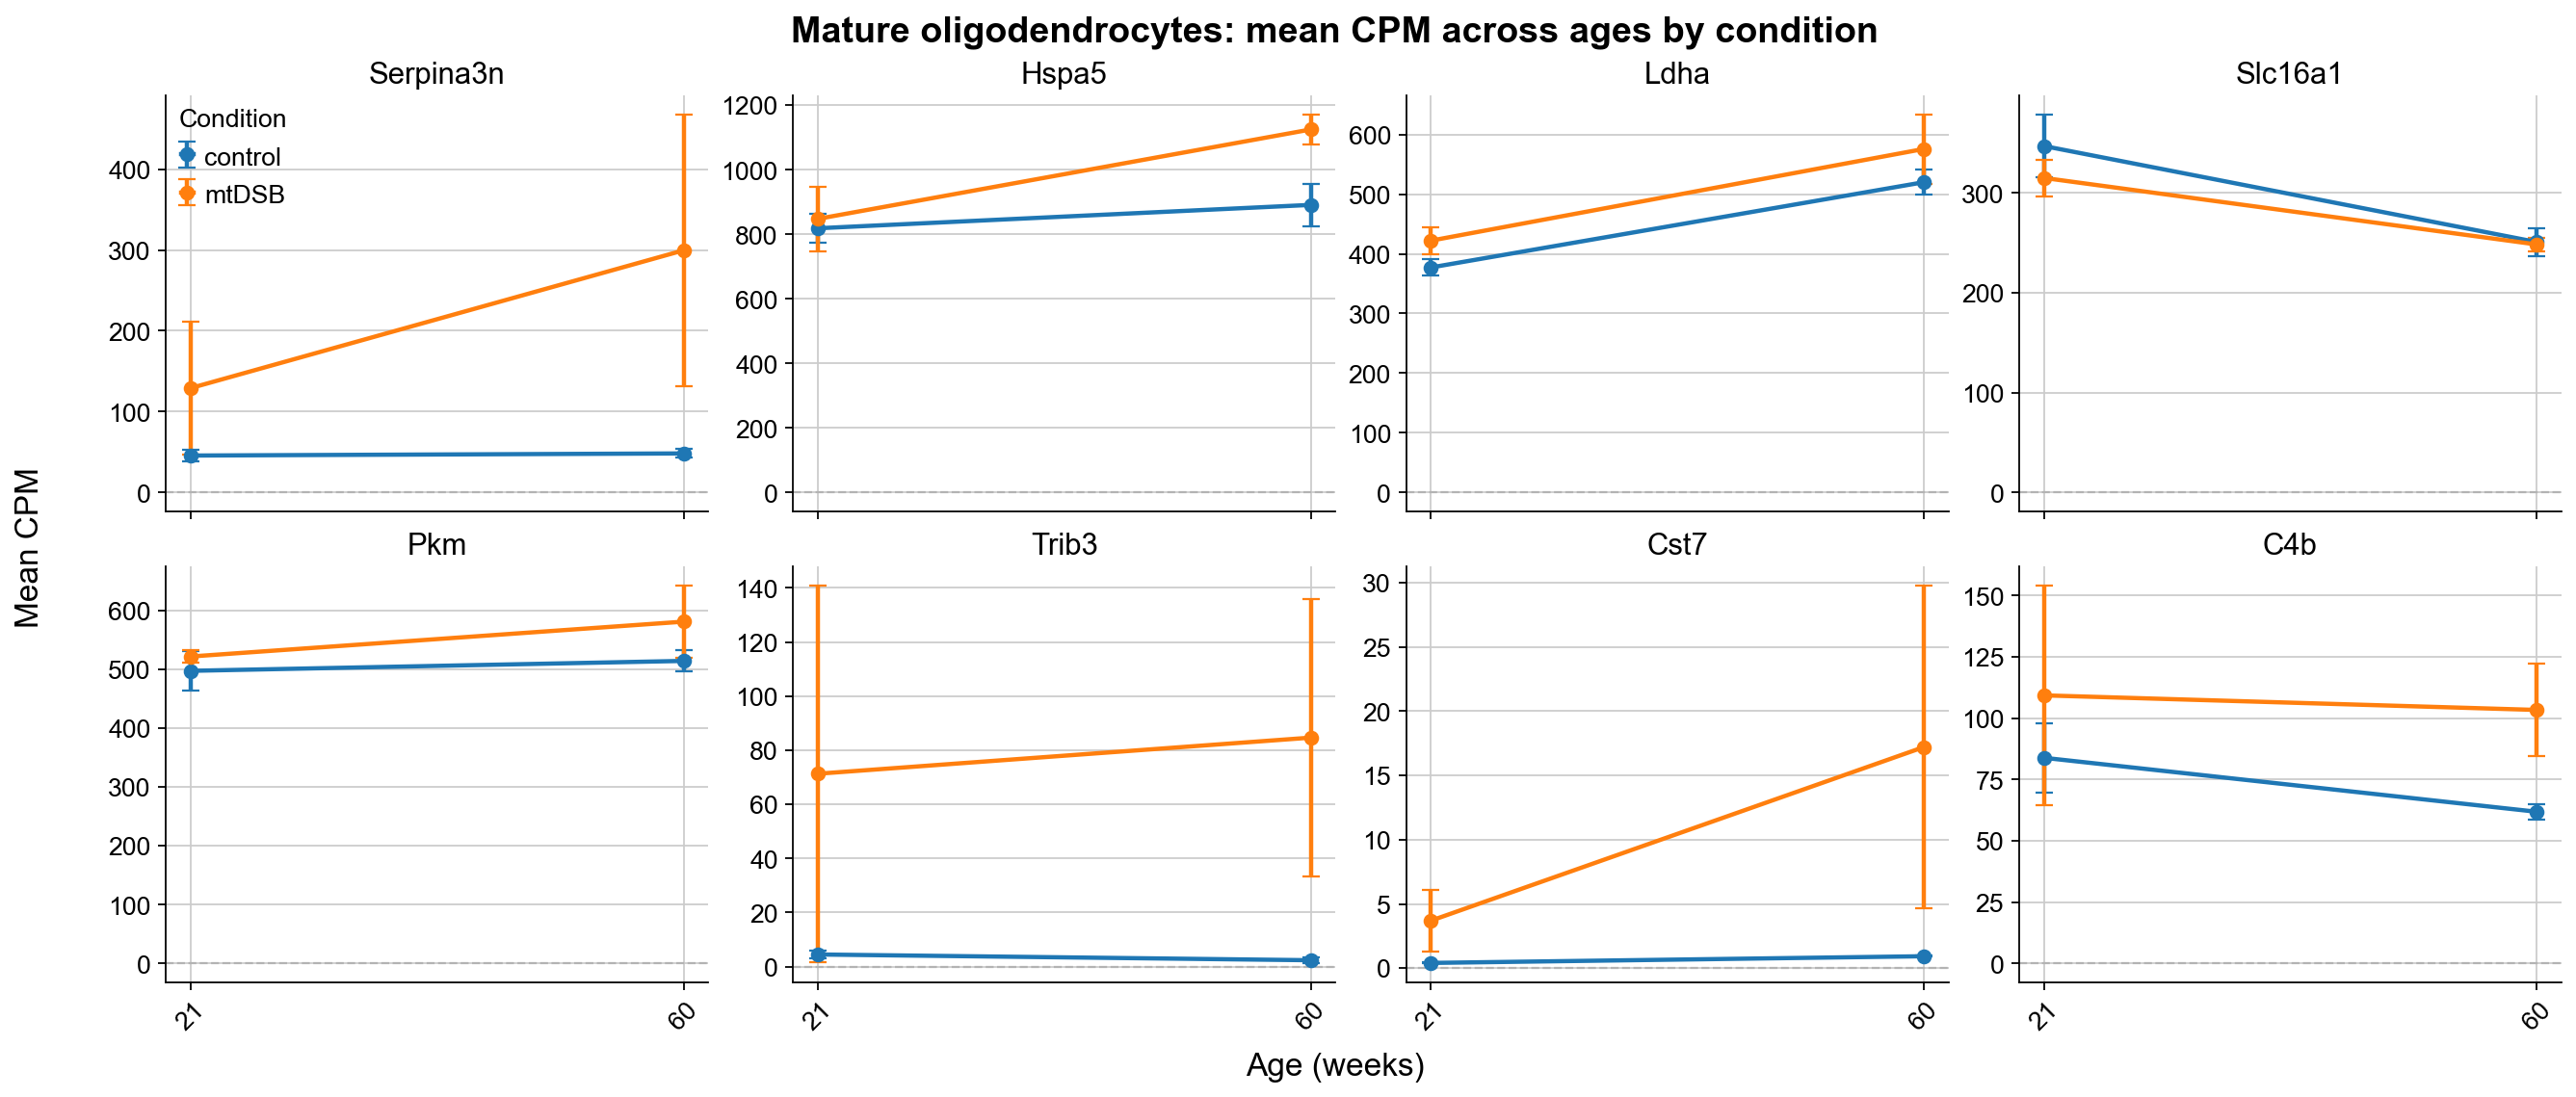

In [273]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_expression_by_condition_grid(
    pb,
    ct="Mature oligodendrocytes",
    genes=genes,
    norm=True,        # CPM
    ncols=4,
    sharey=False,      # compare magnitudes across genes
    fontsize_base=14
)

In [274]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def volcano_clean(
    res_df,
    lfc_col="log2FC_mtDSB_vs_control",
    padj_col="padj_mtDSB_vs_control",
    title="mtDSB vs control (60 wks)",
    lfc_thr=1.0, q=0.05,
    label_top_fdr=10,            # how many best FDR genes to label
    label_top_abs_lfc=10,        # plus how many most extreme |LFC| to label
    max_labels=20,               # hard cap on labels
    highlight_genes=None,        # force-label these even if not in top sets
    figsize=(9,7), fontsize=13,
    pretty_print=True,           # <-- NEW: print a compact table
    to_csv_path=None             # <-- NEW: save that table as CSV if path given
):
    # --- prep ---
    df = (res_df.copy()
                 .replace([np.inf, -np.inf], np.nan)
                 .dropna(subset=[lfc_col, padj_col]))
    df["neglog10q"] = -np.log10(df[padj_col].clip(lower=1e-300))
    sig = (df[padj_col] < q) & (df[lfc_col].abs() >= lfc_thr)

    # ranks for selection/debug
    df["rank_fdr"] = df[padj_col].rank(method="dense")
    df["rank_abs_lfc"] = df[lfc_col].abs().rank(ascending=False, method="dense")

    # --- choose labels ---
    idx_fdr = df.sort_values(padj_col).head(label_top_fdr).index
    idx_lfc = df.reindex(df[lfc_col].abs().sort_values(ascending=False)
                         .head(label_top_abs_lfc).index).index
    pick = set(idx_fdr).union(set(idx_lfc))
    if highlight_genes:
        pick.update(set(df.index.intersection(highlight_genes)))
    if len(pick) > max_labels:
        pick = set(df.loc[list(pick)].sort_values("neglog10q", ascending=False)
                   .head(max_labels).index)

    # --- build pretty table of the picked genes ---
    picked_df = (df.loc[sorted(pick, key=lambda g: (df.at[g, padj_col], -abs(df.at[g, lfc_col]))) ,
                       [lfc_col, padj_col, "neglog10q", "rank_fdr", "rank_abs_lfc"]]
                   .rename(columns={
                       lfc_col: "log2FC",
                       padj_col: "padj",
                       "neglog10q": "-log10(FDR)"
                   }))
    picked_df.index.name = "gene"

    if pretty_print:
        # concise, aligned print
        print("\n=== Important genes (labeled on plot) ===")
        print(picked_df.round({"log2FC":3, "padj":3, "-log10(FDR)":2}).to_string())

    if to_csv_path:
        picked_df.to_csv(to_csv_path)

    # --- plot ---
    plt.figure(figsize=figsize, dpi=150)
    # background
    plt.scatter(df[lfc_col], df["-log10(FDR)"] if "-log10(FDR)" in df.columns else df["neglog10q"],
                s=16, alpha=0.35, color="lightgrey", label="not sig")
    # significant up/down
    up = df[sig & (df[lfc_col] > 0)]
    dn = df[sig & (df[lfc_col] < 0)]
    plt.scatter(up[lfc_col], up["neglog10q"], s=28, color="#d73027", label="Up (sig)")
    plt.scatter(dn[lfc_col], dn["neglog10q"], s=28, color="#4575b4", label="Down (sig)")

    # thresholds
    plt.axvline(+lfc_thr, ls="--", color="k", lw=1)
    plt.axvline(-lfc_thr, ls="--", color="k", lw=1)
    plt.axhline(-np.log10(q), ls="--", color="k", lw=1)

    plt.xlabel("log₂ fold change (mtDSB vs control)", fontsize=fontsize)
    plt.ylabel("-log₁₀(FDR)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2, pad=10)

    # labels with repulsion/arrows
    texts = []
    try:
        from adjustText import adjust_text
        for g in picked_df.index:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            t = plt.text(x, y, g, fontsize=fontsize-3, va="bottom", ha="center")
            texts.append(t)
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)
        adjust_text(
            texts,
            only_move={'points':'y', 'text':'xy'},
            expand_points=(1.2, 1.4),
            expand_text=(1.1, 1.2),
            arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
        )
    except ImportError:
        for g in picked_df.index:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            dx = 0.15 if x >= 0 else -0.15
            dy = 0.25
            plt.annotate(
                g, xy=(x, y), xytext=(x+dx, y+dy),
                fontsize=fontsize-3,
                arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
                ha="center", va="bottom"
            )
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)

    plt.legend(frameon=False, fontsize=fontsize-3)
    plt.tight_layout()
    plt.show()

    # also return the table for downstream use
    return picked_df


=== Important genes (labeled on plot) ===
           log2FC   padj  -log10(FDR)  rank_fdr  rank_abs_lfc
gene                                                         
Pmch       -3.406  0.000         6.30       1.0           8.0
Gabra2      1.155  0.000         4.92       2.0         190.0
Mt2         0.694  0.000         4.53       3.0         487.0
Hcrt       -4.498  0.001         3.03       4.0           4.0
Gfap        1.254  0.006         2.24       5.0         159.0
Serpine1    3.166  0.009         2.05       6.0          12.0
Trh         1.552  0.009         2.05       6.0          98.0
Ccl3        2.859  0.026         1.58       7.0          16.0
Slc11a1     1.575  0.027         1.57       8.0          91.0
Id1         0.848  0.030         1.53       9.0         345.0
Itga5       1.812  0.037         1.43      10.0          59.0
Cercam     -0.591  0.046         1.34      11.0         633.0
Gpnmb       3.206  0.075         1.13      13.0          11.0
Trib3       5.097  0.080   

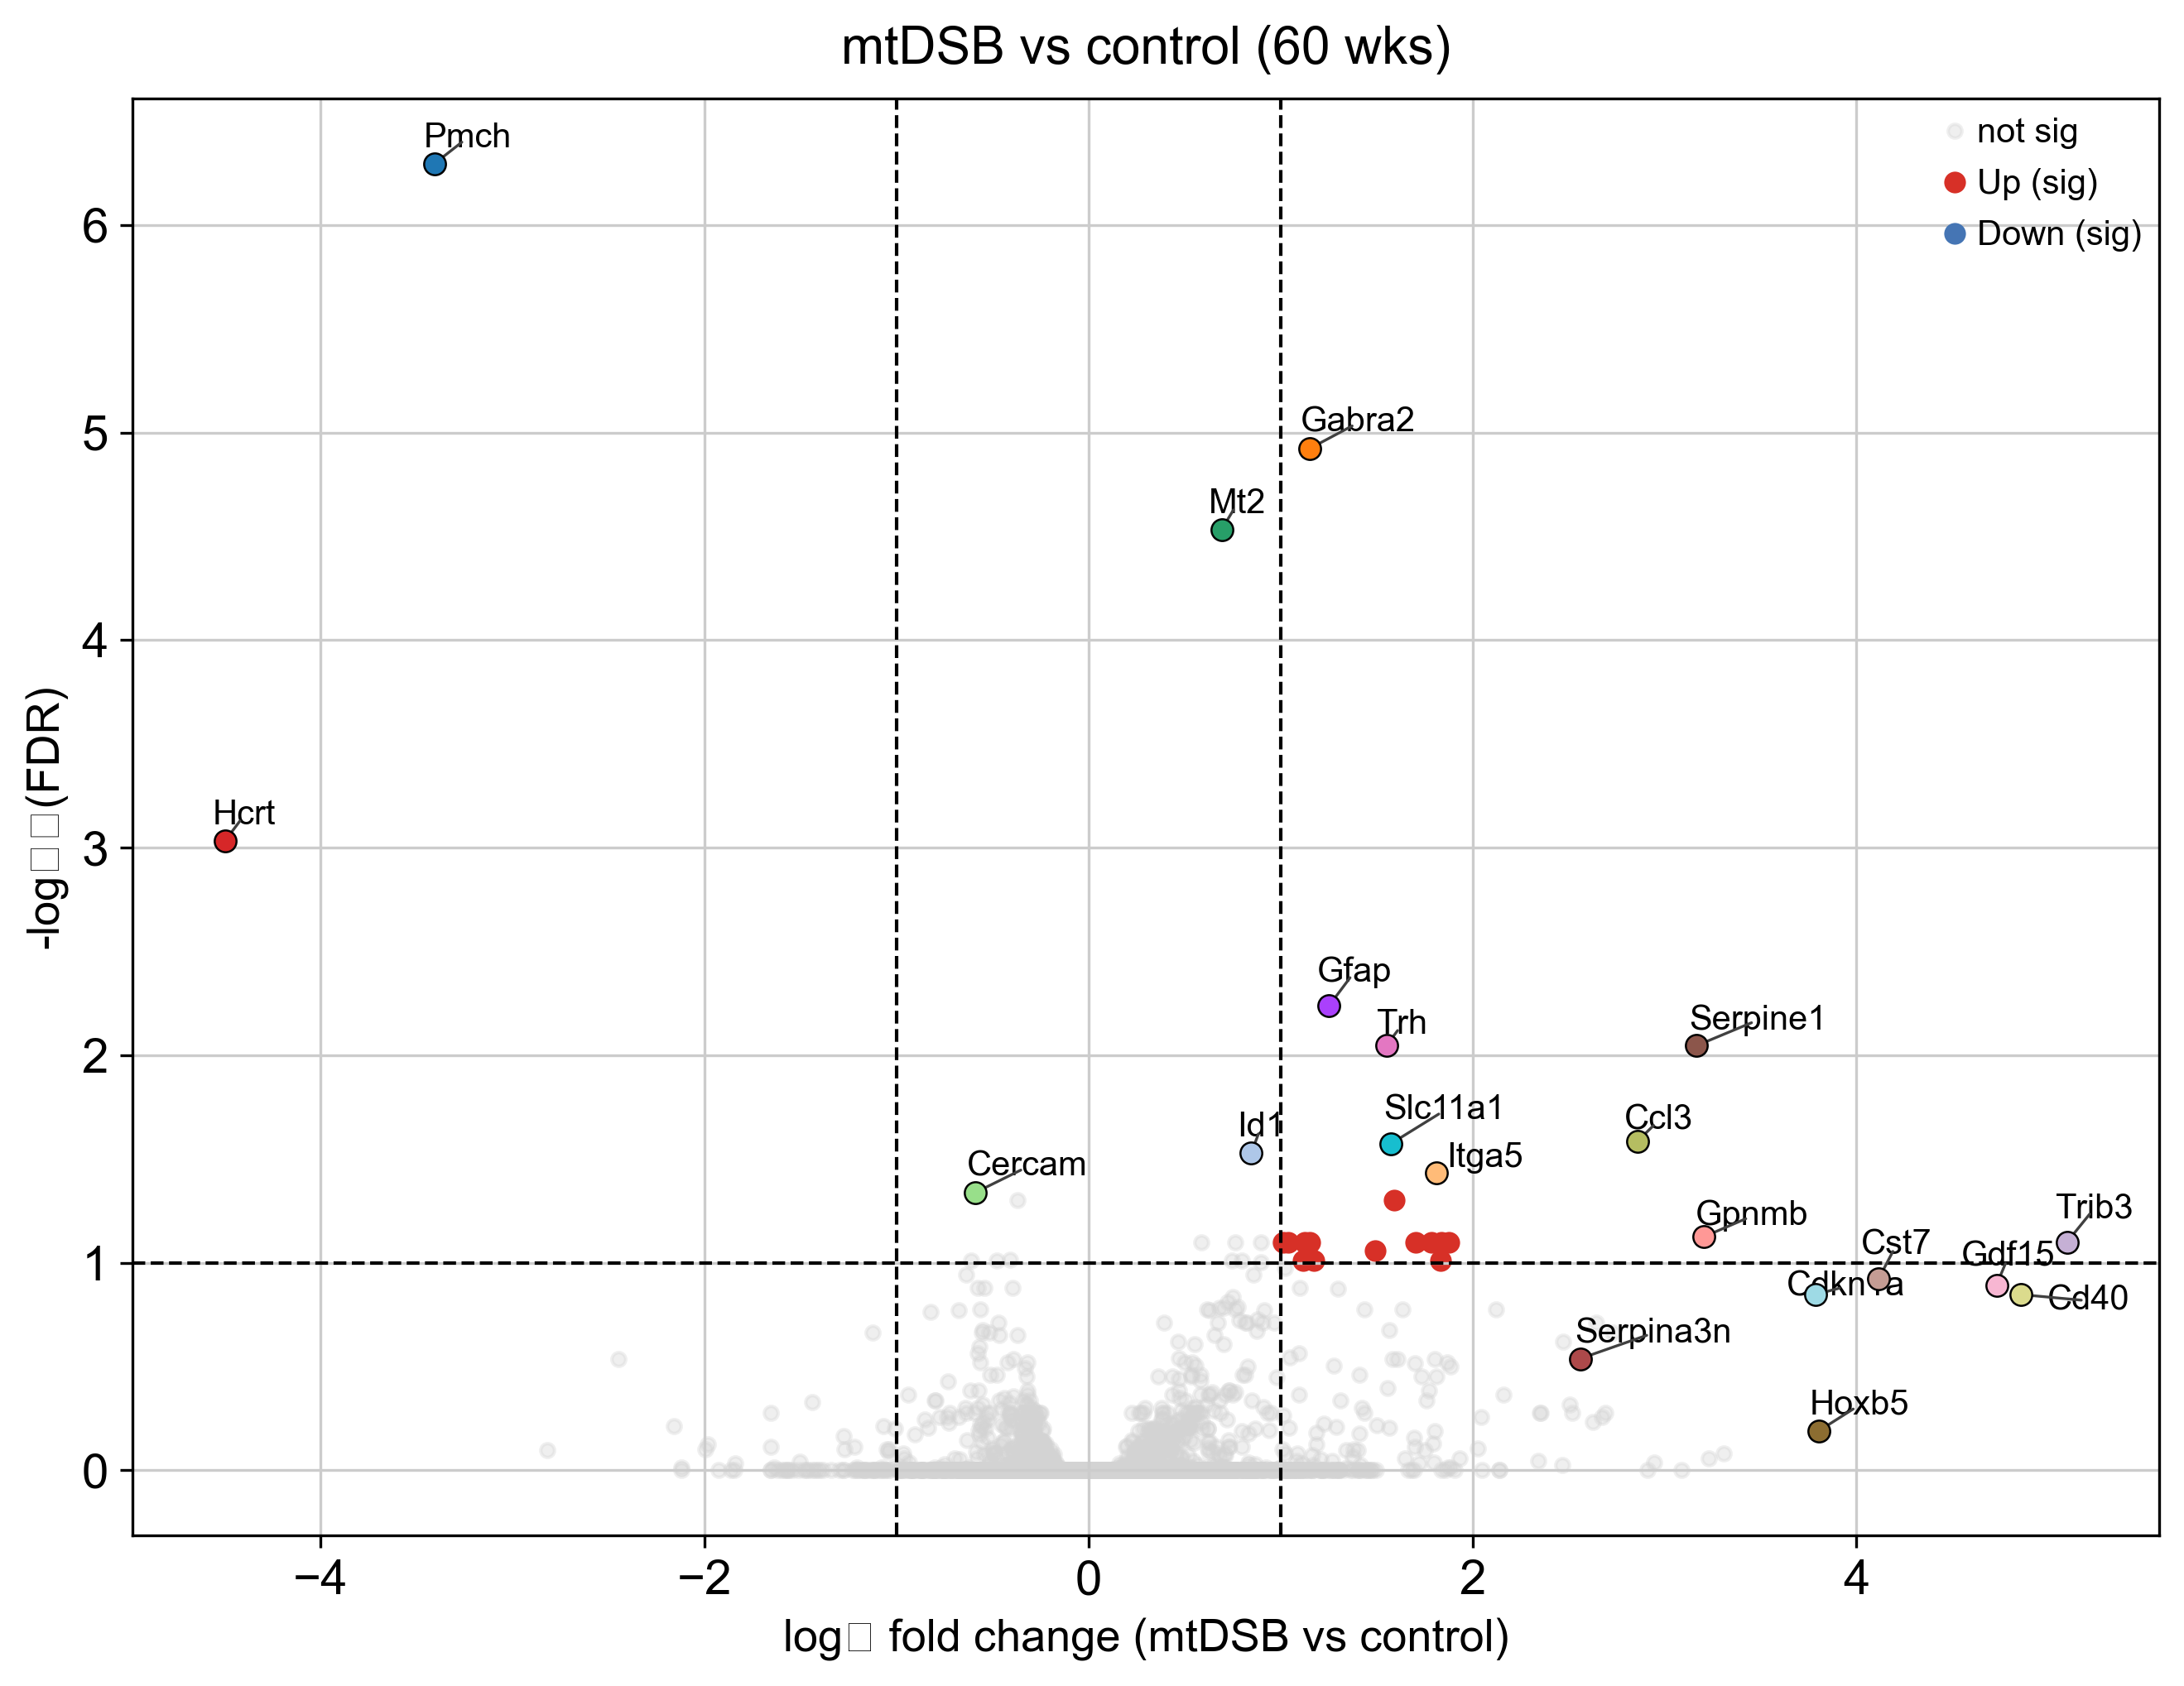

In [275]:
picked60 = volcano_clean(
    res60,
    title="mtDSB vs control (60 wks)",
    q=0.1, lfc_thr=1.0,
    label_top_fdr=12, label_top_abs_lfc=12, max_labels=20,
    highlight_genes=["Trib3", "Cst7", "Hspa5", "Gdf15", 'Serpina3n'],
    to_csv_path=None  # optional
)


=== Important genes (labeled on plot) ===
        log2FC   padj  -log10(FDR)  rank_fdr  rank_abs_lfc
gene                                                      
Fezf1    2.889  0.000         3.42       1.0          23.0
Mt1      1.129  0.000         3.32       2.0         244.0
Trh      2.008  0.010         2.00       3.0          65.0
Nkx6-2  -0.243  0.034         1.47       4.0        1545.0
Bglap2  -2.835  0.088         1.06       5.0          24.0
Trim36  -0.627  0.105         0.98       6.0         591.0
Otp      2.186  0.134         0.87       7.0          55.0
Rab10   -0.219  0.140         0.85       8.0        1673.0
Col1a1  -1.937  0.204         0.69       9.0          75.0
Col1a2  -1.433  0.204         0.69       9.0         152.0
Cst7     3.107  0.214         0.67      10.0          13.0
Bglap   -2.983  0.214         0.67      10.0          18.0
Hoxb3   -3.693  0.422         0.37      13.0           9.0
Hcrt     4.198  0.435         0.36      14.0           3.0
Hoxb5   -5.00

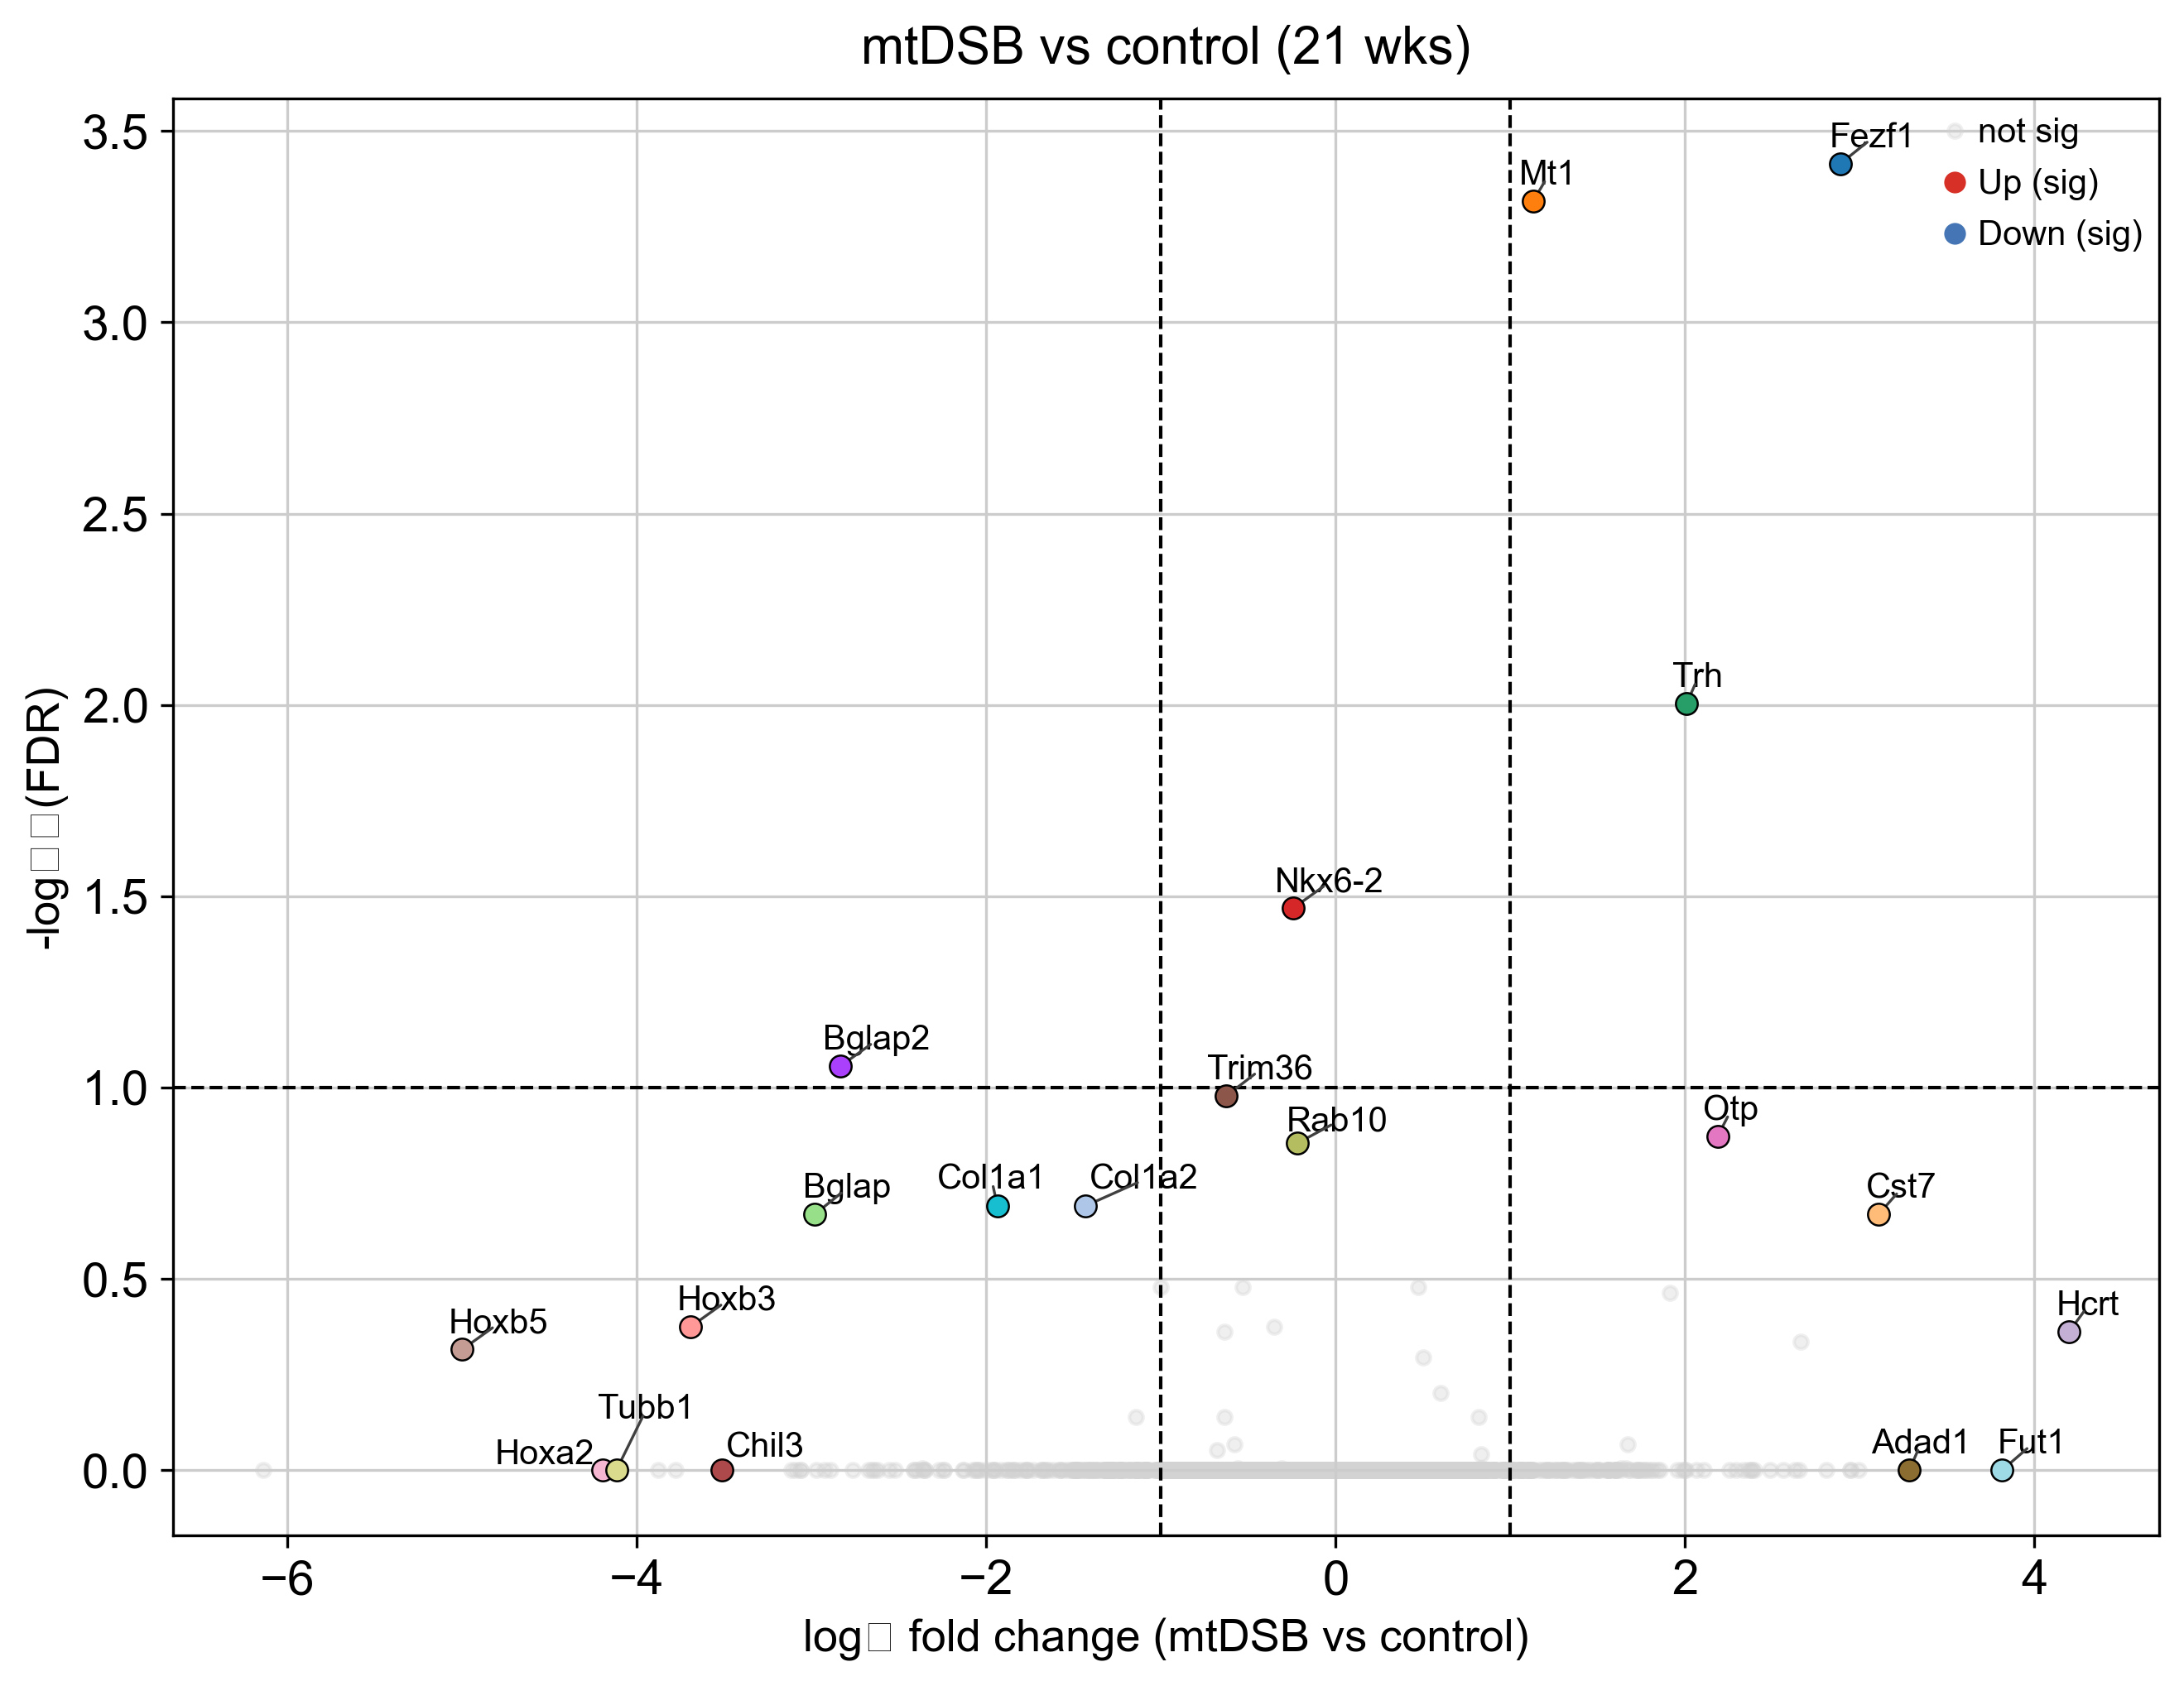

In [276]:
picked21 = volcano_clean(
    res21,
    title="mtDSB vs control (21 wks)",
    q=0.1, lfc_thr=1.0,
    label_top_fdr=12, label_top_abs_lfc=12, max_labels=20,
    highlight_genes=["Trib3", "Cst7", "Hspa5", "Gdf15", 'Serpina3n'],
    to_csv_path=None  # optional
)

In [343]:
import numpy as np
import pandas as pd

def pick_top_per_age(
    res21, res60,
    lfc_col="log2FC_mtDSB_vs_control",
    padj_col="padj_mtDSB_vs_control",  # can also be "pvalue_mtDSB_vs_control"
    q=0.05,
    top_n_each=20,
    alpha_lfc=1.0,     # weight for |LFC|
    beta_p=0.0,        # weight for -log10(p); set 0 for pure LFC
    force_lfc_min=0.0, # require |LFC| >= this (0 disables)
    require_sig=False, # if True, require p<q for that age
    age_specific=False,# if True, drop genes significant in both ages
    max_labels=None    # optional cap on size of union 'picks'
):
    """
    Rank genes per age by a linear score:
        score_age = alpha_lfc * |LFC_age| + beta_p * (-log10(p_age))
    Then take top_n_each per age and return their union (+ ordering preserved).
    """

    # build combined table
    genes = res21.index.intersection(res60.index)
    A = res21.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc21", padj_col:"p21"})
    B = res60.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc60", padj_col:"p60"})
    df = A.join(B)
    # clean
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["lfc21","lfc60"])  # keep rows with both LFCs

    # choose p-values/FDRs; clip to avoid -log10(0)
    p21 = df["p21"].astype(float).clip(lower=1e-300)
    p60 = df["p60"].astype(float).clip(lower=1e-300)

    # basic masks
    sig21 = p21 < q
    sig60 = p60 < q
    lfc_ok_21 = df["lfc21"].abs() >= float(force_lfc_min)
    lfc_ok_60 = df["lfc60"].abs() >= float(force_lfc_min)

    # pools for ranking
    if require_sig:
        pool21 = df.loc[sig21 & lfc_ok_21].copy()
        pool60 = df.loc[sig60 & lfc_ok_60].copy()
    else:
        pool21 = df.loc[lfc_ok_21].copy()
        pool60 = df.loc[lfc_ok_60].copy()

    # fallbacks if empty
    if pool21.empty:
        pool21 = df.copy()
    if pool60.empty:
        pool60 = df.copy()

    # scores
    s21 = alpha_lfc * pool21["lfc21"].abs() + beta_p * (-np.log10(p21.loc[pool21.index]))
    s60 = alpha_lfc * pool60["lfc60"].abs() + beta_p * (-np.log10(p60.loc[pool60.index]))

    top21_idx = s21.sort_values(ascending=False).head(top_n_each).index
    top60_idx = s60.sort_values(ascending=False).head(top_n_each).index

    if age_specific:
        # keep genes uniquely significant in that age (by q)
        top21_idx = [g for g in top21_idx if (g in df.index) and (sig21.loc[g] and not sig60.loc[g])]
        top60_idx = [g for g in top60_idx if (g in df.index) and (sig60.loc[g] and not sig21.loc[g])]

    # union with order preserved: first 21, then add any new from 60
    picks_ordered = list(dict.fromkeys(list(top21_idx) + list(top60_idx)))

    if max_labels is not None and len(picks_ordered) > max_labels:
        # prioritize by max score across ages
        sc_all = pd.Series(0.0, index=df.index)
        sc_all.loc[pool21.index] = np.maximum(sc_all.loc[pool21.index], s21)
        sc_all.loc[pool60.index] = np.maximum(sc_all.loc[pool60.index], s60)
        picks_ordered = list(
            pd.Index(picks_ordered)
              .to_series()
              .loc[pd.Index(picks_ordered)]
              .sort_values(key=lambda idx: sc_all.loc[idx].values, ascending=False)
              .head(max_labels)
              .index
        )

    return picks_ordered, list(top21_idx), list(top60_idx)

In [346]:
from IPython.display import display, HTML
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# --- Keep vector text editable for Illustrator ---
mpl.rcParams['svg.fonttype'] = 'none'   # text stays as text
mpl.rcParams['pdf.fonttype'] = 42       # embed fonts in PDF
mpl.rcParams['text.usetex'] = False

# --- Output directory ---
outdir = "../results/figures"
os.makedirs(outdir, exist_ok=True)


def _display_top_table(res, top, cell, age, head=20):
    """Display a nicely formatted subset of DE results."""
    if res is None or not isinstance(res, pd.DataFrame) or len(top) == 0:
        display(HTML(f"<h4 style='color:gray;margin:0.6em 0;'>⚠️ {cell} — {age}: no data</h4>"))
        return
    idx = res.index.intersection(pd.Index(top))
    if len(idx) == 0:
        display(HTML(f"<h4 style='color:gray;margin:0.6em 0;'>⚠️ {cell} — {age}: none of the requested genes found</h4>"))
        return

    sub = res.loc[idx].copy()
    num_cols = sub.select_dtypes(include="number").columns
    sub[num_cols] = sub[num_cols].round(3)

    display(HTML(f"<h3 style='color:#2a4d69;margin:0.6em 0 0.2em 0;'>{cell} — Top {len(idx)} genes at {age}</h3>"))
    display(sub.head(head))


def compare_lfc_scatter_colored_labels(
    res_early, res_late,
    lfc_col="log2FC_mtDSB_vs_control",
    padj_col="pvalue_mtDSB_vs_control",
    title=None,
    highlight_genes=None,
    expr=None,
    size_min=20, size_max=180,
    use_log_expr=True,
    q=0.05,
    figsize=(8, 8),
    fontsize=12,
    top_n_delta=15,
    save_base=None,
    save_formats=("png", "svg", "pdf"),
    dpi=300
):
    """ΔLFC scatter with colorbar and size legend."""
    genes = res_early.index.intersection(res_late.index)
    df = (
        res_early.loc[genes, [lfc_col, padj_col]]
        .rename(columns={lfc_col: "lfc_21w", padj_col: "padj_21w"})
        .join(
            res_late.loc[genes, [lfc_col, padj_col]]
            .rename(columns={lfc_col: "lfc_60w", padj_col: "padj_60w"})
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["lfc_21w", "lfc_60w"])
    )

    df["deltaLFC"] = df["lfc_60w"] - df["lfc_21w"]
    df["sig"] = (df["padj_21w"] < q) | (df["padj_60w"] < q)

    # --- Scale size by expression if provided ---
    if expr is not None:
        df["expr"] = expr.reindex(df.index).fillna(0)
        if use_log_expr:
            df["size"] = np.interp(np.log1p(df["expr"]), 
                                   (np.log1p(df["expr"]).min(), np.log1p(df["expr"]).max()),
                                   (size_min, size_max))
        else:
            df["size"] = np.interp(df["expr"], (df["expr"].min(), df["expr"].max()), (size_min, size_max))
    else:
        df["size"] = size_min

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    sc = ax.scatter(df["lfc_21w"], df["lfc_60w"],
                    c=df["deltaLFC"], s=df["size"],
                    cmap="coolwarm", alpha=0.7,
                    edgecolor="none")

    # outline for significant
    ax.scatter(df.loc[df["sig"], "lfc_21w"],
               df.loc[df["sig"], "lfc_60w"],
               c=df.loc[df["sig"], "deltaLFC"],
               cmap="coolwarm", s=df.loc[df["sig"], "size"] * 1.1,
               edgecolor="black", linewidth=0.3, alpha=0.9, zorder=3)

    # axes & diagonal
    lim = np.nanmax(np.abs(df[["lfc_21w", "lfc_60w"]])) * 1.05
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.plot([-lim, lim], [-lim, lim], color="k", ls=":", lw=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("log2FC (21 weeks)", fontsize=fontsize)
    ax.set_ylabel("log2FC (60 weeks)", fontsize=fontsize)
    ax.set_title(title or "ΔLFC comparison", fontsize=fontsize + 2)

    # --- Colorbar (ΔLFC legend) ---
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("Δ log₂FC (60 w – 21 w)", fontsize=fontsize - 1)

    # --- Size legend (expression proxy) ---
    if expr is not None:
        handles = []
        for val in np.percentile(df["expr"], [25, 50, 90]):
            handles.append(plt.scatter([], [], s=np.interp(np.log1p(val),
                                                           (np.log1p(df["expr"]).min(), np.log1p(df["expr"]).max()),
                                                           (size_min, size_max)),
                                       color="grey", alpha=0.5))
        labels = [f"{v:.1f}" for v in np.percentile(df["expr"], [25, 50, 90])]
        legend = ax.legend(handles, labels, title="Mean CPM", loc="lower right", frameon=False, fontsize=fontsize - 2)
        ax.add_artist(legend)

    # --- Label top genes ---
    picks = set(highlight_genes or [])
    picks.update(df["deltaLFC"].abs().sort_values(ascending=False).head(top_n_delta).index)
    texts = []
    for g in picks:
        if g not in df.index:
            continue
        x, y = df.at[g, "lfc_21w"], df.at[g, "lfc_60w"]
        texts.append(ax.text(x, y, g, fontsize=fontsize - 3, ha="center", va="center"))
    adjust_text(texts, ax=ax, expand_points=(1.2, 1.3),
                arrowprops=dict(arrowstyle="-", lw=0.7, color="0.4", alpha=0.8))

    plt.tight_layout()

    # --- Save in multiple formats ---
    if save_base:
        for fmt in save_formats:
            fig.savefig(f"{save_base}.{fmt}", dpi=dpi, bbox_inches="tight")
        print(f"💾 Saved: {save_base}.{{{', '.join(save_formats)}}}")

    plt.show()
    return df

## Compare LFC across age and cell type

2025-10-09 11:04:31 | [INFO] maxp pruned
2025-10-09 11:04:31 | [INFO] LTSH dropped
2025-10-09 11:04:31 | [INFO] cmap pruned
2025-10-09 11:04:31 | [INFO] kern dropped
2025-10-09 11:04:31 | [INFO] post pruned
2025-10-09 11:04:31 | [INFO] PCLT dropped
2025-10-09 11:04:31 | [INFO] JSTF dropped
2025-10-09 11:04:31 | [INFO] DSIG dropped
2025-10-09 11:04:31 | [INFO] GPOS pruned
2025-10-09 11:04:31 | [INFO] GSUB pruned
2025-10-09 11:04:31 | [INFO] glyf pruned
2025-10-09 11:04:31 | [INFO] Missing glyphs for requested Unicodes: ['U+2082']
2025-10-09 11:04:31 | [INFO] Added gid0 to subset
2025-10-09 11:04:31 | [INFO] Added first four glyphs to subset
2025-10-09 11:04:31 | [INFO] Closing glyph list over 'GSUB': 63 glyphs before
2025-10-09 11:04:31 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'Delta', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'S', 'T', 'V', 'a', 'asciitilde', 'b', 'c', 'colon', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l', 'm', 'min

💾 Saved: ../results/figures/Mature_oligodendrocytes_21w_vs_60w.{png, svg, pdf}


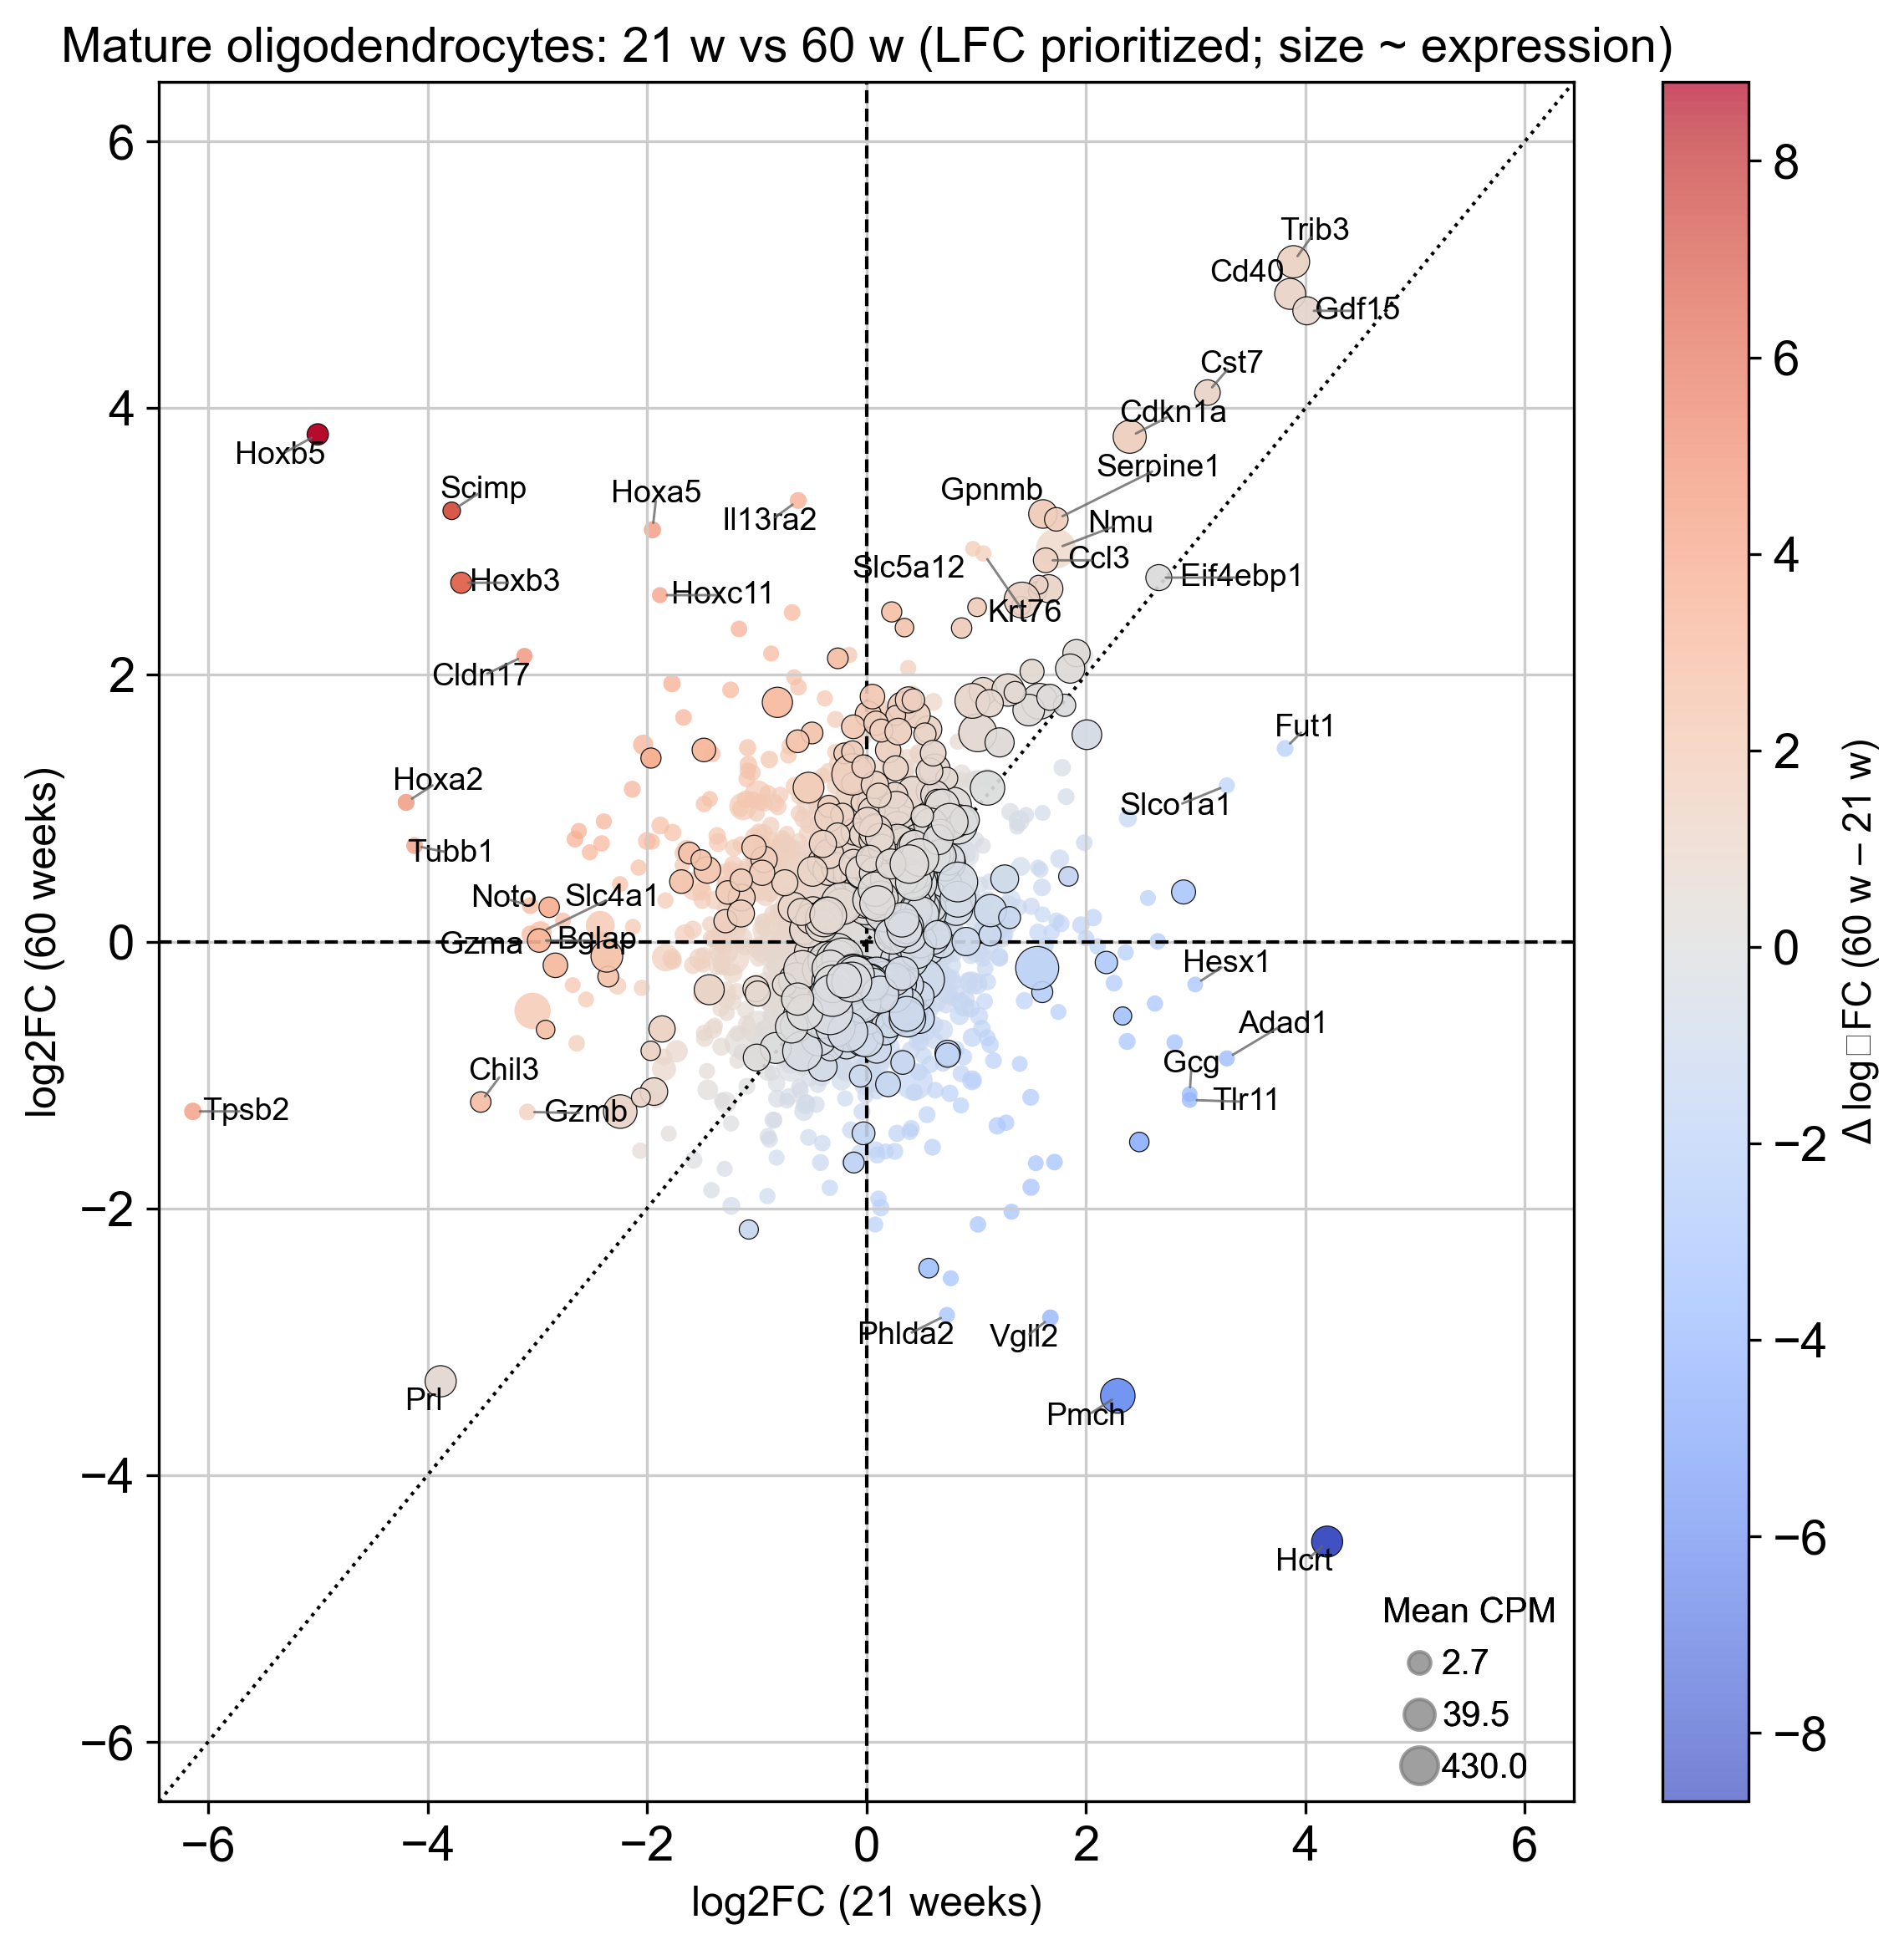

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Adad1,0.865,3.283,2.859,1.148,0.251,1.000,0.126,0.667,0.098,0.153,0.104,0.148
Bglap,35.597,-2.983,0.857,-3.480,0.001,0.214,3.014,1.000,4.563,1.465,4.126,1.902
Chil3,6.417,-3.515,1.578,-2.228,0.026,1.000,1.142,0.833,1.741,0.543,0.749,1.536
Cldn17,0.834,-3.117,2.890,-1.079,0.281,1.000,0.143,0.583,0.129,0.157,0.097,0.189
Cst7,16.769,3.107,0.893,3.478,0.001,0.214,5.556,1.000,0.664,10.447,2.045,9.066
Fut1,2.601,3.814,1.987,1.920,0.055,1.000,0.274,0.750,0.080,0.468,0.319,0.229
Gzma,4.837,-3.063,1.618,-1.893,0.058,1.000,0.545,0.917,0.750,0.339,0.568,0.521
Gzmb,1.775,-3.091,2.379,-1.299,0.194,1.000,0.277,0.750,0.427,0.127,0.210,0.345
Hcrt,256.264,4.198,1.338,3.138,0.002,0.435,27.753,1.000,25.255,30.251,30.723,24.783
Hesx1,0.711,2.995,3.450,0.868,0.385,1.000,0.077,0.500,0.037,0.117,0.085,0.069


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Ccl3,51.779,2.859,0.698,4.098,0.000,0.026,4.329,1.000,1.373,7.285,3.003,5.655
Cd40,333.356,4.856,1.523,3.190,0.001,0.142,27.080,1.000,2.230,51.930,17.500,36.660
Cdkn1a,628.630,3.785,1.186,3.192,0.001,0.142,52.241,1.000,10.018,94.465,36.529,67.953
Cst7,82.168,4.117,1.251,3.290,0.001,0.119,5.556,1.000,0.664,10.447,2.045,9.066
Eif4ebp1,72.988,2.729,0.933,2.927,0.003,0.217,6.264,1.000,1.588,10.941,4.632,7.897
Gdf15,107.994,4.730,1.450,3.263,0.001,0.128,11.420,1.000,1.050,21.789,11.603,11.236
Gpnmb,165.426,3.206,0.869,3.689,0.000,0.075,13.309,1.000,3.771,22.847,8.874,17.745
Hcrt,237.986,-4.498,0.909,-4.949,0.000,0.001,27.753,1.000,25.255,30.251,30.723,24.783
Hoxa5,1.873,3.087,2.271,1.359,0.174,1.000,0.352,0.667,0.420,0.285,0.510,0.195
Hoxb5,16.963,3.803,1.854,2.051,0.040,0.647,1.561,0.750,1.455,1.666,1.379,1.742


2025-10-09 11:04:33 | [INFO] maxp pruned
2025-10-09 11:04:33 | [INFO] LTSH dropped
2025-10-09 11:04:33 | [INFO] cmap pruned
2025-10-09 11:04:33 | [INFO] kern dropped
2025-10-09 11:04:33 | [INFO] post pruned
2025-10-09 11:04:33 | [INFO] PCLT dropped
2025-10-09 11:04:33 | [INFO] JSTF dropped
2025-10-09 11:04:33 | [INFO] DSIG dropped
2025-10-09 11:04:33 | [INFO] GPOS pruned
2025-10-09 11:04:33 | [INFO] GSUB pruned
2025-10-09 11:04:33 | [INFO] glyf pruned
2025-10-09 11:04:33 | [INFO] Missing glyphs for requested Unicodes: ['U+2082']
2025-10-09 11:04:33 | [INFO] Added gid0 to subset
2025-10-09 11:04:33 | [INFO] Added first four glyphs to subset
2025-10-09 11:04:33 | [INFO] Closing glyph list over 'GSUB': 65 glyphs before
2025-10-09 11:04:33 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'Delta', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'asciitilde', 'b', 'c', 'colon', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l',

💾 Saved: ../results/figures/Telencephalon_astrocytes_21w_vs_60w.{png, svg, pdf}


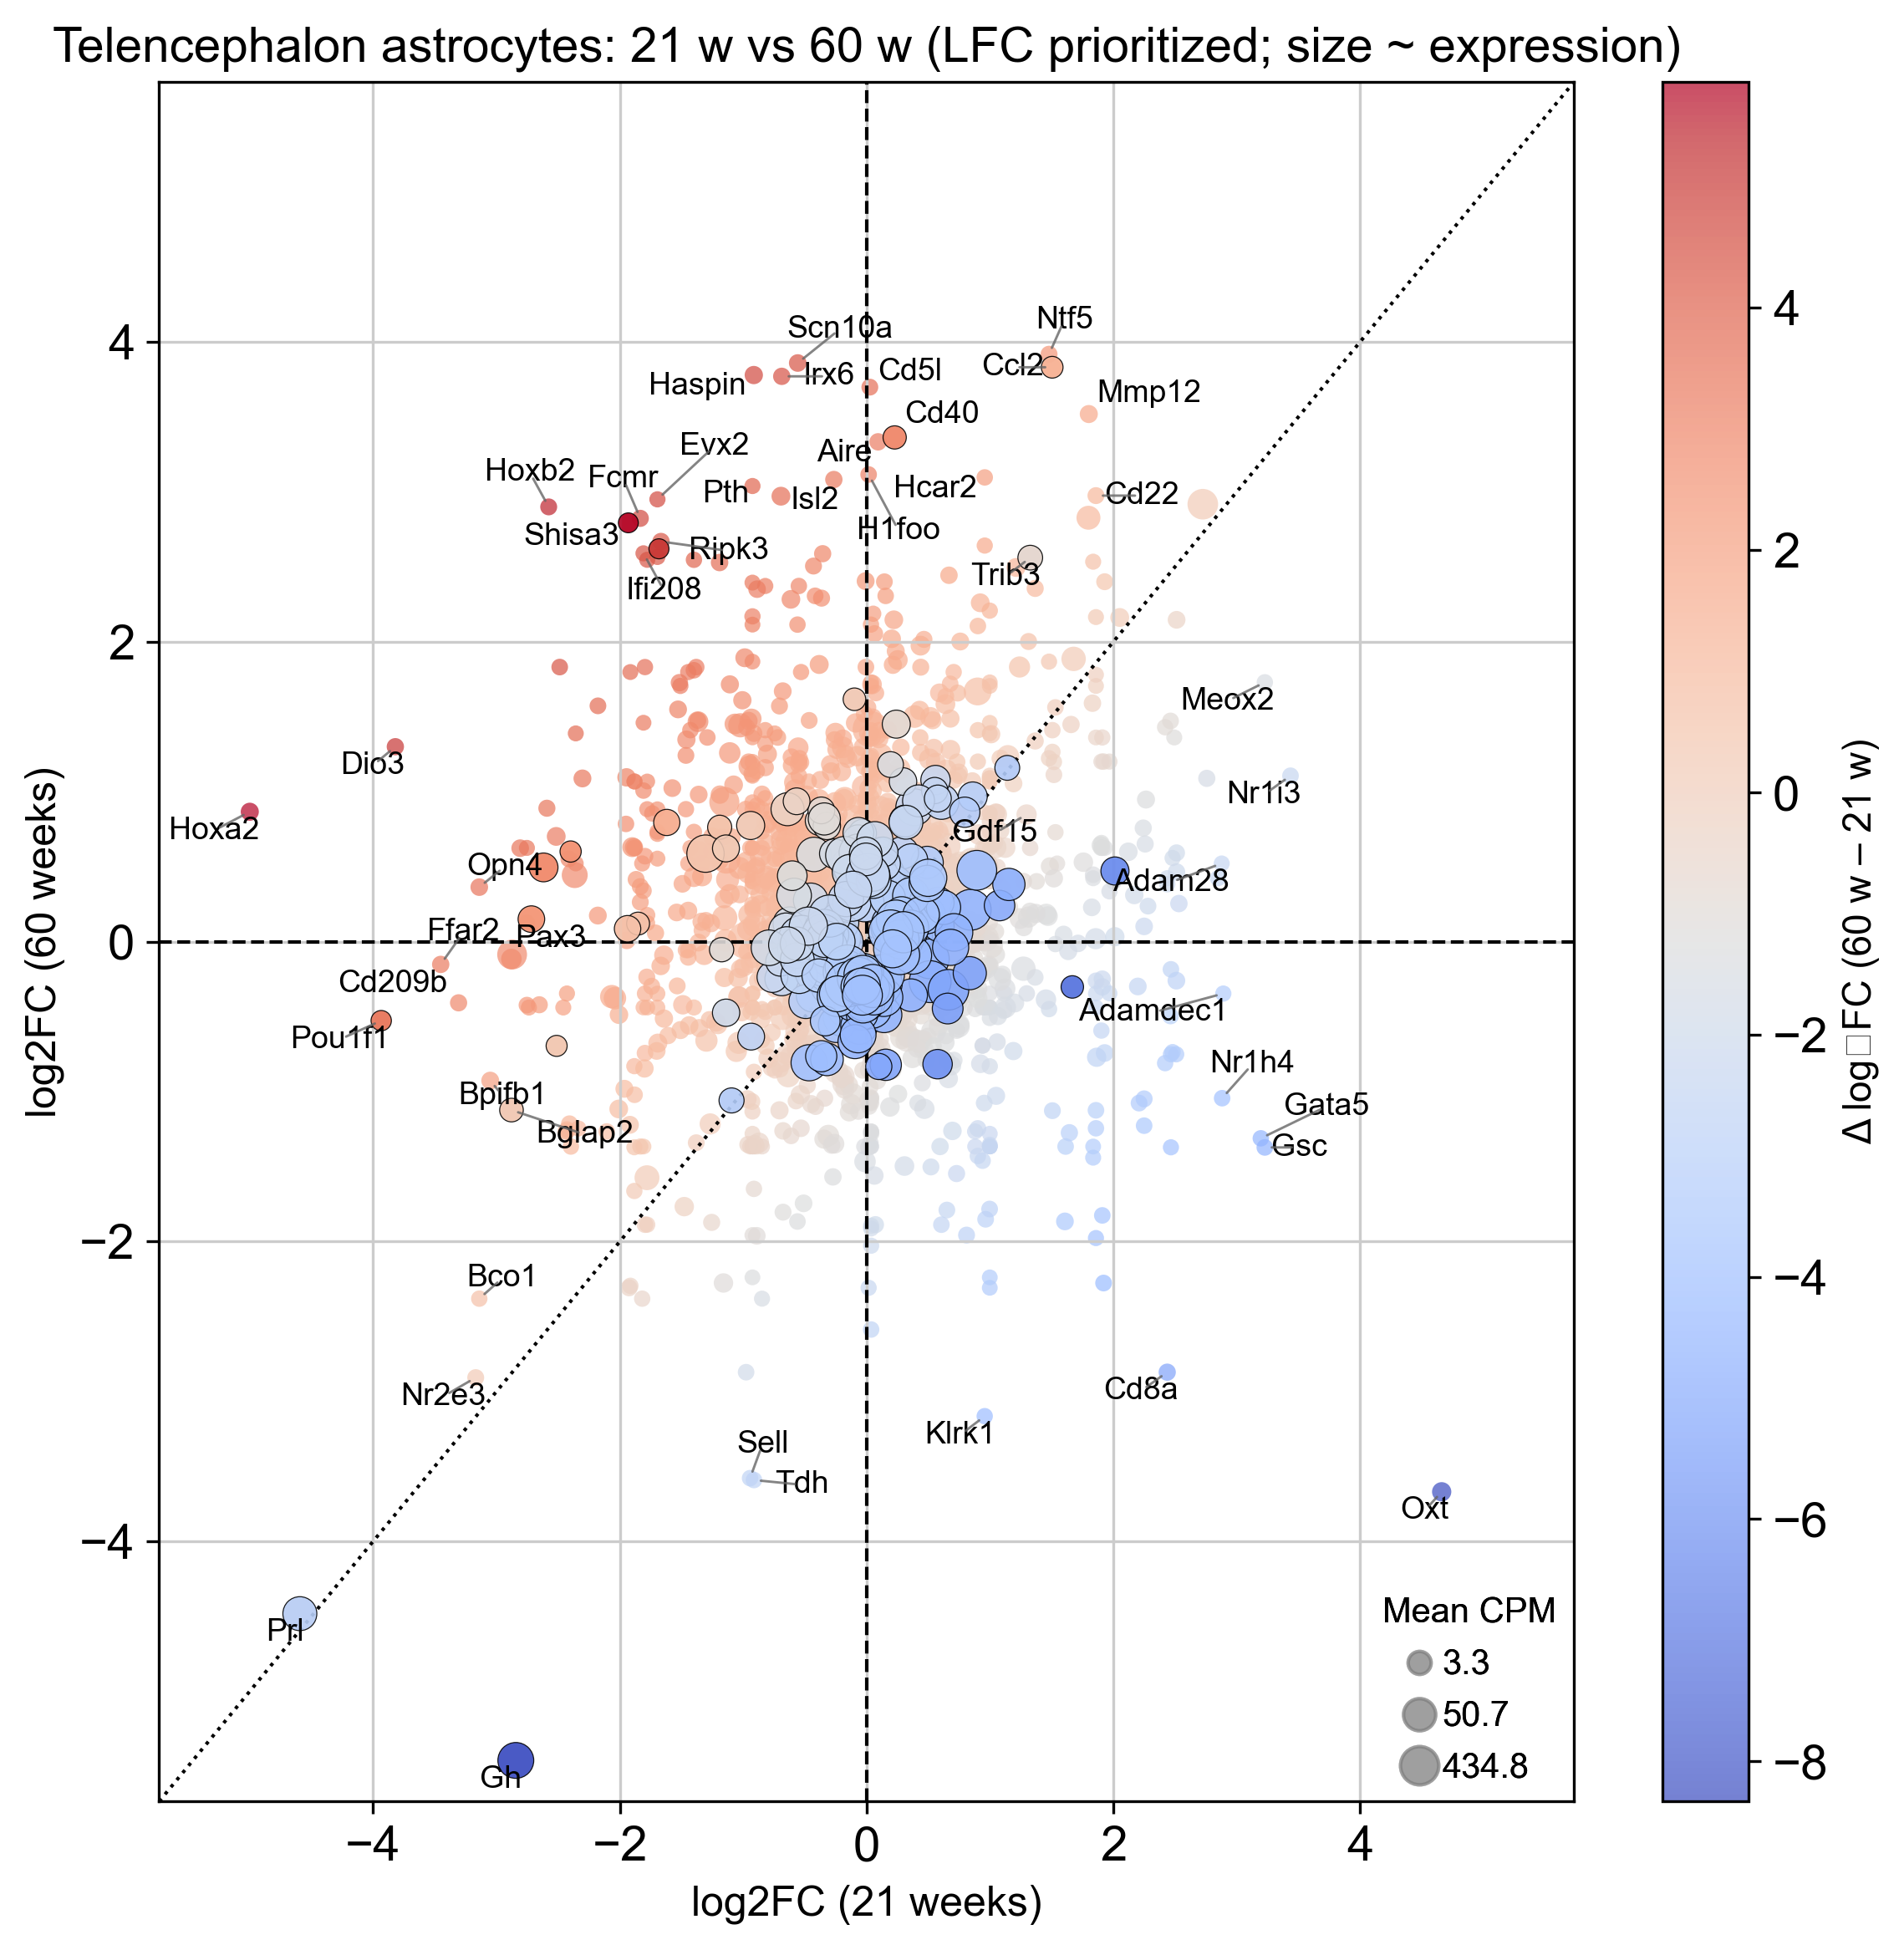

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Adam28,0.666,2.878,3.654,0.788,0.431,1.000,0.112,0.167,0.000,0.223,0.200,0.023
Adamdec1,0.672,2.891,2.926,0.988,0.323,1.000,0.150,0.417,0.053,0.247,0.204,0.097
Bco1,0.819,-3.140,2.778,-1.130,0.258,1.000,0.176,0.333,0.352,0.000,0.246,0.106
Bglap2,14.027,-2.878,0.737,-3.906,0.000,0.083,2.844,1.000,4.721,0.967,4.216,1.472
Bpifb1,1.646,-3.051,2.453,-1.244,0.214,1.000,0.510,0.667,0.786,0.233,0.493,0.527
Cd209b,0.911,-3.307,3.008,-1.099,0.272,1.000,0.347,0.667,0.509,0.185,0.273,0.421
Dio3,1.314,-3.820,2.498,-1.529,0.126,1.000,0.368,0.667,0.492,0.245,0.395,0.342
Ffar2,1.025,-3.452,2.706,-1.276,0.202,1.000,0.380,0.750,0.554,0.206,0.309,0.450
Gata5,0.828,3.195,2.800,1.141,0.254,1.000,0.184,0.417,0.095,0.273,0.251,0.118
Gsc,0.851,3.228,2.759,1.170,0.242,1.000,0.229,0.500,0.153,0.304,0.259,0.199


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Aire,1.086,3.334,2.533,1.316,0.188,1.000,0.393,0.667,0.243,0.542,0.514,0.272
Ccl2,6.035,3.831,1.265,3.029,0.002,0.445,1.604,0.833,0.533,2.674,1.684,1.524
Cd22,1.880,2.975,1.938,1.535,0.125,1.000,0.288,0.500,0.053,0.523,0.099,0.477
Cd40,13.087,3.363,0.957,3.515,0.000,0.172,2.541,1.000,1.087,3.994,1.759,3.322
Cd5l,1.372,3.698,2.407,1.536,0.124,1.000,0.268,0.500,0.095,0.442,0.192,0.345
Gh,17.337,-5.461,1.707,-3.200,0.001,0.327,100.734,0.917,177.116,24.353,197.095,4.374
H1foo,0.906,3.116,2.619,1.190,0.234,1.000,0.215,0.500,0.101,0.330,0.204,0.226
Haspin,1.467,3.779,2.392,1.580,0.114,1.000,0.630,0.667,0.576,0.685,0.891,0.370
Hcar2,0.921,3.096,2.638,1.174,0.240,1.000,0.191,0.500,0.044,0.338,0.150,0.233
Irx6,1.456,3.770,2.382,1.583,0.113,1.000,0.381,0.750,0.243,0.519,0.397,0.366


2025-10-09 11:04:35 | [INFO] maxp pruned
2025-10-09 11:04:35 | [INFO] LTSH dropped
2025-10-09 11:04:35 | [INFO] cmap pruned
2025-10-09 11:04:35 | [INFO] kern dropped
2025-10-09 11:04:35 | [INFO] post pruned
2025-10-09 11:04:35 | [INFO] PCLT dropped
2025-10-09 11:04:35 | [INFO] JSTF dropped
2025-10-09 11:04:35 | [INFO] DSIG dropped
2025-10-09 11:04:35 | [INFO] GPOS pruned
2025-10-09 11:04:35 | [INFO] GSUB pruned
2025-10-09 11:04:35 | [INFO] glyf pruned
2025-10-09 11:04:35 | [INFO] Missing glyphs for requested Unicodes: ['U+2082']
2025-10-09 11:04:35 | [INFO] Added gid0 to subset
2025-10-09 11:04:35 | [INFO] Added first four glyphs to subset
2025-10-09 11:04:35 | [INFO] Closing glyph list over 'GSUB': 65 glyphs before
2025-10-09 11:04:35 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'Delta', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'O', 'P', 'R', 'S', 'T', 'W', 'a', 'asciitilde', 'b', 'c', 'colon', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i',

💾 Saved: ../results/figures/Microglia_21w_vs_60w.{png, svg, pdf}


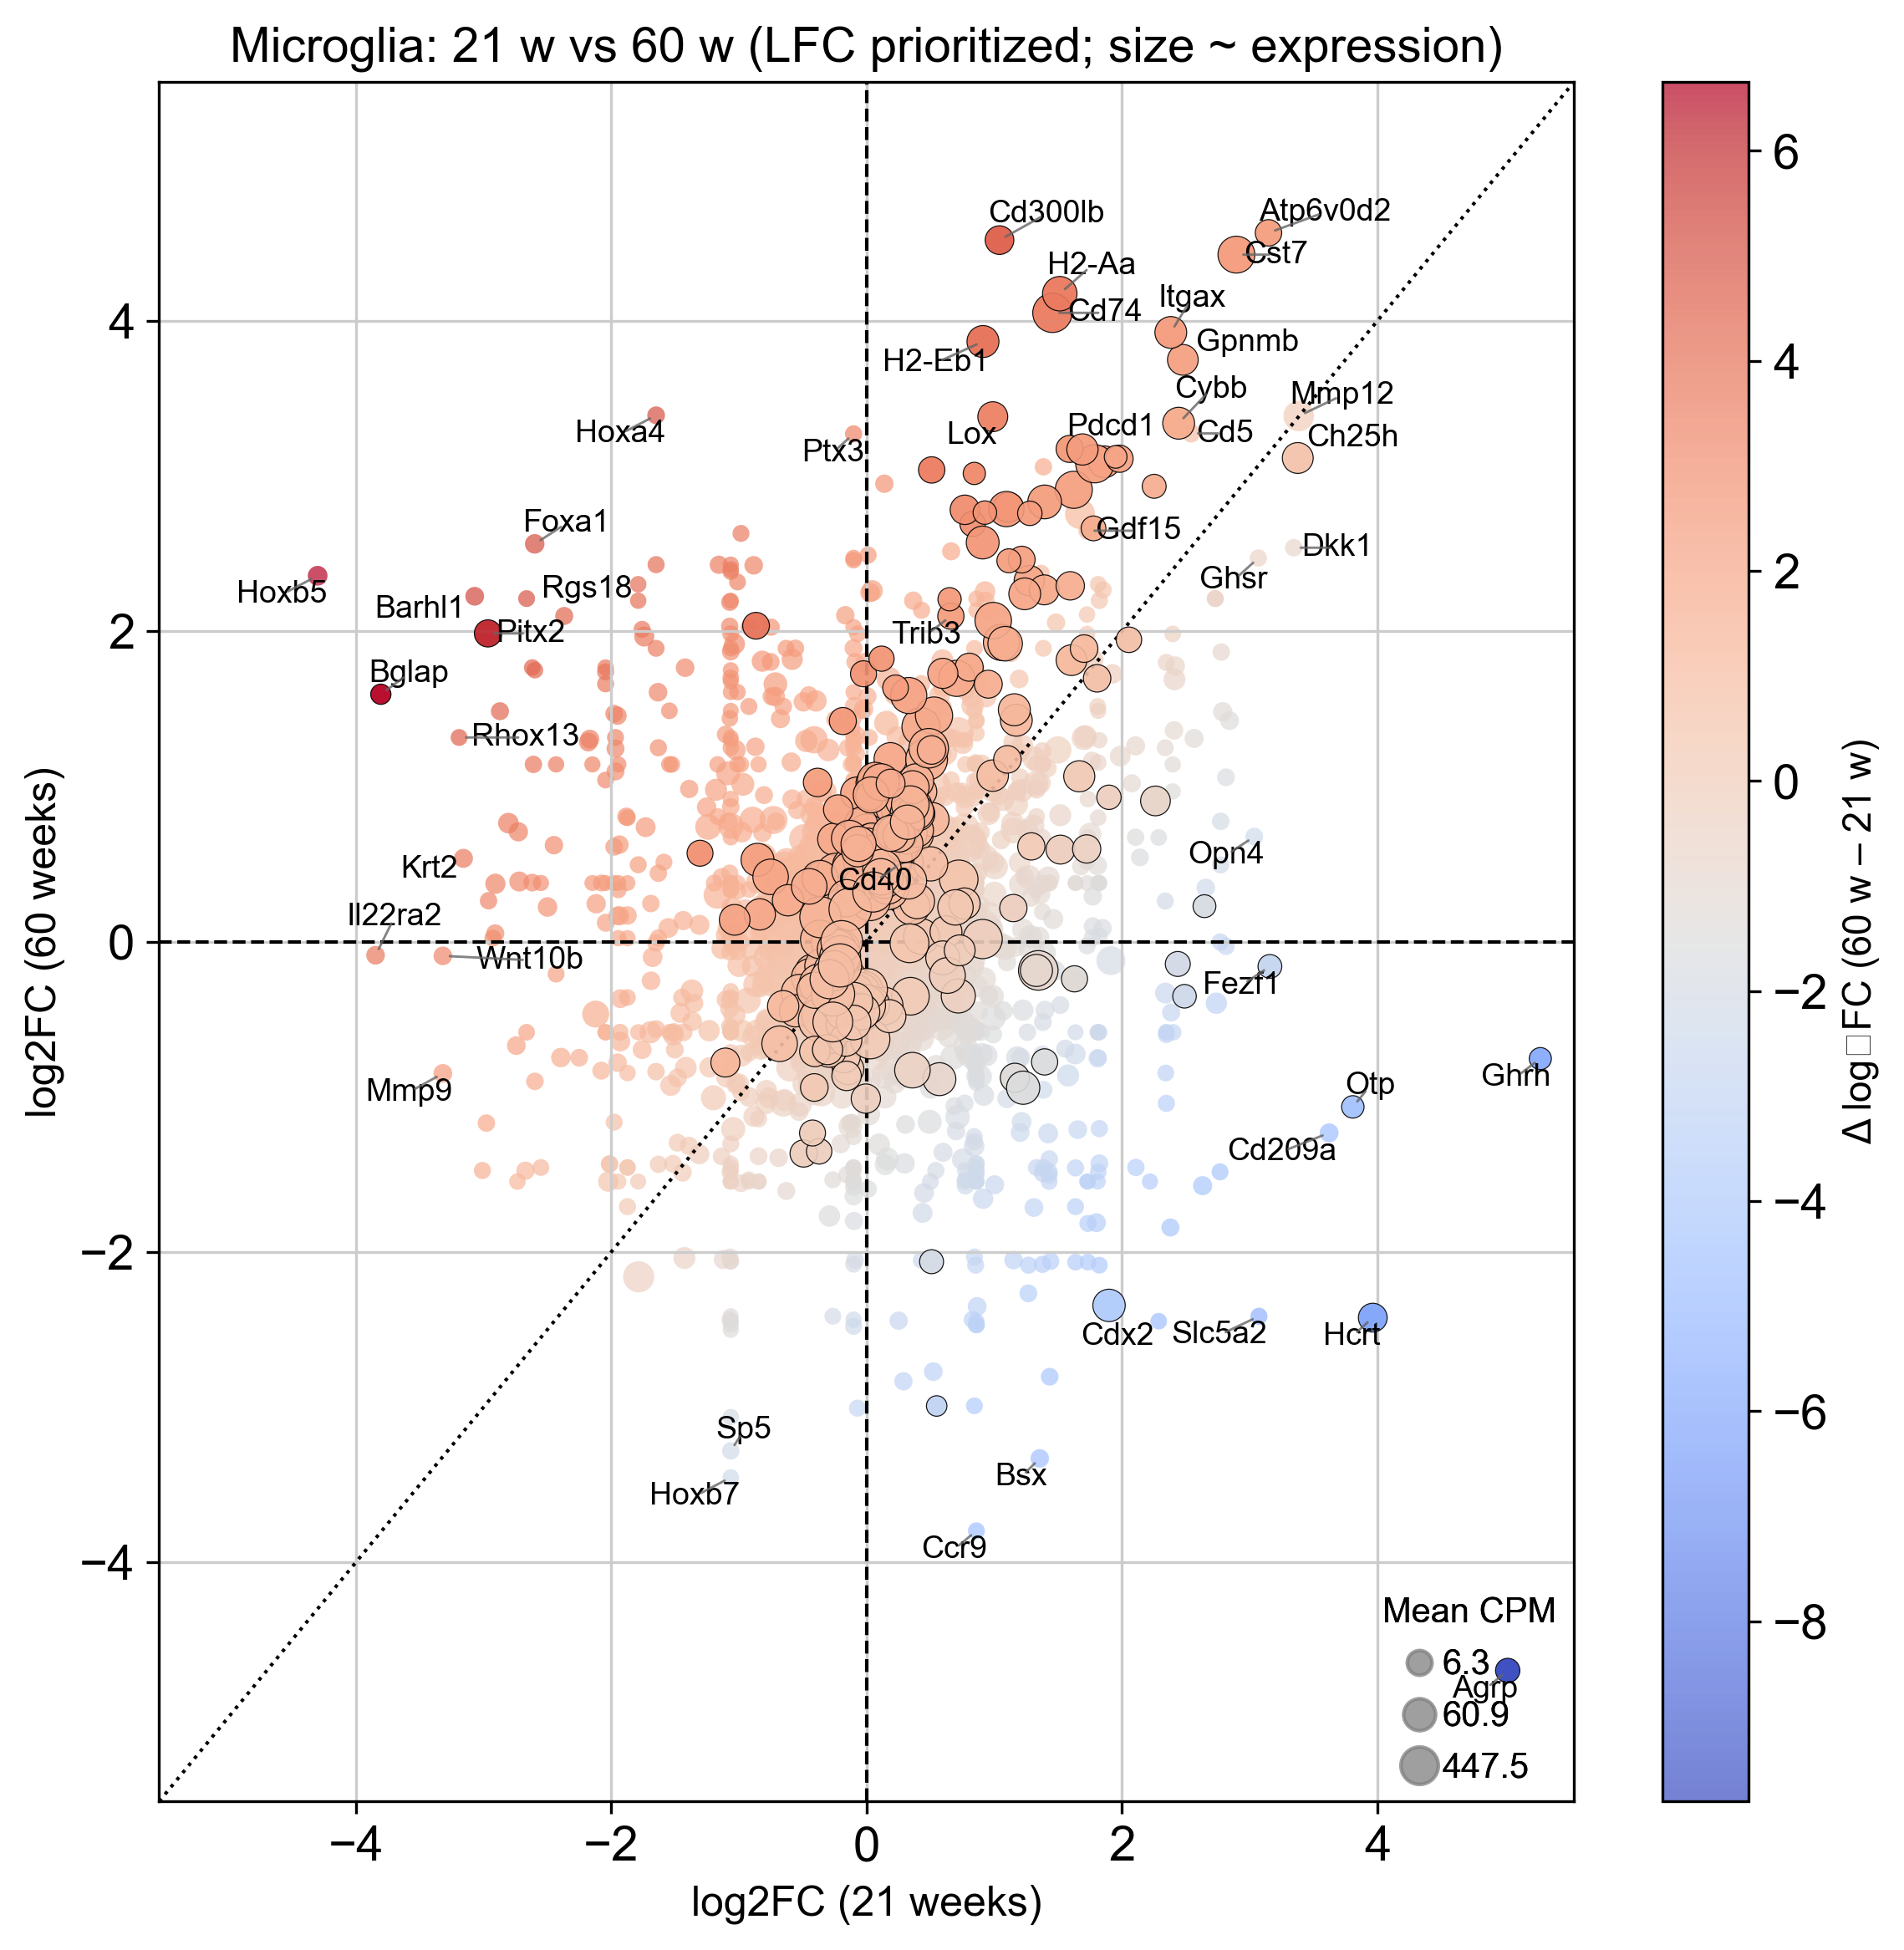

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agrp,6.164,5.020,3.164,1.586,0.113,1.000,3.992,0.583,3.708,4.277,4.269,3.715
Atp6v0d2,5.047,3.147,1.306,2.411,0.016,1.000,7.235,0.833,0.796,13.674,3.478,10.993
Barhl1,1.641,-3.069,1.968,-1.559,0.119,1.000,0.902,0.583,1.103,0.700,1.112,0.692
Bglap,2.582,-3.804,1.768,-2.152,0.031,1.000,1.114,0.583,1.745,0.484,1.752,0.477
Cd209a,1.179,3.622,2.706,1.339,0.181,1.000,0.964,0.583,0.796,1.131,0.819,1.109
Ch25h,16.060,3.376,1.585,2.130,0.033,1.000,26.316,1.000,5.315,47.317,11.020,41.613
Dkk1,0.968,3.345,2.633,1.271,0.204,1.000,0.512,0.417,0.000,1.025,0.670,0.355
Fezf1,6.563,3.158,1.078,2.930,0.003,0.846,3.408,0.917,1.637,5.179,4.537,2.279
Ghrh,3.683,5.275,2.225,2.371,0.018,1.000,2.066,0.667,0.988,3.143,2.546,1.585
Ghsr,0.796,3.068,2.737,1.121,0.262,1.000,0.445,0.500,0.000,0.890,0.551,0.339


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agrp,6.716,-4.696,1.287,-3.649,0.000,0.221,3.992,0.583,3.708,4.277,4.269,3.715
Atp6v0d2,20.166,4.567,1.706,2.676,0.007,0.530,7.235,0.833,0.796,13.674,3.478,10.993
Bsx,1.580,-3.330,2.177,-1.530,0.126,0.999,0.822,0.500,1.025,0.619,0.767,0.877
Ccr9,1.049,-3.796,2.803,-1.355,0.176,0.999,0.348,0.250,0.580,0.116,0.116,0.580
Cd300lb,39.474,4.520,1.487,3.039,0.002,0.307,13.758,0.917,2.847,24.670,5.999,21.517
Cd5,1.112,3.275,2.798,1.170,0.242,0.999,0.739,0.417,0.136,1.342,0.872,0.606
Cd74,1206.373,4.051,1.160,3.492,0.000,0.242,448.250,1.000,100.903,795.596,238.628,657.871
Cst7,510.649,4.426,1.254,3.530,0.000,0.239,185.679,1.000,23.343,348.015,92.955,278.404
Cybb,101.533,3.340,1.395,2.394,0.017,0.798,35.608,1.000,7.462,63.755,15.835,55.382
Gpnmb,61.976,3.749,1.210,3.099,0.002,0.306,25.140,1.000,4.837,45.442,16.475,33.805


2025-10-09 11:04:37 | [INFO] maxp pruned
2025-10-09 11:04:37 | [INFO] LTSH dropped
2025-10-09 11:04:37 | [INFO] cmap pruned
2025-10-09 11:04:37 | [INFO] kern dropped
2025-10-09 11:04:37 | [INFO] post pruned
2025-10-09 11:04:37 | [INFO] PCLT dropped
2025-10-09 11:04:37 | [INFO] JSTF dropped
2025-10-09 11:04:37 | [INFO] DSIG dropped
2025-10-09 11:04:37 | [INFO] GPOS pruned
2025-10-09 11:04:37 | [INFO] GSUB pruned
2025-10-09 11:04:37 | [INFO] glyf pruned
2025-10-09 11:04:37 | [INFO] Missing glyphs for requested Unicodes: ['U+2082']
2025-10-09 11:04:37 | [INFO] Added gid0 to subset
2025-10-09 11:04:37 | [INFO] Added first four glyphs to subset
2025-10-09 11:04:37 | [INFO] Closing glyph list over 'GSUB': 62 glyphs before
2025-10-09 11:04:37 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'Delta', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'O', 'P', 'S', 'T', 'a', 'asciitilde', 'b', 'c', 'colon', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l', 'm', 'minus', 

💾 Saved: ../results/figures/Oligodendrocytes_precursor_cells_21w_vs_60w.{png, svg, pdf}


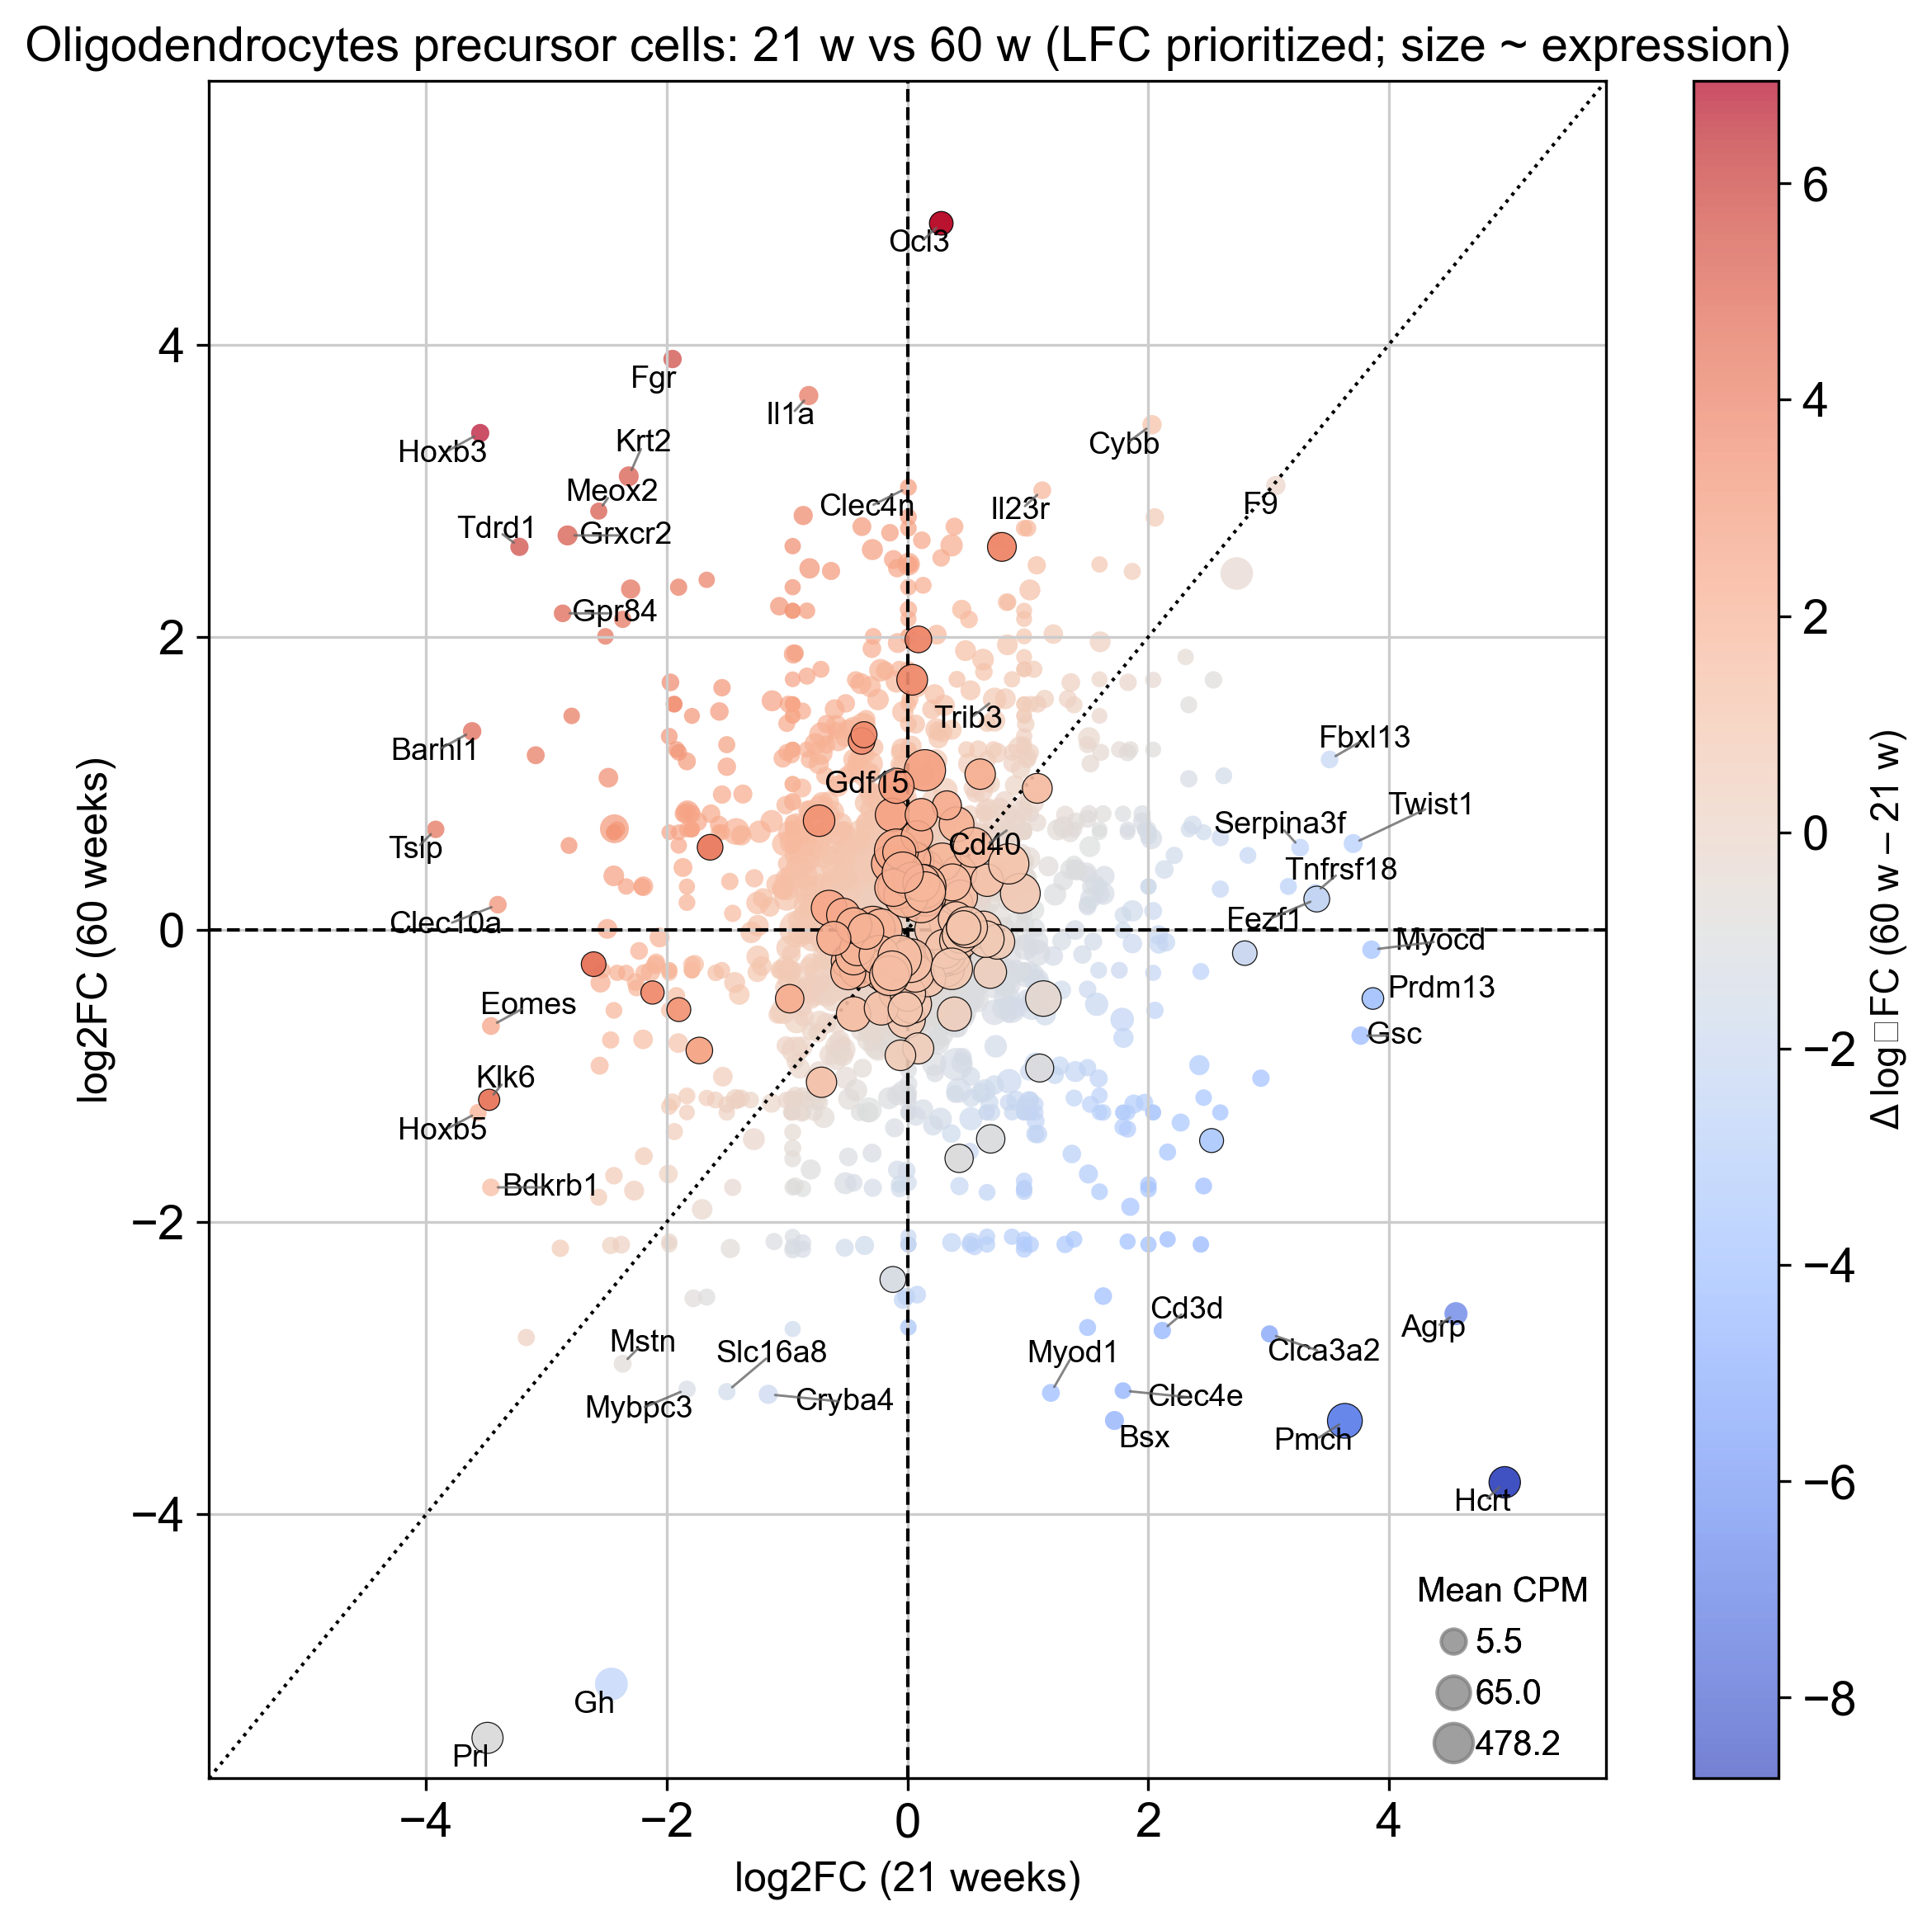

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agrp,8.023,4.559,2.495,1.827,0.068,1.000,3.414,0.667,1.700,5.128,5.141,1.686
Barhl1,1.125,-3.618,2.610,-1.386,0.166,1.000,0.780,0.500,0.949,0.610,0.714,0.845
Bdkrb1,1.019,-3.462,2.592,-1.335,0.182,1.000,0.559,0.583,0.999,0.120,0.652,0.466
Clec10a,0.970,-3.404,2.588,-1.315,0.188,1.000,0.547,0.500,0.844,0.250,0.618,0.476
Eomes,1.019,-3.462,2.592,-1.335,0.182,1.000,0.601,0.500,1.009,0.194,0.652,0.550
Fbxl13,1.053,3.509,2.583,1.359,0.174,1.000,0.538,0.500,0.122,0.955,0.677,0.399
Fezf1,11.172,3.402,0.822,4.138,0.000,0.029,5.232,0.917,2.182,8.281,7.121,3.343
Gsc,1.268,3.767,2.483,1.517,0.129,1.000,0.772,0.667,0.458,1.085,0.808,0.735
Hcrt,26.136,4.964,0.844,5.884,0.000,0.000,24.060,1.000,29.827,18.292,16.643,31.476
Hoxb3,1.096,-3.551,2.672,-1.329,0.184,1.000,0.695,0.333,0.697,0.694,0.697,0.694


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Bsx,1.833,-3.358,1.864,-1.801,0.072,1.0,0.977,0.583,1.223,0.731,0.806,1.148
Ccl3,5.882,4.831,1.616,2.990,0.003,1.0,2.950,0.833,1.113,4.786,2.196,3.704
Clec4e,0.740,-3.154,2.854,-1.105,0.269,1.0,0.334,0.333,0.466,0.202,0.202,0.466
Clec4n,0.850,3.025,2.679,1.129,0.259,1.0,0.364,0.417,0.111,0.616,0.196,0.532
Cryba4,1.660,-3.179,1.900,-1.673,0.094,1.0,1.078,0.750,1.679,0.478,1.113,1.044
Cybb,2.411,3.454,1.807,1.911,0.056,1.0,1.057,0.583,0.239,1.876,0.597,1.518
F9,1.812,3.038,1.842,1.649,0.099,1.0,1.095,0.583,0.224,1.965,1.059,1.130
Fgr,1.496,3.903,2.382,1.638,0.101,1.0,0.753,0.500,0.451,1.056,0.573,0.934
Gh,5.859,-5.161,2.682,-1.924,0.054,1.0,59.116,0.750,100.512,17.719,114.537,3.694
Hcrt,49.937,-3.781,1.289,-2.933,0.003,1.0,24.060,1.000,29.827,18.292,16.643,31.476


2025-10-09 11:04:39 | [INFO] maxp pruned
2025-10-09 11:04:39 | [INFO] LTSH dropped
2025-10-09 11:04:39 | [INFO] cmap pruned
2025-10-09 11:04:39 | [INFO] kern dropped
2025-10-09 11:04:39 | [INFO] post pruned
2025-10-09 11:04:39 | [INFO] PCLT dropped
2025-10-09 11:04:39 | [INFO] JSTF dropped
2025-10-09 11:04:39 | [INFO] DSIG dropped
2025-10-09 11:04:39 | [INFO] GPOS pruned
2025-10-09 11:04:39 | [INFO] GSUB pruned
2025-10-09 11:04:39 | [INFO] glyf pruned
2025-10-09 11:04:39 | [INFO] Missing glyphs for requested Unicodes: ['U+2082']
2025-10-09 11:04:39 | [INFO] Added gid0 to subset
2025-10-09 11:04:39 | [INFO] Added first four glyphs to subset
2025-10-09 11:04:39 | [INFO] Closing glyph list over 'GSUB': 62 glyphs before
2025-10-09 11:04:39 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'Delta', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'O', 'P', 'S', 'T', 'a', 'asciitilde', 'b', 'c', 'colon', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l', 'm', 'minus', 

💾 Saved: ../results/figures/Olfactory_astrocytes_21w_vs_60w.{png, svg, pdf}


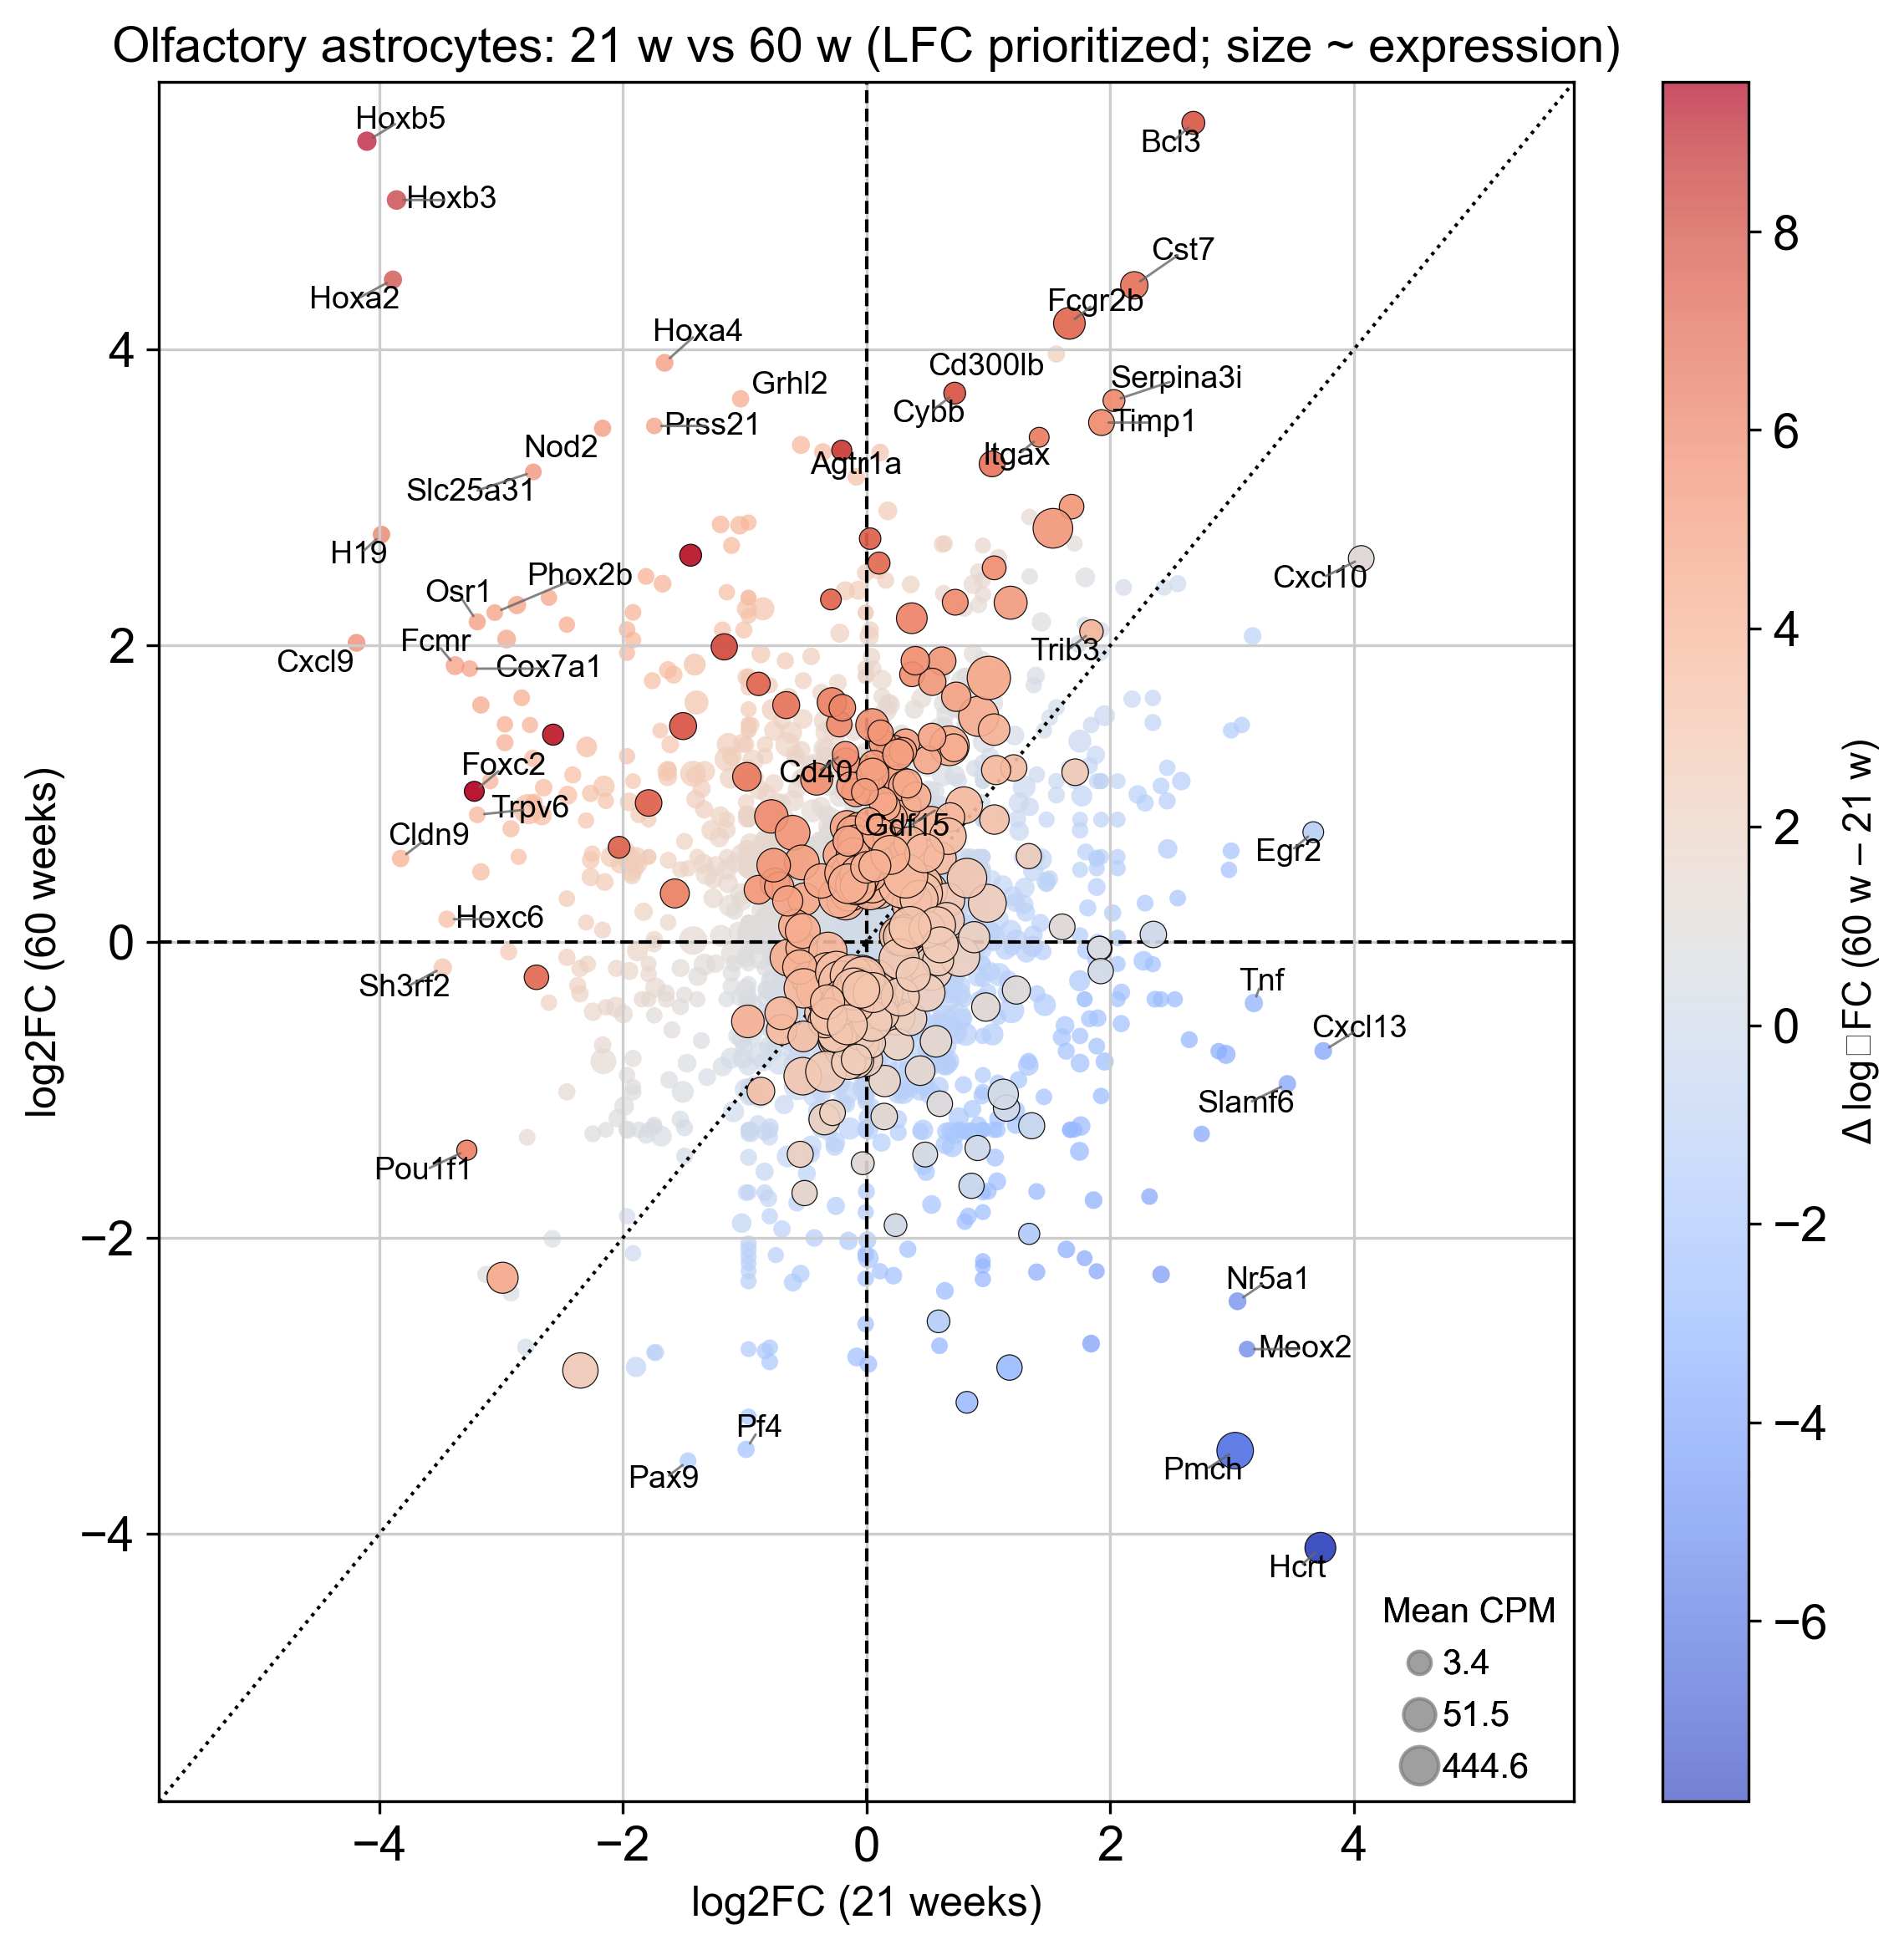

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Cldn9,1.290,-3.825,2.585,-1.480,0.139,1.0,0.431,0.583,0.688,0.173,0.571,0.290
Cox7a1,0.884,-3.257,2.981,-1.093,0.274,1.0,0.255,0.250,0.389,0.121,0.389,0.121
Cxcl10,17.037,4.060,2.340,1.735,0.083,1.0,5.405,0.750,0.896,9.914,7.455,3.355
Cxcl13,1.223,3.748,2.748,1.364,0.173,1.0,0.510,0.667,0.303,0.717,0.534,0.487
Cxcl9,1.668,-4.187,2.675,-1.565,0.118,1.0,0.528,0.417,0.797,0.259,0.739,0.317
Egr2,2.423,3.666,1.845,1.987,0.047,1.0,1.190,0.833,0.560,1.820,1.062,1.317
Fcmr,2.101,-3.378,1.941,-1.740,0.082,1.0,0.870,0.750,1.007,0.734,0.913,0.828
Foxc2,3.375,-3.220,1.559,-2.065,0.039,1.0,0.907,0.750,1.445,0.368,1.461,0.353
H19,1.478,-3.982,2.507,-1.588,0.112,1.0,0.434,0.500,0.640,0.229,0.640,0.229
Hcrt,48.283,3.725,1.296,2.873,0.004,1.0,23.187,1.000,25.311,21.063,21.050,25.324


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agtr1a,1.010,3.354,2.933,1.143,0.253,NaN,0.601,0.667,0.523,0.679,0.875,0.327
Bcl3,9.581,5.530,1.624,3.406,0.001,0.113,2.397,0.750,0.308,4.487,1.721,3.074
Cd300lb,1.648,3.968,2.764,1.436,0.151,NaN,0.416,0.417,0.070,0.763,0.305,0.527
Cst7,45.997,4.433,1.344,3.297,0.001,0.120,8.600,0.833,1.107,16.092,2.393,14.807
Cybb,7.901,3.705,1.256,2.950,0.003,0.232,1.723,0.750,0.512,2.934,0.906,2.539
Fcgr2b,134.087,4.176,1.151,3.628,0.000,0.078,29.520,1.000,6.085,52.955,15.835,43.205
Grhl2,1.273,3.666,2.560,1.432,0.152,NaN,0.412,0.667,0.283,0.542,0.416,0.409
Hcrt,77.980,-4.094,0.554,-7.389,0.000,0.000,23.187,1.000,25.311,21.063,21.050,25.324
Hoxa2,2.329,4.471,2.744,1.629,0.103,NaN,0.668,0.333,0.598,0.738,0.598,0.738
Hoxa4,1.575,3.909,3.214,1.216,0.224,NaN,0.539,0.333,0.447,0.632,0.580,0.498


In [347]:
# === Main loop ===
forced = ['Trib3', 'Cd40', 'Gdf15']

for cell, pack in results.items():
    se = pack.get("simple_effects", {})
    if "21" not in se or "60" not in se or se["21"] is None or se["60"] is None:
        print(f"Skipping {cell}: missing 21/60 results.")
        continue

    res21 = se["21"]
    res60 = se["60"]

    gstats = pack.get("gene_stats", None)
    expr_series = gstats["mean_cpm_all"] if (gstats is not None and "mean_cpm_all" in gstats.columns) else None

    picks, top21, top60 = pick_top_per_age(
        res21, res60,
        lfc_col='log2FC_mtDSB_vs_control',
        padj_col='pvalue_mtDSB_vs_control',
        q=0.25, top_n_each=20,
        alpha_lfc=1.0, beta_p=0.0,
        force_lfc_min=0.0, max_labels=100
    )
    labels = list(dict.fromkeys(list(picks) + forced))

    safe_name = cell.replace(" ", "_").replace("/", "_")
    save_base = os.path.join(outdir, f"{safe_name}_21w_vs_60w")

    _ = compare_lfc_scatter_colored_labels(
        res21, res60,
        highlight_genes=labels,
        expr=expr_series,
        title=f"{cell}: 21 w vs 60 w (LFC prioritized; size ~ expression)",
        save_base=save_base
    )

    _display_top_table(res21, top21, cell, "21 w")
    _display_top_table(res60, top60, cell, "60 w")

In [355]:
# Define genes of interest in mature oligodendrocytes
goi = ["Hoxb5","Hoxa5","Hoxb3","Hoxa2","Hoxc11","Il13ra2",
       "Mbp","Mog","Myrf","Sox10","Serpina3n","Cst7","Gdf15","Trib3"]

ct = "Mature oligodendrocytes"
res21 = results[ct]["simple_effects"]["21"]
res60 = results[ct]["simple_effects"]["60"]
gstats = results[ct].get("gene_stats")

# Columns (adjust if you used padj_ instead of pvalue_)
lfc = "log2FC_mtDSB_vs_control"
p   = "pvalue_mtDSB_vs_control"  # or "padj_mtDSB_vs_control"

# Build comparison table
common = res21.index.intersection(res60.index).intersection(goi)
tab = (res21.loc[common, [lfc, p]].rename(columns={lfc:"lfc_21", p:"p_21"})
       .join(res60.loc[common, [lfc, p]].rename(columns={lfc:"lfc_60", p:"p_60"})))
tab["deltaLFC"] = tab["lfc_60"] - tab["lfc_21"]

# Add mean expression if available
if gstats is not None and "mean_cpm_all" in gstats.columns:
    tab = tab.join(gstats["mean_cpm_all"])

# Pretty view: HOX/Il13ra2 at top
order = ["Hoxb5","Hoxa5","Hoxb3","Hoxa2","Hoxc11","Il13ra2"]
tab = tab.loc[order + [g for g in tab.index if g not in order]].round(3)
display(tab)

,lfc_21,p_21,lfc_60,p_60,deltaLFC,mean_cpm_all
Hoxb5,-5.000,0.002,3.803,0.040,8.804,1.561
Hoxa5,-1.951,0.222,3.087,0.174,5.038,0.352
Hoxb3,-3.693,0.001,2.691,0.020,6.383,1.422
Hoxa2,-4.195,0.059,1.044,0.565,5.239,0.337
Hoxc11,-1.883,0.474,2.598,0.212,4.480,0.125
Il13ra2,-0.623,0.671,3.308,0.078,3.930,0.304
Cst7,3.107,0.001,4.117,0.001,1.009,5.556
Gdf15,4.013,NaN,4.730,0.001,0.717,11.420
Mbp,-0.199,0.248,-0.156,0.458,0.043,27310.448
Mog,-0.371,0.114,-0.555,0.055,-0.184,4407.020


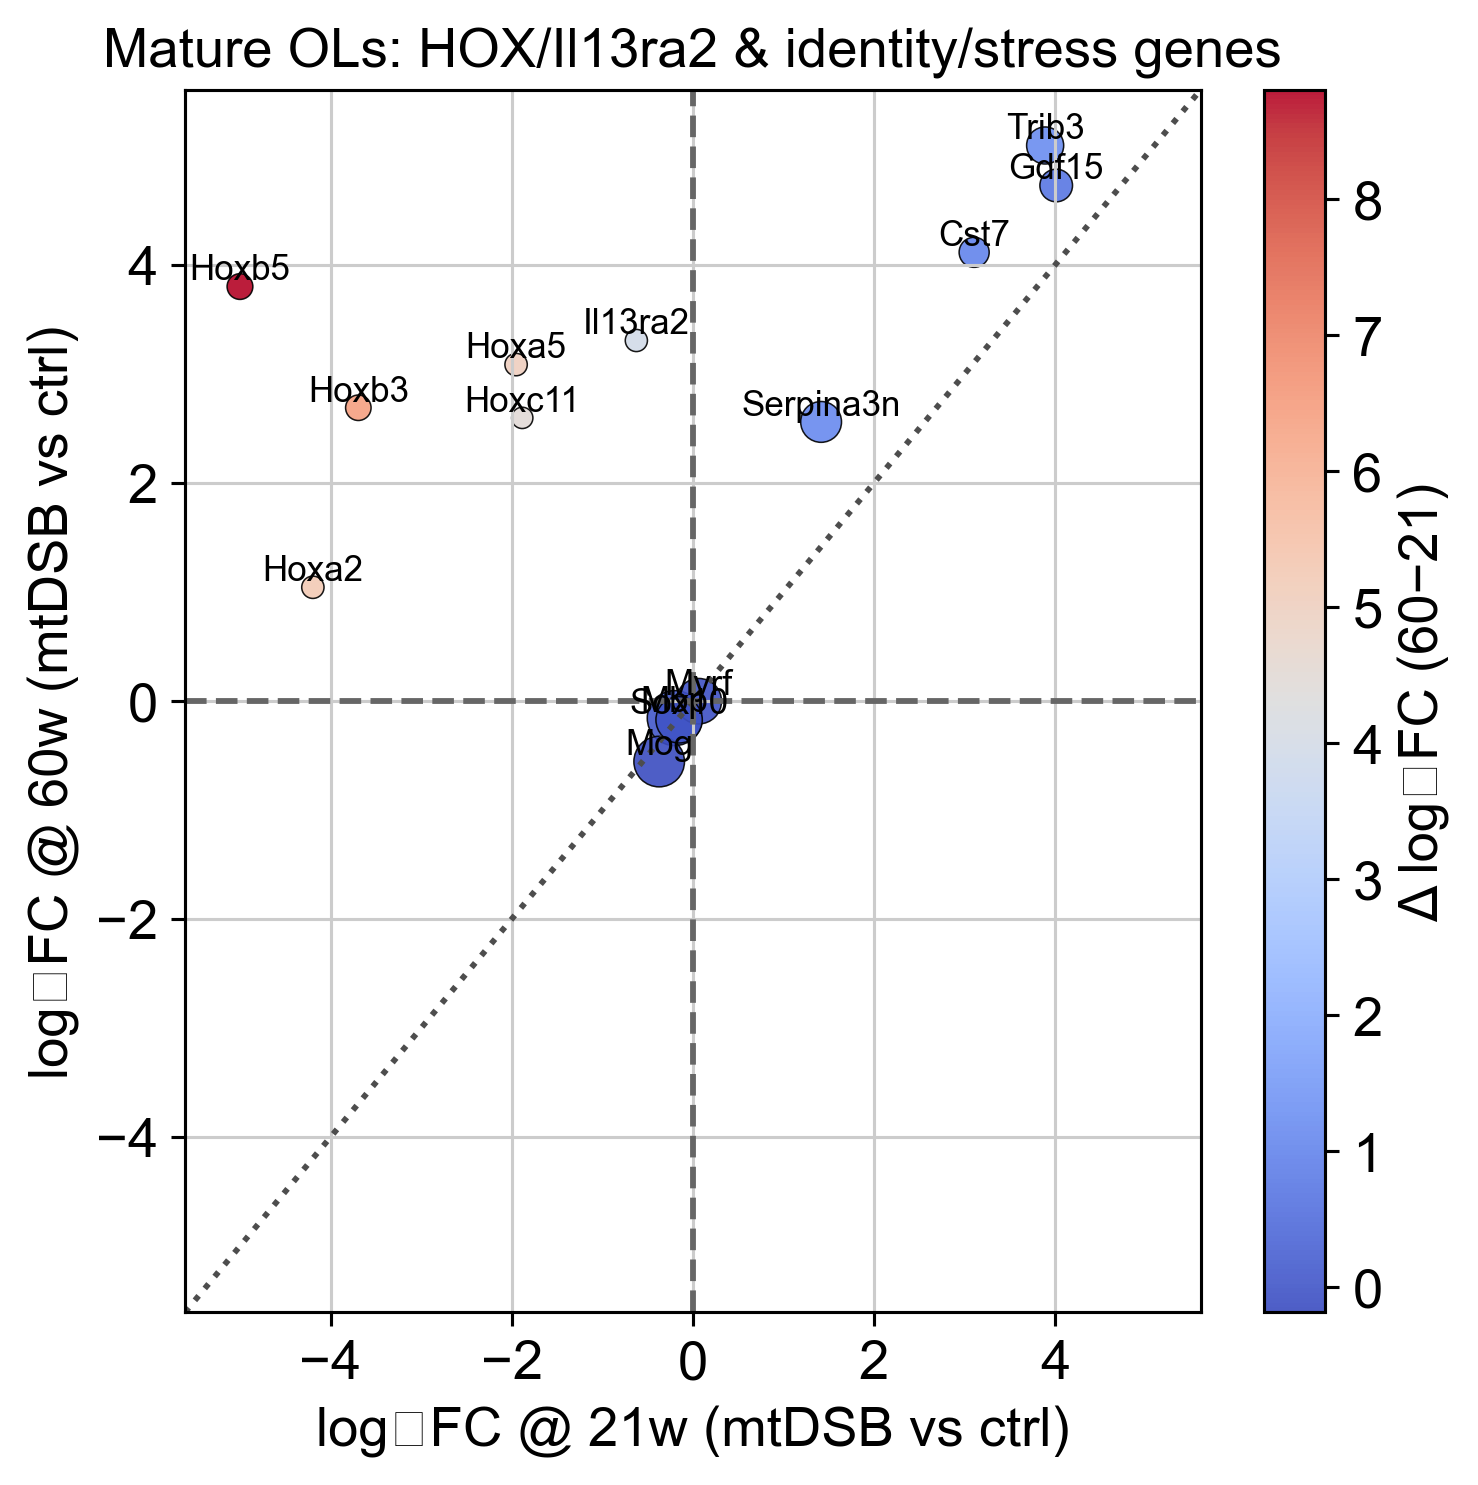

In [356]:
import matplotlib.pyplot as plt
import numpy as np

df = tab.copy()
sizes = 80
if "mean_cpm_all" in df.columns:
    v = np.log1p(df["mean_cpm_all"].fillna(0))
    sizes = 30 + ( (v - v.min()) / max(1e-6, (v.max()-v.min())) ) * 170

plt.figure(figsize=(5.5,5.5), dpi=140)
sc = plt.scatter(df["lfc_21"], df["lfc_60"],
                 c=df["deltaLFC"], cmap="coolwarm",
                 s=sizes, edgecolor="k", linewidth=0.4, alpha=0.9)
for g in df.index:
    plt.text(df.at[g,"lfc_21"], df.at[g,"lfc_60"], g, fontsize=9,
             ha="center", va="bottom")

lim = float(np.nanmax(np.abs(df[["lfc_21","lfc_60"]])))*1.1 if len(df) else 1.0
plt.plot([-lim,lim],[-lim,lim], ls=":", c="0.3")
plt.axhline(0, ls="--", c="0.4"); plt.axvline(0, ls="--", c="0.4")
plt.xlim(-lim, lim); plt.ylim(-lim, lim)
plt.xlabel("log₂FC @ 21w (mtDSB vs ctrl)")
plt.ylabel("log₂FC @ 60w (mtDSB vs ctrl)")
plt.title("Mature OLs: HOX/Il13ra2 & identity/stress genes")
cb = plt.colorbar(sc); cb.set_label("Δ log₂FC (60−21)")
plt.tight_layout(); plt.show()

Young mtDSB OLs (21w):

    ↓ HOX genes (maintain mature OL identity)
    ↑ ISR & stress genes (Trib3, Gdf15, Cst7)
    => Adaptive stress response

Old mtDSB OLs (60w):

    ↑ HOX & Il13ra2 (epigenetic derepression, aberrant patterning)
    ↑ Stress genes persist
    ~ OL core (Mbp, Sox10) largely intact
    => Maladaptive reprogramming / "aging + mt-stress convergence"

## Trying to make sense out of the Hox expression

In [383]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Keep text editable for Illustrator
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42

def _pb_cpm(counts_df):
    lib = counts_df.sum(axis=0).replace(0, np.nan)
    return counts_df.divide(lib, axis=1) * 1e6

def heatmap_pseudobulk(counts_df, meta_df, genes, groupby=("age","condition"),
                       log1p=True, zscore_by_gene=True,
                       figsize=(12, 0.45), cmap="vlag",
                       vmin=-2.5, vmax=2.5,  # used if zscore_by_gene=True
                       title=None, savepath=None, dpi=300):
    # Filter genes present
    genes = [g for g in genes if g in counts_df.index]
    if not genes:
        raise ValueError("None of the requested genes found.")

    # CPM per sample
    cpm = _pb_cpm(counts_df).loc[genes]

    # Build group labels
    if isinstance(groupby, (list, tuple)) and len(groupby) > 1:
        cols = meta_df.loc[cpm.columns, list(groupby)].astype(str)
        group_labels = cols.apply(" | ".join, axis=1)
    else:
        key = groupby if isinstance(groupby, str) else groupby[0]
        group_labels = meta_df.loc[cpm.columns, key].astype(str)

    # Aggregate mean CPM per group
    groups = pd.Index(pd.unique(group_labels), name="group")
    mat = []
    for g in groups:
        mat.append(cpm.loc[:, group_labels == g].mean(axis=1))
    M = pd.concat(mat, axis=1)
    M.columns = groups

    if log1p:
        M = np.log1p(M)

    if zscore_by_gene:
        M = (M.sub(M.mean(axis=1), axis=0)).div(M.std(axis=1).replace(0, np.nan), axis=0)
        cmap = cmap
        vmin = vmin
        vmax = vmax
        cbar_label = "z-score (per gene)"
    else:
        # robust range without z-score
        vmin = np.nanpercentile(M.values, 5)
        vmax = np.nanpercentile(M.values, 95)
        cbar_label = "log₁₊(CPM)" if log1p else "CPM"

    # Figure size scales with gene count
    h = max(2.0, figsize[1]*len(genes))
    fig, ax = plt.subplots(figsize=(figsize[0], h), dpi=150)
    im = ax.imshow(M.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)

    # Ticks/labels
    ax.set_yticks(np.arange(len(genes)))
    ax.set_yticklabels(M.index)
    ax.set_xticks(np.arange(len(groups)))
    ax.set_xticklabels(groups, rotation=0, ha='right')
    ax.set_xlabel("Group")
    ax.set_ylabel("Gene")
    if title:
        ax.set_title(title, pad=10)

    # Gridlines (subtle)
    ax.set_xticks(np.arange(-.5, len(groups), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(genes), 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.6)
    ax.tick_params(which='minor', bottom=False, left=False)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight")
        print(f"Saved heatmap → {savepath}")
    plt.show()

    return M  # matrix used (genes x groups)

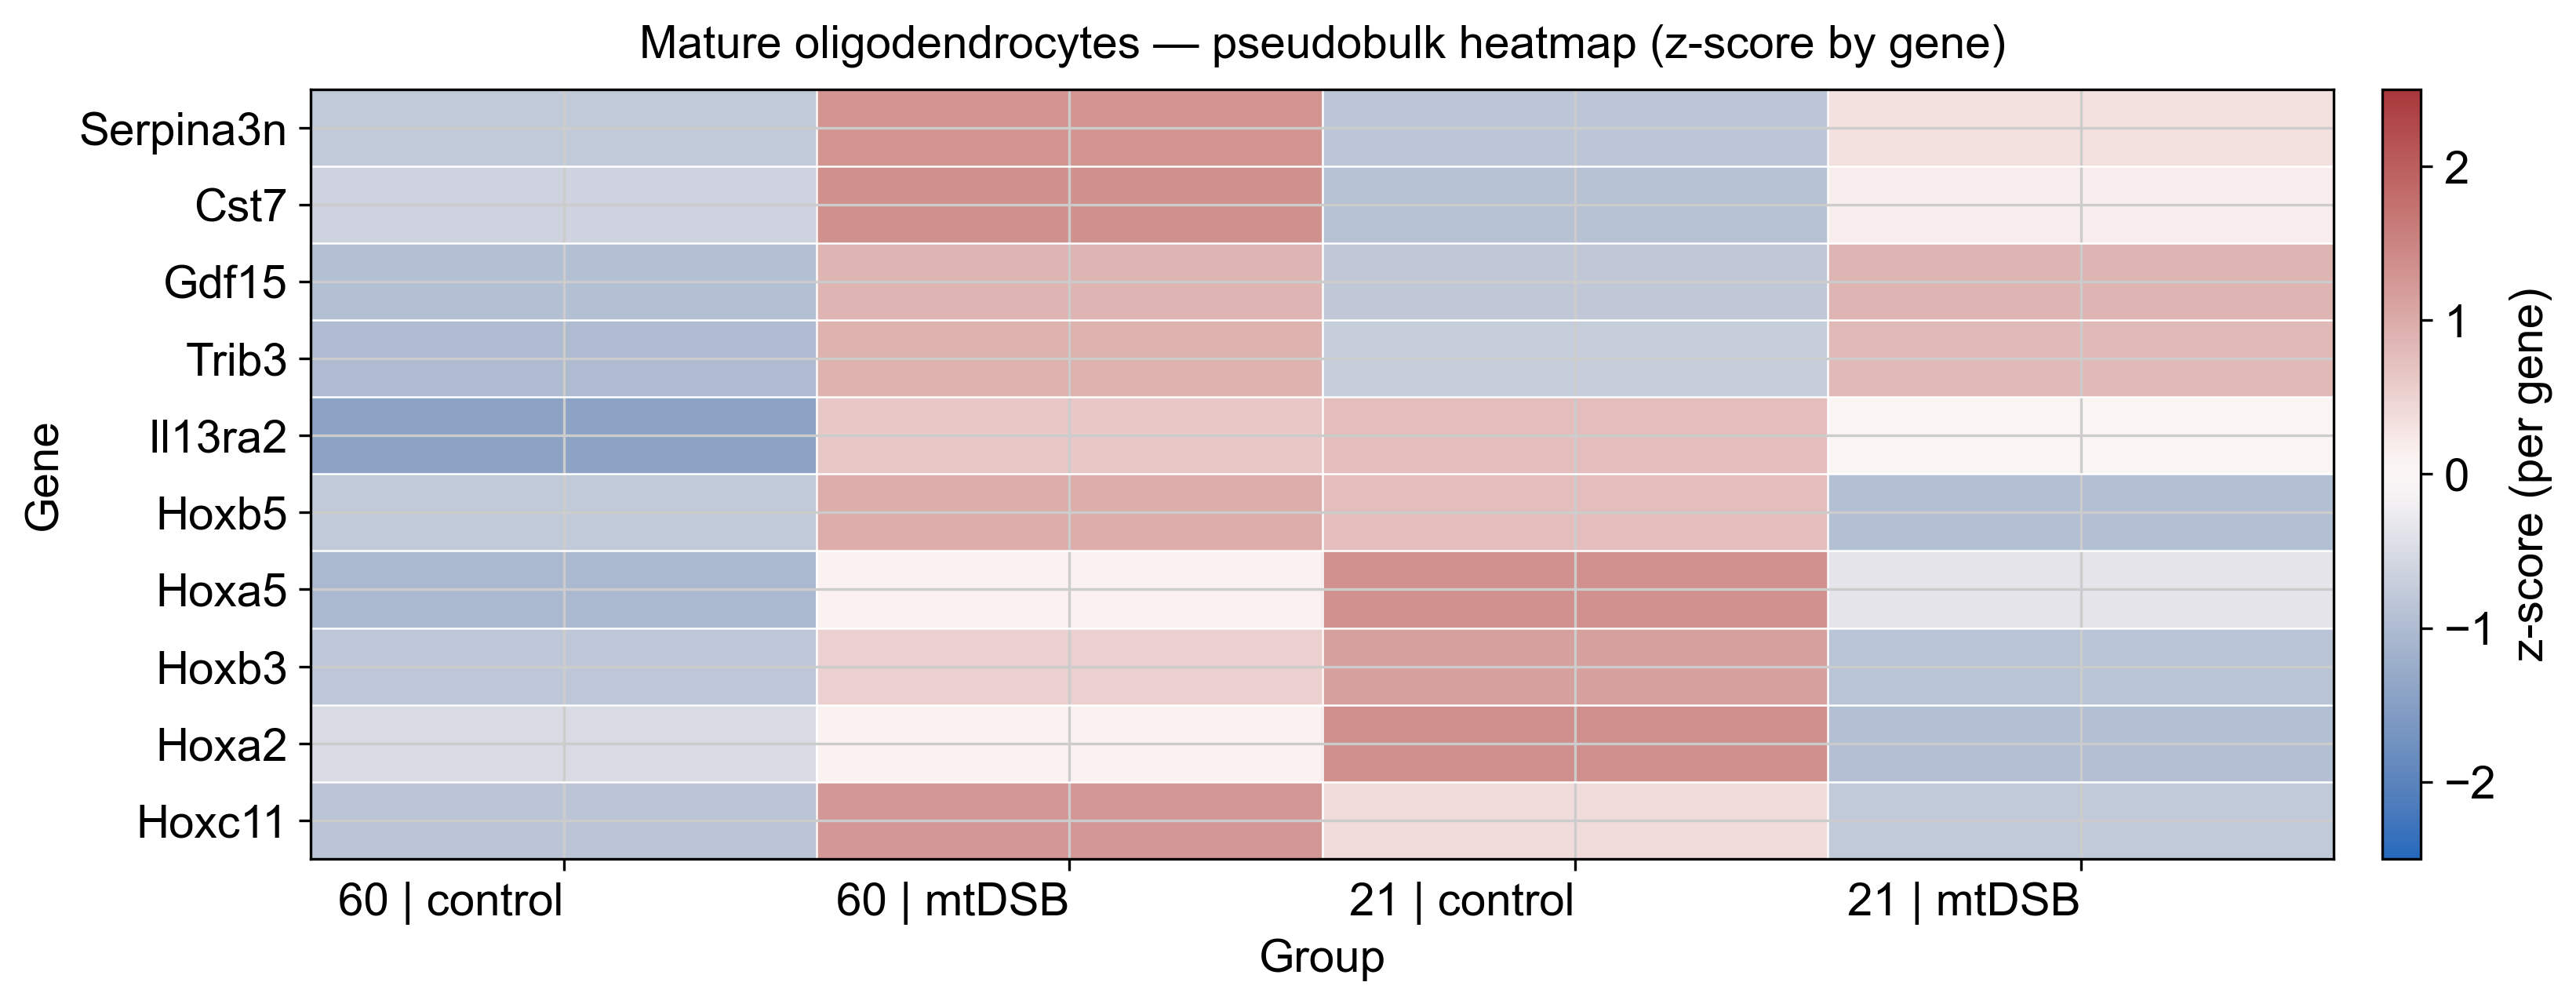

In [384]:
ct = "Mature oligodendrocytes"
counts_df, meta_df = pb[ct]
genes = ["Serpina3n","Cst7","Gdf15","Trib3","Il13ra2",
         "Hoxb5","Hoxa5","Hoxb3","Hoxa2","Hoxc11"]

_ = heatmap_pseudobulk(
    counts_df, meta_df, genes,
    groupby=("age","condition"),
    log1p=True, zscore_by_gene=True,
    title=f"{ct} — pseudobulk heatmap (z-score by gene)",
    savepath=None
)

In [378]:
def barplot_pseudobulk(counts_df, meta_df, genes,
                       groupby=("age","condition"),
                       log1p=True, figsize=(12, 2.2),
                       title=None, savepath=None, dpi=300):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    genes = [g for g in genes if g in counts_df.index]
    if not genes:
        raise ValueError("None of the requested genes found.")

    cpm = _pb_cpm(counts_df).loc[genes]

    if isinstance(groupby, (list, tuple)) and len(groupby) > 1:
        gb = meta_df.loc[cpm.columns, list(groupby)].astype(str).agg(" | ".join, axis=1)
    else:
        key = groupby if isinstance(groupby, str) else groupby[0]
        gb = meta_df.loc[cpm.columns, key].astype(str)

    groups = pd.Index(pd.unique(gb), name="group")
    # compute mean/sem per group
    mean = pd.DataFrame(index=genes, columns=groups, dtype=float)
    sem  = pd.DataFrame(index=genes, columns=groups, dtype=float)
    for g in groups:
        sub = cpm.loc[:, gb == g]
        mean[g] = sub.mean(axis=1)
        sem[g]  = sub.sem(axis=1)

    if log1p:
        mean = np.log1p(mean)
        # approximate SEM on log1p by delta method (ok for visualization),
        # or compute SEM on log1p directly:
        sem = sub.copy()
        sem = pd.concat([np.log1p(cpm.loc[:, gb == g]) for g in groups], axis=1)
        sem = sem.groupby(gb, axis=1).sem()
        sem = sem.loc[genes, groups]

    # plot: one row per gene
    n = len(genes)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(figsize[0], figsize[1]*n), dpi=150, sharex=True)
    if n == 1:
        axes = [axes]

    x = np.arange(len(groups))
    width = 0.7

    for ax, gene in zip(axes, genes):
        ax.bar(x, mean.loc[gene, groups].values, yerr=sem.loc[gene, groups].values,
               width=width, capsize=3, alpha=0.9, edgecolor="black", linewidth=0.5)
        ax.set_ylabel(gene, rotation=0, ha="right", va="center")
        ax.spines[['top','right']].set_visible(False)

    axes[-1].set_xticks(x, groups, rotation=45, ha="right")
    axes[-1].set_xlabel("Group")
    if title:
        fig.suptitle(title, y=0.995)
    fig.tight_layout(rect=[0,0,1,0.98])

    if savepath:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight")
        print(f"Saved bars → {savepath}")
    plt.show()

    return mean

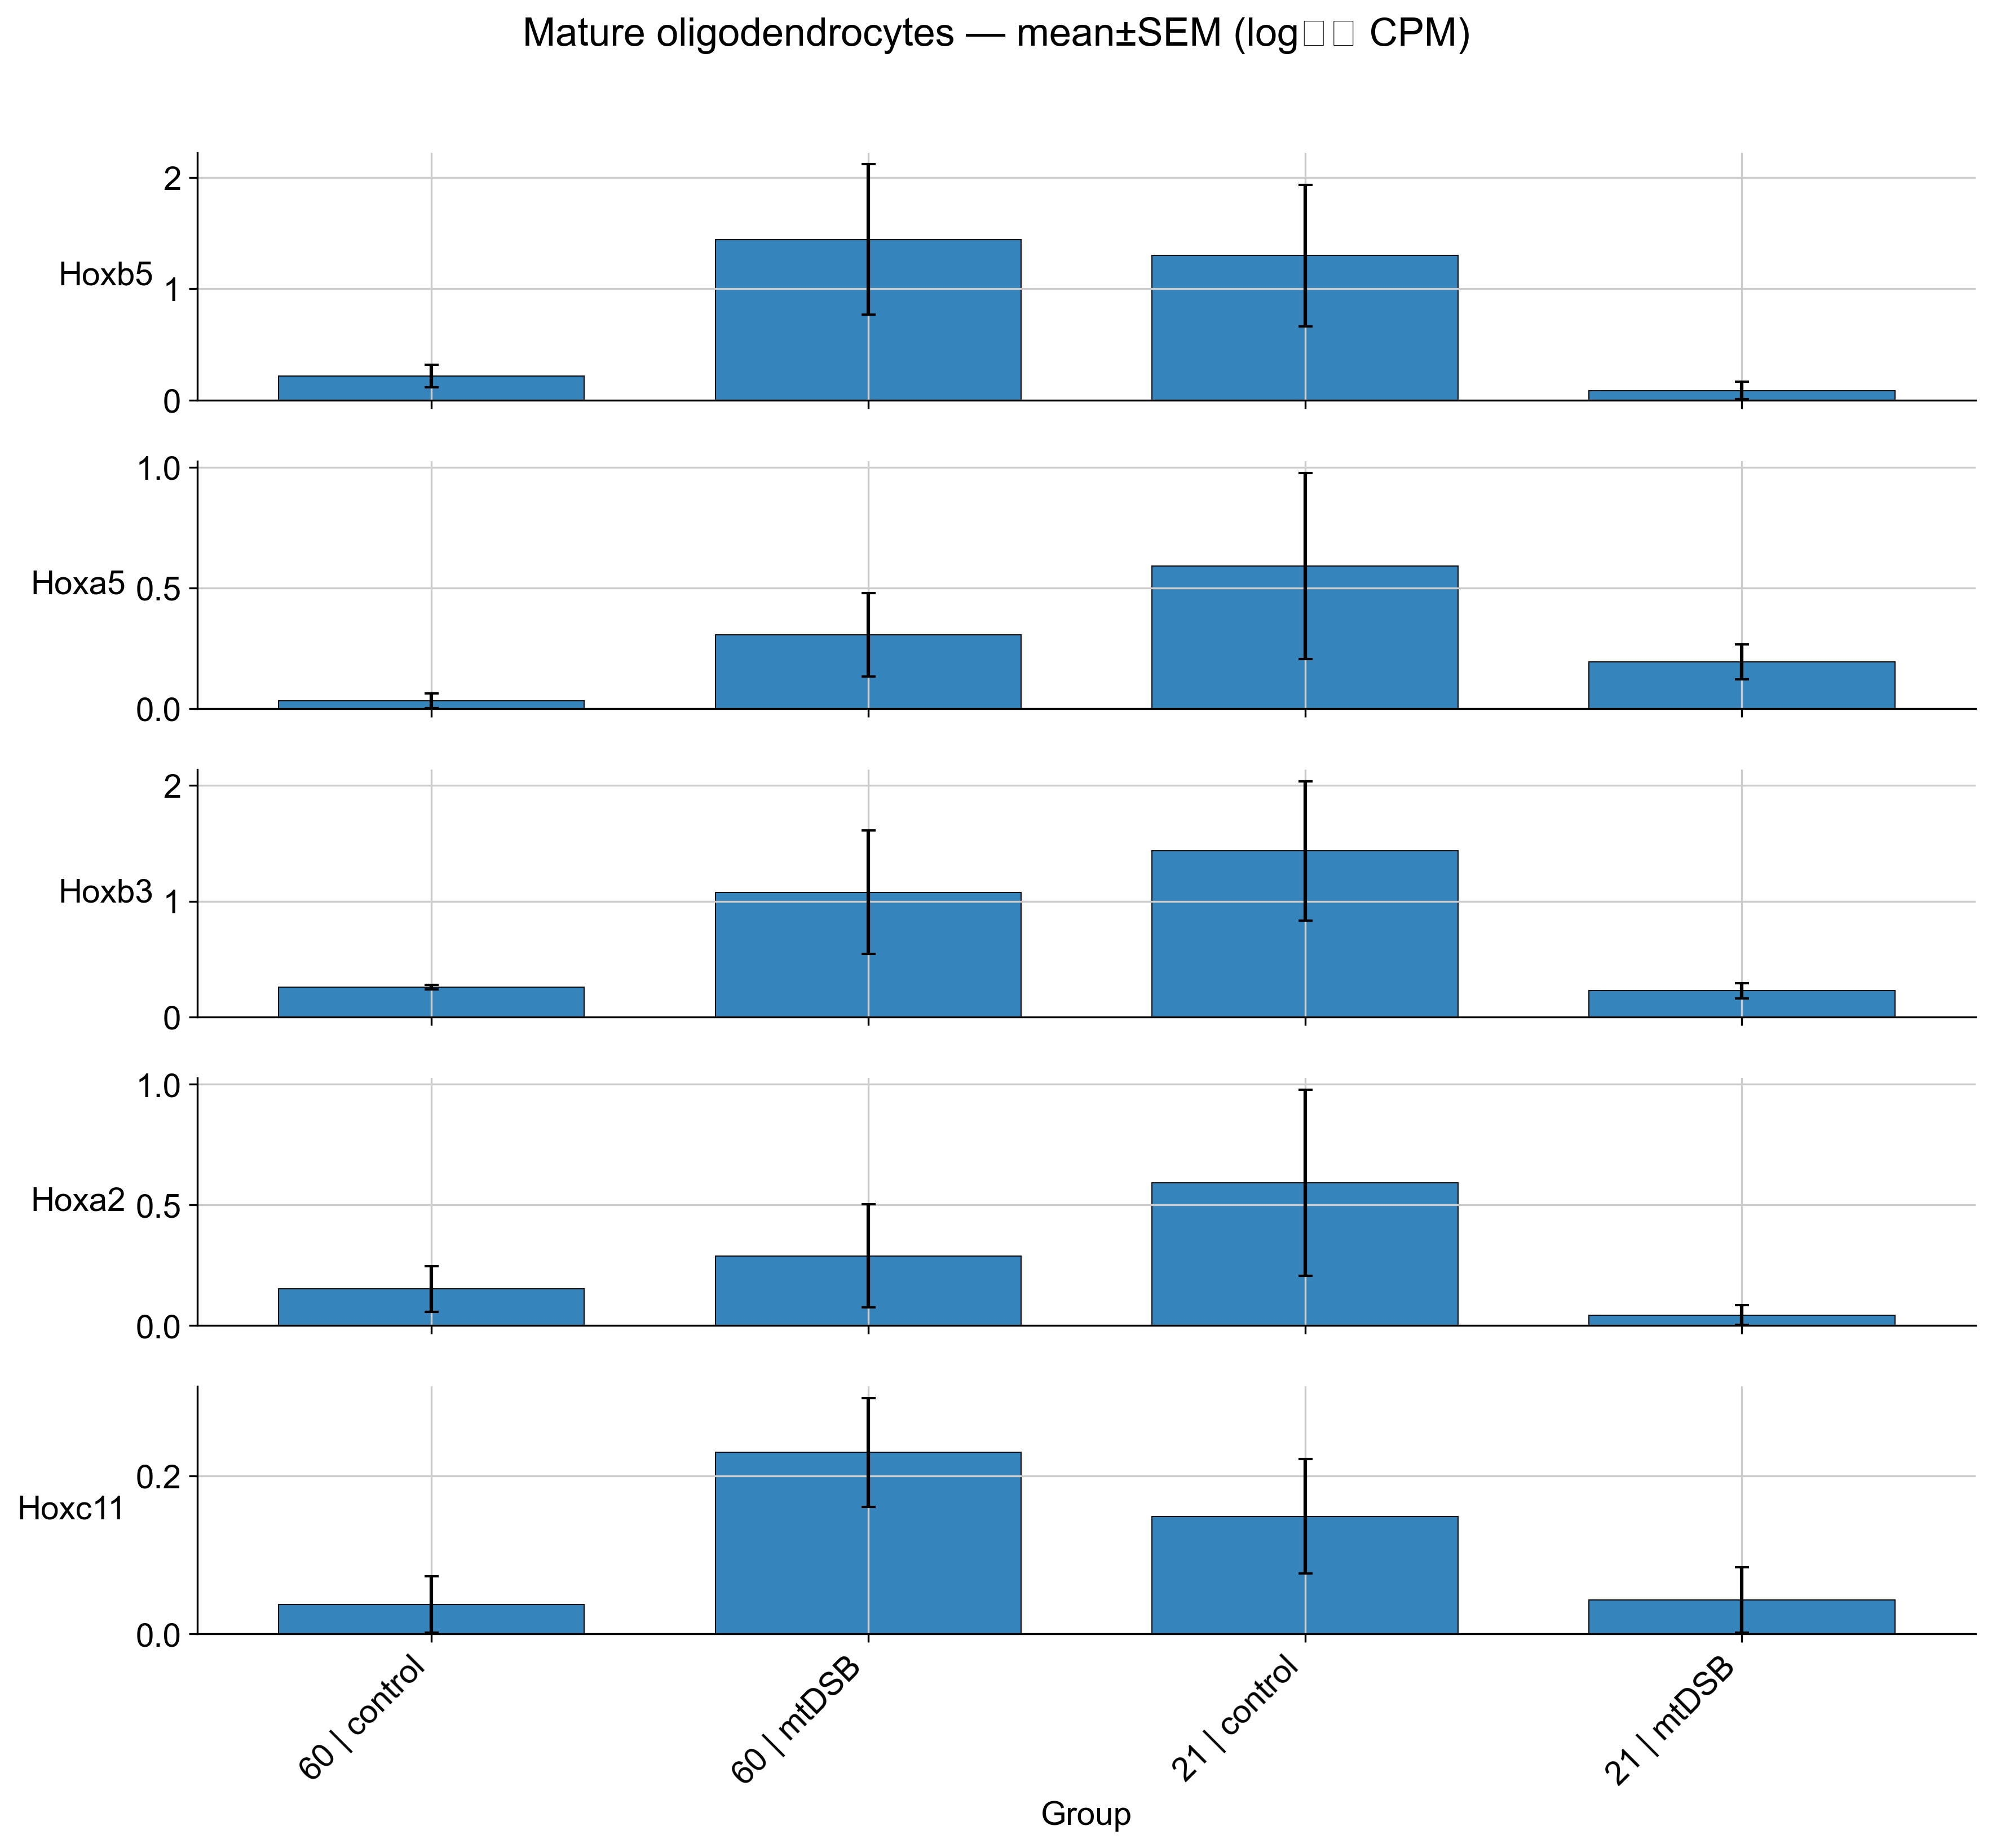

In [381]:
_ = barplot_pseudobulk(
    counts_df, meta_df, ["Hoxb5","Hoxa5","Hoxb3","Hoxa2","Hoxc11"],
    groupby=("age","condition"),
    log1p=True,
    title=f"{ct} — mean±SEM (log₁₊ CPM)",
    savepath=None
)

## Save results

In [318]:
import os

def save_all_results(results, outdir="../../results"):
    """
    Save all DE results from the nested `results` dict into organized subfolders.
    Structure:
        outdir/
          └── <cell_type>/
                ├── simple_effect_age_<age>.csv
                ├── deltaLFC_<ageA>_vs_<ageB>.csv
    """
    os.makedirs(outdir, exist_ok=True)

    for ct, rdict in results.items():
        ct_dir = os.path.join(outdir, ct.replace(" ", "_"))
        os.makedirs(ct_dir, exist_ok=True)

        # --- Simple effects (mtDSB vs control per age) ---
        for age, df in rdict.get("simple_effects", {}).items():
            if df is not None:
                fname = f"simple_effect_age_{age}.csv"
                df.to_csv(os.path.join(ct_dir, fname))

        # --- Delta-LFC (interaction proxy between ages) ---
        for (a1, a2), df in rdict.get("deltas", {}).items():
            if df is not None:
                fname = f"deltaLFC_{a1}_vs_{a2}.csv"
                df.to_csv(os.path.join(ct_dir, fname))

        print(f"✅ Saved {ct} results to {ct_dir}")

In [319]:
save_all_results(results, outdir="../results/age")

✅ Saved Mature oligodendrocytes results to ../results/age/Mature_oligodendrocytes
✅ Saved Telencephalon astrocytes results to ../results/age/Telencephalon_astrocytes
✅ Saved Microglia results to ../results/age/Microglia
✅ Saved Oligodendrocytes precursor cells results to ../results/age/Oligodendrocytes_precursor_cells
✅ Saved Olfactory astrocytes results to ../results/age/Olfactory_astrocytes
